In [1]:
# Получаем номер батча из параметров
try:
    CURRENT_BATCH
except NameError:
    CURRENT_BATCH = 2

# ВАЖНО: Менять это число для каждого батча!
# CURRENT_BATCH = 1  # <-- эту строку можно удалить или оставить как комментарий

print(f"\n{'='*60}")
print(f" РАБОТА С БАТЧЕМ №{CURRENT_BATCH}")
print('='*60)


 РАБОТА С БАТЧЕМ №2


In [2]:
import clickhouse_driver
import minio
import pyodbc
import xgboost
import sklearn
print("✅ Все библиотеки установлены!")

✅ Все библиотеки установлены!


In [2]:


import numpy as np
import pandas as pd
import os
from pathlib import Path
from dotenv import load_dotenv
import re
import platform
import pymssql  # вместо pyodbc
from datetime import datetime, timedelta

# Загружаем переменные из .env файла
load_dotenv('/home/jovyan/work/.env')

class DatabaseChecker:
    """Класс для изъятия цен на прошедшие продажи из БД"""

    def __init__(self, use_sa_login=True):
        """
        use_sa_login: если True, использует SQL-логин (sa)
                     если False, использует доменную аутентификацию (только для Windows)
        """
        # Определяем, где мы запущены
        self.is_windows = platform.system() == 'Windows'
        self.is_linux = platform.system() == 'Linux'

        # Берем настройки из .env или используем значения по умолчанию
        self.db_host = os.getenv("DB_HOST", "172.16.0.108")
        self.db_name = os.getenv("DB_NAME", "ВитринаДанных")

        if self.is_linux or use_sa_login:
            # В контейнере используем SQL-логин (sa)
            self.db_user = os.getenv("DB_USER", "sa")
            self.db_password = os.getenv("DB_PASSWORD", "sasa")
            self.auth_type = "SQL логин"
        else:
            # На Windows (локально) оставляем доменную аутентификацию
            self.db_user = None
            self.db_password = None
            self.auth_type = "Windows аутентификация"

        print(f" Подключение через {self.auth_type}")
        print(f"   Сервер: {self.db_host}/{self.db_name}")
        if self.db_user:
            print(f"   Пользователь: {self.db_user}")

        # Не создаём engine заранее, будем создавать подключение при каждом запросе
        self.connection = None

    def get_connection(self):
        """Создаёт подключение к БД"""
        if self.is_windows and not self.db_user:
            # Для Windows с доменной аутентификацией
            import pyodbc
            conn_str = (
                f"DRIVER={os.getenv('DB_DRIVER', 'SQL Server')};"
                f"SERVER={self.db_host};"
                f"DATABASE={self.db_name};"
                f"Trusted_Connection=yes;"
                f"Connection Timeout=120;"
            )
            return pyodbc.connect(conn_str)
        else:
            # Для Linux или SQL-логина
            return pymssql.connect(
                server=self.db_host,
                user=self.db_user,
                password=self.db_password,
                database=self.db_name,
                timeout=120,
                login_timeout=120,
                charset='UTF-8'
            )

    def get_sales_data(self, name=None, years_back=1, limit=50000) -> pd.DataFrame:
        """Получает детальные данные по продажам для указанной номенклатуры"""
        from datetime import datetime, timedelta
        timeout_seconds = 120
        cutoff_date = datetime.now() - timedelta(days=years_back*365)

        if name is None:
            name = input("Название номенклатуры: ")

        try:
            # ДЕТАЛЬНЫЙ ЗАПРОС (без GROUP BY, с городами)
            query = """
            SELECT nomenklatura._Description as [Номенклатура],
                DATEADD(year, -2000, [Дата]) as [Дата],
                [Количество],
                [Цена],
                [Сумма],
                [НДС],
                kontrag._Description as [Контрагент],
                organ._Description as [Организация],
                SSO._description as [город]
            FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
            inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
                on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
            left join [onec-9].upp_2012.dbo._Reference124 as kontrag
                on kontrag._Idrref = vypuskProduktNakoplenie.[КонтрагентИД]
            left join [onec-9].upp_2012.dbo._Reference164 as organ
                on organ._Idrref = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as zna4svoy
                on zna4svoy._fld19781_RRRef = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as obect
                on obect._fld19781_rrref = kontrag._idrref
            left join [onec-9].upp_2012.dbo._Chrc1140 as svoystvoOB
                on svoystvoOB._idrref = obect._fld19782rref
            left join [onec-9].upp_2012.dbo._reference97 as SSO
                on SSO._idrref = obect._fld19783_rrref
            WHERE nomenklatura._Description = %s
                and DATEADD(year, -2000, [Дата]) > %s
                and svoystvoOB._description like '%Населенный пункт%'
            ORDER BY [Дата] DESC
            """

            conn = self.get_connection()
            df = pd.read_sql(query, conn, params=(name, cutoff_date))
            conn.close()

            if len(df) > 0:
                print(f"\n Найдено {len(df)} записей для '{name}'")
                print(f"   Период: с {df['Дата'].min()} по {df['Дата'].max()}")
                return df
            else:
                print(f" Нет данных для '{name}'")
                return pd.DataFrame()

        except Exception as e:
            print(f" Ошибка запроса: {e}")
            return pd.DataFrame()

    def save_to_csv(self, df: pd.DataFrame, filename: str = None) -> str:
        """Сохраняет DataFrame в CSV с безопасным именем"""
        if df.empty:
            print(" Нет данных для сохранения")
            return None

        if filename is None:
            # Очищаем название от недопустимых символов
            item_name = df['Номенклатура'].iloc[0] if not df.empty else "data"
            safe_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', item_name)
            safe_name = safe_name[:50]
            # Сохраняем в папку data, которая примонтирована
            filename = f"/home/jovyan/work/data/raw/{safe_name}_sales_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv"

        # Создаем папку, если её нет
        os.makedirs(os.path.dirname(filename), exist_ok=True)

        df.to_csv(filename, index=False, sep=';', encoding='utf-8-sig')
        abs_path = os.path.abspath(filename)
        print(f"\n Данные сохранены в файл: {filename}")
        print(f"   Путь: {abs_path}")
        return filename

    def get_products_with_min_records(self, min_records=300, years_back=1):
        """
        Получает список товаров с количеством записей не меньше min_records
        Возвращает DataFrame с колонками: Номенклатура, записей, сумма, первая_дата, последняя_дата
        """
        from datetime import datetime, timedelta

        cutoff_date = (datetime.now() - timedelta(days=years_back*365)).strftime('%Y-%m-%d')

        query = """
        SELECT 
            nomenklatura._Description as [Номенклатура],
            COUNT(*) as [Количество_записей],
            SUM([Сумма]) as [Общая_сумма],
            MIN(DATEADD(year, -2000, [Дата])) as [Первая_продажа],
            MAX(DATEADD(year, -2000, [Дата])) as [Последняя_продажа]
        FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
        inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
            on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
        WHERE DATEADD(year, -2000, [Дата]) > %s
        GROUP BY nomenklatura._Description
        HAVING COUNT(*) >= %s
        ORDER BY COUNT(*) DESC
        """

        conn = self.get_connection()
        df = pd.read_sql(query, conn, params=(cutoff_date, min_records))
        conn.close()

        print(f" Найдено {len(df)} товаров с >= {min_records} записями")
        return df

    def get_detailed_sales_data(self, name=None, years_back=1, limit=50000) -> pd.DataFrame:
    """Получает ДЕТАЛЬНЫЕ данные по продажам для указанной номенклатуры"""
        from datetime import datetime, timedelta
        
        cutoff_date = datetime.now() - timedelta(days=years_back*365)
    
        if name is None:
            name = input("Название номенклатуры: ")
    
        try:
            query = """
            SELECT TOP %s nomenklatura._Description as [Номенклатура],
                DATEADD(year, -2000, [Дата]) as [Дата],
                [Количество],
                [Цена],
                [Сумма],
                [НДС],
                kontrag._Description as [Контрагент],
                organ._Description as [Организация],
                SSO._description as [город]
            FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
            inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
                on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
            left join [onec-9].upp_2012.dbo._Reference124 as kontrag
                on kontrag._Idrref = vypuskProduktNakoplenie.[КонтрагентИД]
            left join [onec-9].upp_2012.dbo._Reference164 as organ
                on organ._Idrref = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as zna4svoy
                on zna4svoy._fld19781_RRRef = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as obect
                on obect._fld19781_rrref = kontrag._idrref
            left join [onec-9].upp_2012.dbo._Chrc1140 as svoystvoOB
                on svoystvoOB._idrref = obect._fld19782rref
            left join [onec-9].upp_2012.dbo._reference97 as SSO
                on SSO._idrref = obect._fld19783_rrref
            WHERE nomenklatura._Description = %s
                and DATEADD(year, -2000, [Дата]) > %s
                and svoystvoOB._description like '%Населенный пункт%'
            ORDER BY [Дата] DESC
            """
    
            conn = self.get_connection()
            df = pd.read_sql(query, conn, params=(limit, name, cutoff_date))
            conn.close()
    
            if len(df) > 0:
                print(f"\n Найдено {len(df)} детальных записей для '{name}'")
                return df
            else:
                print(f" Нет данных для '{name}'")
                return pd.DataFrame()
    
        except Exception as e:
            print(f" Ошибка запроса: {e}")
            return pd.DataFrame()

In [66]:
# ВАЖНО: Менять это число для каждого батча!
#CURRENT_BATCH = 1  # <-- СЮДА ВВОДИТЕ НОМЕР БАТЧА (1, 2, 3... 37)

print(f"\n{'='*60}")
print(f" РАБОТА С БАТЧЕМ №{CURRENT_BATCH}")
print('='*60)


 РАБОТА С БАТЧЕМ №1


In [4]:
from clickhouse_driver import Client
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# Проверяем, какие базы данных есть
print(" БАЗЫ ДАННЫХ:")
dbs = ch_client.execute("SHOW DATABASES")
for db in dbs:
    print(f"   - {db[0]}")

# Проверяем, какие таблицы в external_data
print("\n ТАБЛИЦЫ В external_data:")
tables = ch_client.execute("SHOW TABLES FROM external_data")
for table in tables:
    print(f"   - {table[0]}")

# Если sales_raw нет, создадим её прямо сейчас
if ('sales_raw',) not in tables:
    print("\n Таблица sales_raw не найдена! Создаем...")
    
    # Убедимся, что база external_data существует
    ch_client.execute("CREATE DATABASE IF NOT EXISTS external_data")
    
    # Создаем таблицу
    ch_client.execute("""
    CREATE TABLE external_data.sales_raw
    (
        `Номенклатура` String,
        `Дата` DateTime,
        `Количество` Float64,
        `Цена` Float64,
        `Сумма` Float64,
        `НДС` Float64,
        `Контрагент` String,
        `Организация` String,
        `город` String
    ) ENGINE = MergeTree()
    ORDER BY (`Дата`)
    """)
    print(" Таблица sales_raw создана")
    
    # Проверим еще раз
    tables = ch_client.execute("SHOW TABLES FROM external_data")
    print("\n ТАБЛИЦЫ ПОСЛЕ СОЗДАНИЯ:")
    for table in tables:
        print(f"   - {table[0]}")
else:
    print("\n Таблица sales_raw уже существует")

 БАЗЫ ДАННЫХ:
   - INFORMATION_SCHEMA
   - default
   - external_data
   - information_schema
   - system

 ТАБЛИЦЫ В external_data:
   - demographic_data
   - google_trends_monthly
   - inflation_monthly
   - inflation_yearly
   - macro_monthly
   - median_salaries_regional
   - municipal_salaries_detailed
   - product_category_mapping
   - regional_salary_ratio
   - salary_groups
   - salary_growth
   - sales_raw
   - weather_hourly

 Таблица sales_raw уже существует


In [3]:
# ЯЧЕЙКА 1: Перезагрузка класса (если нужно)
import importlib
import database_checker

importlib.reload(database_checker)
from database_checker import DatabaseChecker
checker = DatabaseChecker(use_sa_login=True)
print(" Класс перезагружен")

 Товаров с >=300 записями: 0
 Товаров с >=300 записями: 0
 Подключение через SQL логин
   Сервер: 172.16.0.108/ВитринаДанных
   Пользователь: sa
 Класс перезагружен


In [4]:
# ЯЧЕЙКА 2: Функция для выгрузки и загрузки
def load_all_sales_to_clickhouse(years_back=1):
    """Выгружает ВСЕ продажи за период и сохраняет в ClickHouse"""
    from datetime import datetime, timedelta
    from clickhouse_driver import Client
    import pandas as pd

    cutoff_date = datetime.now() - timedelta(days=years_back*365)

    query = """
    SELECT 
        nomenklatura._Description as [Номенклатура],
        DATEADD(year, -2000, [Дата]) as [Дата],
        [Количество],
        [Цена],
        [Сумма],
        [НДС],
        kontrag._Description as [Контрагент],
        organ._Description as [Организация],
        SSO._description as [город]
    FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
    inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
        on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
    left join [onec-9].upp_2012.dbo._Reference124 as kontrag
        on kontrag._Idrref = vypuskProduktNakoplenie.[КонтрагентИД]
    left join [onec-9].upp_2012.dbo._Reference164 as organ
        on organ._Idrref = vypuskProduktNakoplenie.[ОрганизацияИД]
    left join [onec-9].upp_2012.dbo._InfoRg19780 as zna4svoy
        on zna4svoy._fld19781_RRRef = vypuskProduktNakoplenie.[ОрганизацияИД]
    left join [onec-9].upp_2012.dbo._InfoRg19780 as obect
        on obect._fld19781_rrref = kontrag._idrref
    left join [onec-9].upp_2012.dbo._Chrc1140 as svoystvoOB
        on svoystvoOB._idrref = obect._fld19782rref
    left join [onec-9].upp_2012.dbo._reference97 as SSO
        on SSO._idrref = obect._fld19783_rrref
    WHERE DATEADD(year, -2000, [Дата]) > %s
        and svoystvoOB._description like '%Населенный пункт%'
    ORDER BY [Дата] DESC
    """

    conn = checker.get_connection()
    print(" Выгружаем все данные из MSSQL...")

    # Загружаем порциями
    chunks = []
    for chunk in pd.read_sql(query, conn, params=(cutoff_date,), chunksize=50000):
        chunks.append(chunk)
        print(f"   Загружено {len(chunk)} записей...")

    df_all = pd.concat(chunks, ignore_index=True)
    conn.close()

    print(f"\n Всего выгружено: {len(df_all)} записей")

    # Подключаемся к ClickHouse
    client = Client(host='my_clickhouse', port=9000, user='default', password='')

    # Загружаем данные
    data_to_insert = [tuple(x) for x in df_all.to_numpy()]
    
    print(f" Загружаем {len(data_to_insert)} записей в ClickHouse...")
    client.execute("INSERT INTO external_data.sales_raw VALUES", data_to_insert)

    print(f" Данные сохранены в ClickHouse")
    return df_all

In [5]:
# ЯЧЕЙКА 3: ВЫПОЛНЯЕМ ВЫГРУЗКУ (это может занять время)
df_all = load_all_sales_to_clickhouse(years_back=1)
print(f" Загружено {len(df_all)} записей")

# ЯЧЕЙКА 4: Проверяем результат
from clickhouse_driver import Client
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# Проверяем количество записей
count = ch_client.execute("SELECT COUNT(*) FROM external_data.sales_raw")[0][0]
print(f" Всего записей в sales_raw: {count}")

# Проверяем первые несколько
sample = ch_client.execute("SELECT * FROM external_data.sales_raw LIMIT 5")
print("\n Пример данных:")
for row in sample:
    print(f"   {row[:2]}...")  # покажем только первые 2 колонки

 Выгружаем все данные из MSSQL...


/tmp/ipykernel_352/2790480.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  for chunk in pd.read_sql(query, conn, params=(cutoff_date,), chunksize=50000):


   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 7681 записей...

 Всего выгружено: 557681 записей
 Загружаем 557681 записей в ClickHouse...
 Данные сохранены в ClickHouse
 Загружено 557681 записей
 Всего записей в sales_raw: 557681

 Пример данных:
   ('Марг.створ.БЛ.с изюмом.23%.3кг.вед', datetime.datetime(2026, 3, 20, 5, 17, 22))...
   ('Марг.створ.БЛ.с изюмом.23%.3кг.вед', datetime.datetime(2026, 3, 20, 5, 17, 22))...
   ('Марг.створ.БЛ.с изюмом.23%.3кг.вед', datetime.datetime(2026, 3, 20, 5, 17, 22))...
   ('Десерт БЛ.7,2%.с ежевикой.3кг.вед', datetime.datetime(2026, 3, 20, 5, 17, 22))...
   ('Десерт БЛ.7,2%.с ежевикой.3кг.вед', datetime.datetime(2026, 3, 20, 5, 17, 22))...


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import io
import json
from scipy import stats
from minio import Minio
from io import BytesIO

# ============================================
# ФУНКЦИЯ СОХРАНЕНИЯ В MINIO (ИСПРАВЛЕННАЯ)
# ============================================
#CSV (data) в sales-analytics/{дата}/{блок}/
#Excel (excel_data) в sales-analytics/{дата}/{блок}/
#Графики (fig) в sales-analytics/{дата}/{блок}/
#
#
#
#
def save_to_minio(
    bucket_name="sales-analytics", 
    block_name="анализ_продаж", 
    data=None, 
    plot_name=None, 
    fig=None, 
    dpi=150, 
    formats=['png'],
    excel_data=None
):
    """
    Сохраняет данные в Minio
    """
    print(f"\n Сохраняем в Minio: {bucket_name}/{block_name}")
    
    # Подключение к Minio
    minio_endpoint = "host.docker.internal:9002"
    minio_access = "minioadmin"
    minio_secret = "minioadmin"
    
    try:
        client = Minio(
            endpoint=minio_endpoint,
            access_key=minio_access,
            secret_key=minio_secret,
            secure=False
        )
        
        # Проверяем/создаём бакет
        if not client.bucket_exists(bucket_name):
            client.make_bucket(bucket_name)
            print(f" Создан бакет: {bucket_name}")
        
        # Очищаем имя блока
        clean_block = re.sub(r'[<>:"/\\|?*%\'"]', '_', block_name)
        clean_block = clean_block[:50]
        
        # Формируем путь
        current_date = datetime.now().strftime('%Y-%m-%d')
        base_path = f"{current_date}/{clean_block}"
        
        saved_objects = []
        
        # 1. СОХРАНЯЕМ CSV
        if data is not None:
            csv_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', plot_name) if plot_name else f"data_{datetime.now().strftime('%Y%m%d_%H%M')}"
            csv_name = csv_name[:100]
            
            csv_buffer = io.StringIO()
            data.to_csv(csv_buffer, index=False, sep=';', encoding='utf-8-sig')
            csv_bytes = csv_buffer.getvalue().encode('utf-8-sig')
            
            object_path = f"{base_path}/{csv_name}.csv"
            client.put_object(
                bucket_name,
                object_path,
                data=BytesIO(csv_bytes),
                length=len(csv_bytes),
                content_type='text/csv; charset=utf-8'
            )
            
            file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
            print(f" CSV: {file_url}")
            saved_objects.append(file_url)
        
        # 2. СОХРАНЯЕМ EXCEL
        if excel_data is not None:
            excel_name = f"stats_{datetime.now().strftime('%Y%m%d_%H%M')}.xlsx"
            
            excel_buffer = io.BytesIO()
            with pd.ExcelWriter(excel_buffer, engine='openpyxl') as writer:
                for sheet_name, sheet_data in excel_data.items():
                    sheet_data.to_excel(writer, sheet_name=sheet_name)
            excel_buffer.seek(0)
            
            object_path = f"{base_path}/{excel_name}"
            client.put_object(
                bucket_name,
                object_path,
                data=excel_buffer,
                length=excel_buffer.getbuffer().nbytes,
                content_type='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
            )
            
            file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
            print(f" Excel: {file_url}")
            saved_objects.append(file_url)
        
        # 3. СОХРАНЯЕМ ГРАФИКИ (раздельная логика для разных форматов)
        if fig is not None:
            clean_plot = re.sub(r'[<>:"/\\|?*%\'"]', '_', plot_name) if plot_name else f"plot_{datetime.now().strftime('%Y%m%d_%H%M')}"
            clean_plot = clean_plot[:100]
            
            for fmt in formats:
                img_buffer = io.BytesIO()
                
                try:
                    if fmt == 'pdf':
                        # Для PDF не используем fonttype
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt)
                    elif fmt == 'svg':
                        # Для SVG тоже особые настройки не нужны
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt)
                    else:
                        # Для PNG и других растровых форматов
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt, 
                                  pil_kwargs={'optimize': True})
                    
                    img_buffer.seek(0)
                    
                    object_path = f"{base_path}/{clean_plot}.{fmt}"
                    client.put_object(
                        bucket_name,
                        object_path,
                        data=img_buffer,
                        length=img_buffer.getbuffer().nbytes,
                        content_type=f'image/{fmt}'
                    )
                    
                    file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
                    print(f" {fmt.upper()}: {file_url}")
                    saved_objects.append(file_url)
                    
                except Exception as e:
                    print(f" Ошибка при сохранении {fmt}: {e}")
                    continue
        
        print(f"    Всего сохранено: {len(saved_objects)} объектов")
        return saved_objects
        
    except Exception as e:
        print(f" Ошибка при сохранении в Minio: {e}")
        import traceback
        traceback.print_exc()
        return []

In [7]:

import pandas as pd
import numpy as np
from clickhouse_driver import Client

# ============================================
# ПОДКЛЮЧАЕМСЯ К CLICKHOUSE (а не к MSSQL)
# ============================================

#СТАРАЯ РАЗБИВКА ПО 10 батчей!!!!!!!!!!!!!!!!!!!!!

ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# ============================================
# 1. ПОЛУЧАЕМ СПИСОК ТОВАРОВ ИЗ CLICKHOUSE (ОДИН РАЗ!)
# ============================================
products_df = ch_client.query_dataframe("""
    SELECT 
        `Номенклатура`,
        COUNT(*) as `Количество_записей`,
        SUM(`Сумма`) as `Общая_сумма`,
        MIN(`Дата`) as `Первая_продажа`,
        MAX(`Дата`) as `Последняя_продажа`
    FROM external_data.sales_raw
    GROUP BY `Номенклатура`
    HAVING `Количество_записей` >= 300
    ORDER BY `Количество_записей` DESC
""")

all_products = products_df['Номенклатура'].tolist()

print(f"\n Найдено товаров для анализа: {len(all_products)}")
print("Топ-10 по количеству записей:")
print(products_df.head(10))

# ============================================
# 2. РАЗБИВКА НА БАТЧИ ПО 10 ТОВАРОВ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
batch_size = 10
num_batches = (len(all_products) + batch_size - 1) // batch_size
print(f"\n Всего батчей: {num_batches}")

# Словари для хранения данных по батчам
all_batches_stats = {}

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min(start_idx + batch_size, len(all_products))
    batch_products = all_products[start_idx:end_idx]
    
    print(f"\n{'='*70}")
    print(f" БАТЧ {batch_num + 1}/{num_batches}: товары {start_idx+1}-{end_idx}")
    print('='*70)
    
    # Фильтруем данные для текущего батча
    batch_df = products_df.iloc[start_idx:end_idx].copy()
    
    print("\n Данные батча (агрегированные):")
    print(batch_df[['Номенклатура', 'Количество_записей', 'Общая_сумма']].to_string(index=False))
    
    # Сохраняем статистику батча
    batch_stats = {
        'products': batch_products,
        'total_records': batch_df['Количество_записей'].sum(),
        'total_sum': batch_df['Общая_сумма'].sum(),
        'avg_records': batch_df['Количество_записей'].mean()
    }
    all_batches_stats[batch_num] = batch_stats
    
    print(f"\n Статистика батча:")
    print(f"   Всего записей: {batch_stats['total_records']}")
    print(f"   Общая сумма: {batch_stats['total_sum']:.2f}")
    print(f"   Среднее записей на товар: {batch_stats['avg_records']:.1f}")

# ============================================
# 3. ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ БАТЧАМ
# ============================================
print(f"\n{'='*70}")
print(" ИТОГОВАЯ СТАТИСТИКА")
print('='*70)

total_records_all = 0
total_sum_all = 0

for batch_num, stats in all_batches_stats.items():
    print(f"\n Батч {batch_num + 1}:")
    print(f"   Товаров: {len(stats['products'])}")
    print(f"   Записей: {stats['total_records']}")
    print(f"   Сумма: {stats['total_sum']:.2f}")
    
    total_records_all += stats['total_records']
    total_sum_all += stats['total_sum']

print(f"\n ИТОГО:")
print(f"   Всего товаров: {len(all_products)}")
print(f"   Всего записей: {total_records_all}")
print(f"   Общая сумма: {total_sum_all:.2f}")


 Найдено товаров для анализа: 235
Топ-10 по количеству записей:
                                        Номенклатура  Количество_записей  \
0                   Поддон стандартный (1,2м * 0,8м)               20464   
1        Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт               11942   
2       Пр.из творога БЛ с изюмом 23%.180г.ф/пак.8шт               11050   
3                Пр.из творога БЛ 24%.500г.пакет.8шт               10513   
4       Масса твор.с курагой.7Утра.5%.180г.ф/пак.8шт               10184   
5     Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт                9884   
6  Пр.из творога БЛ со вкус.ванилина 23%.180г.ф/п...                9829   
7     Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт                8164   
8       Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт                8152   
9               Пр.со смет.БЛ.20%.400г.ст.12шт.с змж                8011   

    Общая_сумма      Первая_продажа   Последняя_продажа  
0  8.265100e+02 2025-03-20 13:25:44 2026


 Найдено товаров для анализа: 235

 КЛАСТЕРИЗАЦИЯ ТОВАРОВ...

 АНАЛИЗ КЛАСТЕРОВ:

 КЛАСТЕР 0: 47 товаров
   Среднее записей: 2114
   Коэф. вариации: 1.46 (стабильность)
   Среднее городов: 39.4
   Тип: REGIONAL
   Размер батча: 7
   Примеры: Мол.смет.пр.БЛ.Классическая.10%.5кг.вед.№20...

 КЛАСТЕР 1: 127 товаров
   Среднее записей: 1165
   Коэф. вариации: 1.45 (стабильность)
   Среднее городов: 13.9
   Тип: REGIONAL
   Размер батча: 7
   Примеры: Пр.из творога БЛ 30%.500г.пакет.8шт...

 КЛАСТЕР 2: 17 товаров
   Среднее записей: 9084
   Коэф. вариации: 2.18 (стабильность)
   Среднее городов: 41.8
   Тип: VOLATILE
   Размер батча: 6
   Примеры: Поддон стандартный (1,2м * 0,8м)...

 КЛАСТЕР 3: 12 товаров
   Среднее записей: 1121
   Коэф. вариации: 0.70 (стабильность)
   Среднее городов: 5.9
   Тип: REGULAR
   Размер батча: 10
   Примеры: Пр.пл.с сыром ломт.сол.МЦ.50%.Друж.70г.фол.40шт...

 КЛАСТЕР 4: 32 товаров
   Среднее записей: 3479
   Коэф. вариации: 3.56 (стабильность)
   Среднее го

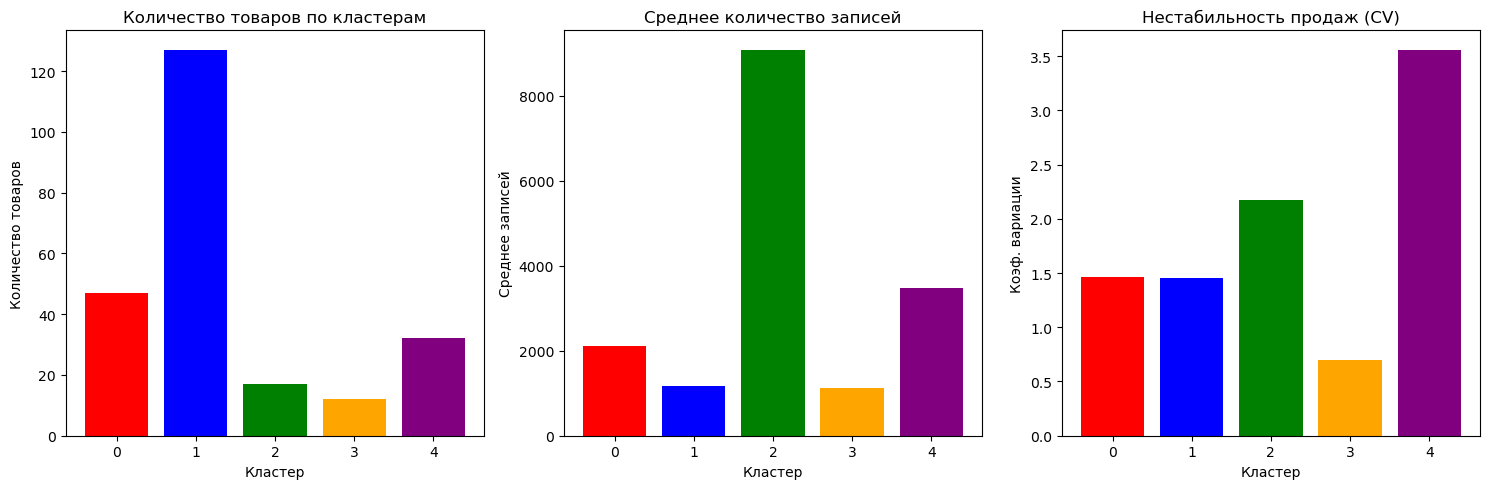


 Статистика по батчам:
   Всего товаров: 235
   Всего батчей: 37
   Средний размер батча: 6.4 товаров


In [8]:
import pandas as pd
import numpy as np
from clickhouse_driver import Client
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================
# ПОДКЛЮЧАЕМСЯ К CLICKHOUSE
# ============================================
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# ============================================
# 1. ПОЛУЧАЕМ ДЕТАЛЬНУЮ ИНФОРМАЦИЮ ПО ТОВАРАМ
# ============================================
products_df = ch_client.query_dataframe("""
    SELECT 
        `Номенклатура`,
        COUNT(*) as record_count,
        SUM(`Сумма`) as total_sum,
        AVG(`Количество`) as avg_quantity,
        stddevSamp(`Количество`) as std_quantity,  --  ИСПРАВЛЕНО: stddevSamp вместо STDDEV
        COUNT(DISTINCT `город`) as city_count,
        COUNT(DISTINCT `Контрагент`) as customer_count,
        MIN(`Дата`) as first_sale,
        MAX(`Дата`) as last_sale
    FROM external_data.sales_raw
    GROUP BY `Номенклатура`
    HAVING record_count >= 300
    ORDER BY record_count DESC
""")

print(f"\n Найдено товаров для анализа: {len(products_df)}")

# Добавляем вычисляемые признаки
products_df['days_on_market'] = (pd.to_datetime(products_df['last_sale']) - 
                                  pd.to_datetime(products_df['first_sale'])).dt.days
products_df['cv'] = products_df['std_quantity'] / products_df['avg_quantity']  # коэффициент вариации
products_df['avg_daily'] = products_df['record_count'] / products_df['days_on_market']

# ============================================
# 2. КЛАСТЕРИЗАЦИЯ ТОВАРОВ
# ============================================
print("\n КЛАСТЕРИЗАЦИЯ ТОВАРОВ...")

# Выбираем признаки для кластеризации
features = ['record_count', 'avg_quantity', 'cv', 'city_count', 'customer_count', 'avg_daily']
X = products_df[features].fillna(0)

# Нормализуем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Определяем оптимальное количество кластеров
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
products_df['cluster'] = kmeans.fit_predict(X_scaled)

# ============================================
# 3. АНАЛИЗ КЛАСТЕРОВ
# ============================================
print("\n АНАЛИЗ КЛАСТЕРОВ:")
print("=" * 70)

cluster_params = {}

for cluster in range(n_clusters):
    cluster_data = products_df[products_df['cluster'] == cluster]
    
    # Характеристики кластера
    avg_records = cluster_data['record_count'].mean()
    avg_cv = cluster_data['cv'].mean()
    avg_cities = cluster_data['city_count'].mean()
    
    print(f"\n КЛАСТЕР {cluster}: {len(cluster_data)} товаров")
    print(f"   Среднее записей: {avg_records:.0f}")
    print(f"   Коэф. вариации: {avg_cv:.2f} (стабильность)")
    print(f"   Среднее городов: {avg_cities:.1f}")
    
    # Определяем тип кластера на основе реальных данных
    if avg_records > 50000:
        cluster_type = "super_popular"
        batch_size = 5
        params = {
            'n_estimators': 500,
            'learning_rate': 0.03,
            'max_depth': 6,
            'subsample': 0.7,
            'reg_alpha': 0.1
        }
    elif avg_records > 20000:
        cluster_type = "popular"
        batch_size = 8
        params = {
            'n_estimators': 400,
            'learning_rate': 0.04,
            'max_depth': 5,
            'subsample': 0.8,
            'reg_alpha': 0.1
        }
    elif avg_cv > 1.5:  # Нестабильные
        cluster_type = "volatile"
        batch_size = 6
        params = {
            'n_estimators': 800,
            'learning_rate': 0.01,
            'max_depth': 3,
            'subsample': 0.5,
            'reg_alpha': 1.0,
            'reg_lambda': 1.0,
            'min_child_weight': 5
        }
    elif avg_cities > 10:  # Много городов
        cluster_type = "regional"
        batch_size = 7
        params = {
            'n_estimators': 600,
            'learning_rate': 0.02,
            'max_depth': 5,
            'colsample_bytree': 0.7,
            'subsample': 0.7
        }
    else:
        cluster_type = "regular"
        batch_size = 10
        params = {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 4,
            'subsample': 0.8,
            'reg_alpha': 0.2
        }
    
    cluster_params[cluster] = {
        'name': cluster_type,
        'batch_size': batch_size,
        'params': params,
        'products': cluster_data['Номенклатура'].tolist()
    }
    
    print(f"   Тип: {cluster_type.upper()}")
    print(f"   Размер батча: {batch_size}")
    if len(cluster_data) > 0:
        print(f"   Примеры: {cluster_data['Номенклатура'].iloc[0][:50]}...")

# ============================================
# 4. ФОРМИРОВАНИЕ БАТЧЕЙ ПО КЛАСТЕРАМ
# ============================================
print(f"\n{'='*70}")
print(" ФОРМИРОВАНИЕ БАТЧЕЙ")
print('='*70)

all_batches = []
batch_counter = 1

for cluster, info in cluster_params.items():
    products = info['products']
    batch_size = info['batch_size']
    cluster_name = info['name']
    
    if len(products) == 0:
        continue
        
    print(f"\n Кластер {cluster} ({cluster_name.upper()}) - {len(products)} товаров")
    
    # Разбиваем на батчи
    for i in range(0, len(products), batch_size):
        batch_products = products[i:i+batch_size]
        
        batch_info = {
            'batch_num': batch_counter,
            'cluster': cluster,
            'cluster_name': cluster_name,
            'products': batch_products,
            'product_count': len(batch_products),
            'params': info['params'],
            'description': f"{cluster_name}_batch_{batch_counter}"
        }
        
        all_batches.append(batch_info)
        
        print(f"   Батч {batch_counter}: {len(batch_products)} товаров ({cluster_name})")
        
        # Показываем первые товары в батче
        if len(batch_products) > 0:
            print(f"      Например: {batch_products[0][:60]}...")
        
        batch_counter += 1

print(f"\n{'='*70}")
print(f" ВСЕГО БАТЧЕЙ: {len(all_batches)}")
print('='*70)

# ============================================
# 5. ФУНКЦИИ ДЛЯ РАБОТЫ С БАТЧАМИ
# ============================================
def get_batch_params(batch_num):
    """Возвращает параметры для конкретного батча"""
    for batch in all_batches:
        if batch['batch_num'] == batch_num:
            return batch
    return None

def get_product_batch(product_name):
    """Определяет в каком батче находится товар"""
    for batch in all_batches:
        if product_name in batch['products']:
            return batch
    return None

# ============================================
# 6. СОХРАНЯЕМ ИНФОРМАЦИЮ О БАТЧАХ
# ============================================
import json
import os

# Создаем директорию если нет
os.makedirs('/home/jovyan/work/data/processed', exist_ok=True)

batches_info = {
    'total_batches': len(all_batches),
    'total_products': len(products_df),
    'clusters': {}
}

for cluster in range(n_clusters):
    if cluster in cluster_params:
        cluster_data = products_df[products_df['cluster'] == cluster]
        batches_info['clusters'][cluster] = {
            'name': cluster_params[cluster]['name'],
            'product_count': len(cluster_data),
            'batch_size': cluster_params[cluster]['batch_size'],
            'params': cluster_params[cluster]['params']
        }

# Сохраняем в JSON
with open('/home/jovyan/work/data/processed/batch_config.json', 'w', encoding='utf-8') as f:
    json.dump(batches_info, f, ensure_ascii=False, indent=2)

# Сохраняем детальную информацию по батчам
batches_detail = []
for batch in all_batches:
    batches_detail.append({
        'batch_num': batch['batch_num'],
        'cluster': batch['cluster'],
        'cluster_name': batch['cluster_name'],
        'product_count': batch['product_count'],
        'products': batch['products'][:3] if len(batch['products']) > 0 else []
    })

pd.DataFrame(batches_detail).to_csv('/home/jovyan/work/data/processed/batches_detail.csv', index=False)

print(f"\n Информация о батчах сохранена в /home/jovyan/work/data/processed/")

# ============================================
# 7. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# График 1: Распределение по кластерам
plt.subplot(1, 3, 1)
cluster_sizes = products_df['cluster'].value_counts().sort_index()
colors = ['red', 'blue', 'green', 'orange', 'purple'][:len(cluster_sizes)]
plt.bar(cluster_sizes.index, cluster_sizes.values, color=colors)
plt.title('Количество товаров по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Количество товаров')

# График 2: Среднее количество записей
plt.subplot(1, 3, 2)
cluster_means = products_df.groupby('cluster')['record_count'].mean()
plt.bar(cluster_means.index, cluster_means.values, color=colors)
plt.title('Среднее количество записей')
plt.xlabel('Кластер')
plt.ylabel('Среднее записей')

# График 3: Коэффициент вариации
plt.subplot(1, 3, 3)
cluster_cv = products_df.groupby('cluster')['cv'].mean()
plt.bar(cluster_cv.index, cluster_cv.values, color=colors)
plt.title('Нестабильность продаж (CV)')
plt.xlabel('Кластер')
plt.ylabel('Коэф. вариации')

plt.tight_layout()
plt.show()

print(f"\n Статистика по батчам:")
print(f"   Всего товаров: {len(products_df)}")
print(f"   Всего батчей: {len(all_batches)}")
print(f"   Средний размер батча: {sum(b['product_count'] for b in all_batches)/len(all_batches):.1f} товаров")

In [ ]:
#перед визуальным анализом нужно добавить все важные внешние признаки

In [19]:
def enrich_full_dataset(df):
    """
    Обогащает полный датасет всеми внешними признаками из таблиц ClickHouse
    """
    client = Client(
        host='my_clickhouse',
        port=9000,
        user='default',
        password='',
        database='external_data'
    )
    
    # Создаем копию датасета
    df_enriched = df.copy()
    
    # Убеждаемся, что date в правильном формате
    df_enriched['date'] = pd.to_datetime(df_enriched['date'])
    df_enriched['year'] = df_enriched['date'].dt.year
    df_enriched['month'] = df_enriched['date'].dt.month
    df_enriched['day'] = df_enriched['date'].dt.day
    df_enriched['date_only'] = df_enriched['date'].dt.date
    
    print("="*60)
    print(" НАЧИНАЕМ ОБОГАЩЕНИЕ ПОЛНОГО ДАТАСЕТА")
    print("="*60)
    print(f" Исходный датасет: {df_enriched.shape}")
    print(f"   Записей: {len(df_enriched):,}")
    print(f"   Городов: {df_enriched['city'].nunique()}")
    print(f"   Товаров: {df_enriched['Номенклатура'].nunique()}")
    print(f"   Период: {df_enriched['date'].min().date()} - {df_enriched['date'].max().date()}")
    
    # 1. ПОГОДА (weather_hourly)
    print("\n1. ДОБАВЛЯЕМ ПОГОДНЫЕ ДАННЫЕ...")
    
    weather_query = """
    SELECT 
        city,
        toDate(timestamp) as weather_date,
        AVG(temperature) as avg_temperature,
        MIN(temperature) as min_temperature,
        MAX(temperature) as max_temperature,
        AVG(humidity) as avg_humidity,
        AVG(pressure) as avg_pressure,
        AVG(wind_speed) as avg_wind_speed,
        SUM(precipitation) as daily_precipitation
    FROM weather_hourly
    GROUP BY city, weather_date
    ORDER BY city, weather_date
    """
    
    try:
        weather_df = client.query_dataframe(weather_query)
        print(f"   Загружено {len(weather_df)} записей о погоде")
        
        weather_df['weather_date'] = pd.to_datetime(weather_df['weather_date'])
        df_enriched['sale_date'] = pd.to_datetime(df_enriched['date']).dt.date
        df_enriched['sale_date'] = pd.to_datetime(df_enriched['sale_date'])
        
        df_enriched = df_enriched.merge(
            weather_df,
            left_on=['city', 'sale_date'],
            right_on=['city', 'weather_date'],
            how='left'
        )
        
        df_enriched = df_enriched.drop(columns=['sale_date', 'weather_date'])
        
        # Заполняем пропуски
        for col in ['avg_temperature', 'avg_humidity', 'avg_pressure', 'avg_wind_speed', 'daily_precipitation']:
            if col in df_enriched.columns:
                city_means = df_enriched.groupby('city')[col].transform('mean')
                df_enriched[col] = df_enriched[col].fillna(city_means)
        
        print(f"   ✓ Погодные данные обработаны")
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке погоды: {e}")
    
    # 2. МАКРОЭКОНОМИЧЕСКИЕ ПОКАЗАТЕЛИ
    print("\n2. ДОБАВЛЯЕМ МАКРОЭКОНОМИЧЕСКИЕ ПОКАЗАТЕЛИ...")
    
    try:
        macro_df = client.query_dataframe("""
            SELECT 
                toYear(date) as year,
                toMonth(date) as month,
                inflation_rate as macro_inflation,
                key_rate,
                usd_rate,
                eur_rate
            FROM macro_monthly
            ORDER BY year, month
        """)
        print(f"   Загружено {len(macro_df)} записей из macro_monthly")
        
        df_enriched = df_enriched.merge(macro_df, on=['year', 'month'], how='left')
        
        for col in ['macro_inflation', 'key_rate', 'usd_rate', 'eur_rate']:
            if col in df_enriched.columns:
                df_enriched[col] = df_enriched[col].ffill().bfill()
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке macro_monthly: {e}")
    
    # 3. ИНФЛЯЦИЯ
    print("\n3. ДОБАВЛЯЕМ ДАННЫЕ ПО ИНФЛЯЦИИ...")
    
    try:
        infl_df = client.query_dataframe("""
            SELECT 
                year,
                month,
                inflation_rate as inflation_rate_monthly
            FROM inflation_monthly
            WHERE year >= 2024 AND year <= 2026
            ORDER BY year, month
        """)
        print(f"   Загружено {len(infl_df)} записей из inflation_monthly")
        
        df_enriched = df_enriched.merge(infl_df, on=['year', 'month'], how='left')
        
        if 'inflation_rate_monthly' in df_enriched.columns:
            df_enriched['inflation_rate_monthly'] = df_enriched.groupby('year')['inflation_rate_monthly'].ffill().bfill()
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке inflation_monthly: {e}")
    
    # 4. ГОДОВАЯ ИНФЛЯЦИЯ
    print("\n4. ДОБАВЛЯЕМ ГОДОВУЮ ИНФЛЯЦИЮ...")
    
    try:
        infl_yearly_df = client.query_dataframe("""
            SELECT 
                year,
                AVG(inflation_rate) as inflation_rate_yearly
            FROM inflation_yearly
            WHERE year >= 2024 AND year <= 2026
            GROUP BY year
            ORDER BY year
        """)
        print(f"   Загружено {len(infl_yearly_df)} записей из inflation_yearly")
        
        df_enriched = df_enriched.merge(infl_yearly_df, on=['year'], how='left')
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке inflation_yearly: {e}")
    
    # 5. ДЕМОГРАФИЯ
    print("\n5. ДОБАВЛЯЕМ ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ...")
    
    try:
        demo_df = client.query_dataframe("""
            SELECT 
                year,
                SUM(total_population) as total_population,
                SUM(male_population) as male_population,
                SUM(female_population) as female_population
            FROM demographic_data
            WHERE year >= 2024 AND year <= 2026
            GROUP BY year
            ORDER BY year
        """)
        print(f"   Загружено {len(demo_df)} записей из demographic_data")
        
        df_enriched = df_enriched.merge(demo_df, on=['year'], how='left')
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке demographic_data: {e}")
    
    # 6. СТАТИСТИЧЕСКИЕ ПРИЗНАКИ
    print("\n6. ДОБАВЛЯЕМ СТАТИСТИЧЕСКИЕ ПРИЗНАКИ...")
    
    df_enriched = df_enriched.sort_values(['Номенклатура', 'date'])
    
    for lag in [1, 7, 30]:
        df_enriched[f'amount_lag_{lag}'] = df_enriched.groupby('Номенклатура')['amount'].shift(lag)
    
    for window in [7, 14, 30]:
        df_enriched[f'amount_rolling_mean_{window}'] = (
            df_enriched.groupby('Номенклатура')['amount']
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df_enriched[f'amount_rolling_std_{window}'] = (
            df_enriched.groupby('Номенклатура')['amount']
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )
    
    print(f"   ✓ Добавлены статистические признаки")
    
    # 7. СЕЗОННЫЕ ПРИЗНАКИ
    print("\n7. ДОБАВЛЯЕМ СЕЗОННЫЕ ПРИЗНАКИ...")
    
    def get_season(month):
        if month in [12, 1, 2]:
            return 'winter'
        elif month in [3, 4, 5]:
            return 'spring'
        elif month in [6, 7, 8]:
            return 'summer'
        else:
            return 'autumn'
    
    df_enriched['season'] = df_enriched['month'].apply(get_season)
    df_enriched['quarter'] = df_enriched['month'].apply(lambda x: (x-1)//3 + 1)
    df_enriched['is_weekend'] = (df_enriched['date'].dt.dayofweek >= 5).astype(int)
    df_enriched['day_of_year'] = df_enriched['date'].dt.dayofyear
    
    # Циклические признаки
    df_enriched['month_sin'] = np.sin(2 * np.pi * df_enriched['month'] / 12)
    df_enriched['month_cos'] = np.cos(2 * np.pi * df_enriched['month'] / 12)
    df_enriched['dow_sin'] = np.sin(2 * np.pi * df_enriched['date'].dt.dayofweek / 7)
    df_enriched['dow_cos'] = np.cos(2 * np.pi * df_enriched['date'].dt.dayofweek / 7)
    
    print(f"   ✓ Добавлены сезонные признаки")
    
    # Итоговая статистика
    print(f"\n{'='*60}")
    print(" ИТОГОВЫЙ ОБОГАЩЕННЫЙ ДАТАСЕТ")
    print('='*60)
    print(f"   Размерность: {df_enriched.shape}")
    print(f"   Записей: {len(df_enriched):,}")
    print(f"   Колонок: {len(df_enriched.columns)}")
    
    return df_enriched
def check_data_sources(df_enriched):
    """
    Проверяет, откуда взялись данные (реальные или синтетические)
    """
    print("\n" + "="*60)
    print(" ПРОВЕРКА ИСТОЧНИКОВ ДАННЫХ")
    print("="*60)
    
    # 1. Инфляция помесячная
    if 'inflation_rate_monthly' in df_enriched.columns:
        unique_months = df_enriched.groupby(['year', 'month'])['inflation_rate_monthly'].first()
        print(f"\n1. inflation_rate_monthly:")
        print(f"   Уникальных комбинаций (год-месяц): {len(unique_months)}")
        print(f"   Диапазон значений: {df_enriched['inflation_rate_monthly'].min():.2f} - {df_enriched['inflation_rate_monthly'].max():.2f}")
        
        # Покажем первые несколько
        print("   Примеры:")
        for (year, month), val in list(unique_months.items())[:5]:
            print(f"     {year}-{month:02d}: {val:.2f}")
    
    # 2. Годовая инфляция
    if 'inflation_rate_yearly' in df_enriched.columns:
        yearly_vals = df_enriched.groupby('year')['inflation_rate_yearly'].first()
        print(f"\n2. inflation_rate_yearly:")
        print(f"   Уникальных значений по годам: {len(yearly_vals)}")
        for year, val in yearly_vals.items():
            print(f"     {year}: {val:.2f}")
    
    # 3. Демография
    print(f"\n3. Демографические данные:")
    for col in ['total_population', 'male_population', 'female_population']:
        if col in df_enriched.columns:
            yearly_vals = df_enriched.groupby('year')[col].first()
            print(f"   {col}:")
            for year, val in yearly_vals.items():
                val_millions = val / 1e6
                print(f"     {year}: {val_millions:.2f} млн")

In [20]:
import pandas as pd
import numpy as np
from clickhouse_driver import Client
from datetime import datetime
import os
import json
import ast

# ============================================
# ЗАГРУЗКА ИНФОРМАЦИИ О БАТЧАХ
# ============================================

# Загружаем информацию о батчах
batches_df = pd.read_csv('/home/jovyan/work/data/processed/batches_detail.csv')

# Загружаем полную конфигурацию с товарами
with open('/home/jovyan/work/data/processed/batch_config.json', 'r') as f:
    full_config = json.load(f)

# Проверяем, что батч существует
if CURRENT_BATCH not in batches_df['batch_num'].values:
    print(f" ОШИБКА: Батч {CURRENT_BATCH} не найден!")
    print(f"   Доступные батчи: от 1 до {len(batches_df)}")
    raise ValueError(f"Батч {CURRENT_BATCH} не существует")

# Получаем информацию о выбранном батче
batch_info = batches_df[batches_df['batch_num'] == CURRENT_BATCH].iloc[0]
cluster_id = str(int(batch_info['cluster']))
cluster_params = full_config['clusters'][cluster_id]['params']

print(f"\n{'='*60}")
print(f" ВЫБРАН БАТЧ {CURRENT_BATCH}")
print('='*60)
print(f"   Кластер: {int(batch_info['cluster'])} ({batch_info['cluster_name'].upper()})")
print(f"   Товаров в батче: {int(batch_info['product_count'])}")
print(f"\n   Параметры модели для этого типа:")
for param, value in cluster_params.items():
    print(f"      {param}: {value}")

# ============================================
# ФУНКЦИЯ ДЛЯ ПОЛУЧЕНИЯ ТОВАРОВ КЛАСТЕРА
# ============================================

def get_cluster_products(cluster_id):
    """
    Получает все товары для указанного кластера из исходных данных
    """
    
    client = Client(
        host='my_clickhouse',
        port=9000,
        user='default',
        password='',
        database='external_data'
    )
    
    query = """
    SELECT 
        `Номенклатура`,
        COUNT(*) as record_count,
        AVG(`Количество`) as avg_quantity,
        stddevSamp(`Количество`) as std_quantity,
        COUNT(DISTINCT `город`) as city_count
    FROM external_data.sales_raw
    GROUP BY `Номенклатура`
    HAVING record_count >= 300
    ORDER BY record_count DESC
    """
    
    try:
        all_products_df = client.query_dataframe(query)
        print(f"    Загружено {len(all_products_df)} товаров из ClickHouse")
        
        all_products_df['cv'] = all_products_df['std_quantity'] / all_products_df['avg_quantity']
        
        batches_df_local = pd.read_csv('/home/jovyan/work/data/processed/batches_detail.csv')
        cluster_batches = batches_df_local[batches_df_local['cluster'] == float(cluster_id)]
        
        all_products = []
        for _, batch in cluster_batches.iterrows():
            products_sample = ast.literal_eval(batch['products'])
            all_products.extend(products_sample)
        
        unique_products = list(set(all_products))
        print(f"    Уникальных товаров в кластере {cluster_id}: {len(unique_products)}")
        
        return unique_products
        
    except Exception as e:
        print(f"    Ошибка при загрузке товаров: {e}")
        print("   Используем данные из batches_detail.csv")
        
        batches_df_local = pd.read_csv('/home/jovyan/work/data/processed/batches_detail.csv')
        cluster_batches = batches_df_local[batches_df_local['cluster'] == float(cluster_id)]
        
        all_products = []
        for _, batch in cluster_batches.iterrows():
            products_sample = ast.literal_eval(batch['products'])
            all_products.extend(products_sample)
        
        unique_products = list(set(all_products))
        print(f"    Найдено {len(unique_products)} товаров в кластере")
        
        return unique_products

# ============================================
# ФУНКЦИЯ ДЛЯ ЗАГРУЗКИ ДАННЫХ ТЕКУЩЕГО БАТЧА
# ============================================

def load_current_batch():
    """
    Загружает данные для текущего батча (CURRENT_BATCH)
    """
    
    # Получаем все товары кластера
    cluster_products = get_cluster_products(cluster_id)
    
    # Определяем границы текущего батча
    cluster_batches = batches_df[batches_df['cluster'] == float(cluster_id)].sort_values('batch_num')
    
    prev_batches = cluster_batches[cluster_batches['batch_num'] < CURRENT_BATCH]
    prev_count = prev_batches['product_count'].sum() if not prev_batches.empty else 0
    
    start_idx = prev_count
    end_idx = start_idx + int(batch_info['product_count'])
    
    batch_products = cluster_products[start_idx:end_idx]
    
    print(f"\n ЗАГРУЗКА ДАННЫХ БАТЧА {CURRENT_BATCH} ИЗ CLICKHOUSE")
    print('='*60)
    print(f"   Товаров в батче: {len(batch_products)}")
    print(f"   Индексы: {start_idx} - {end_idx}")
    
    client = Client(
        host='my_clickhouse',
        port=9000,
        user='default',
        password='',
        database='external_data'
    )
    
    all_dfs = []
    
    for i, product in enumerate(batch_products, 1):
        print(f"\n   {i}/{len(batch_products)}: {product[:70]}...")
        
        product_escaped = product.replace("'", "\\'")
        
        query = f"""
        SELECT 
            `Номенклатура`,
            `Дата` as date,
            `Количество` as quantity,
            `Цена` as price,
            `Сумма` as amount,
            `НДС` as vat,
            `Контрагент` as counterparty,
            `Организация` as organization,
            `город` as city
        FROM external_data.sales_raw
        WHERE `Номенклатура` = '{product_escaped}'
        ORDER BY `Дата`
        """
        
        try:
            df = client.query_dataframe(query)
            if not df.empty:
                all_dfs.append(df)
                print(f"      ✓ {len(df)} записей, {df['city'].nunique()} городов")
                print(f"      Сумма: {df['amount'].sum():,.2f}")
            else:
                print(f"      ✗ Нет данных")
        except Exception as e:
            print(f"      ✗ Ошибка: {e}")
    
    if all_dfs:
        full_df = pd.concat(all_dfs, ignore_index=True)
        return full_df
    else:
        return None

# ============================================
# ОСНОВНОЙ БЛОК - ЗАГРУЗКА И ОБОГАЩЕНИЕ
# ============================================

# 1. ЗАГРУЖАЕМ ДАННЫЕ ТЕКУЩЕГО БАТЧА
df_raw = load_current_batch()

if df_raw is not None:
    print(f"\n СТАТИСТИКА ЗАГРУЖЕННЫХ ДАННЫХ:")
    print(f"   Всего записей: {len(df_raw):,}")
    print(f"   Всего товаров: {df_raw['Номенклатура'].nunique()}")
    print(f"   Всего городов: {df_raw['city'].nunique()}")
    print(f"   Общая сумма: {df_raw['amount'].sum():,.2f}")
    print(f"   Период: {df_raw['date'].min().date()} - {df_raw['date'].max().date()}")
    
    expected_count = int(batch_info['product_count'])
    actual_count = df_raw['Номенклатура'].nunique()
    
    if actual_count == expected_count:
        print(f"\n УСПЕХ! Загружено {actual_count} из {expected_count} товаров")
    else:
        print(f"\n ВНИМАНИЕ! Загружено {actual_count} из {expected_count} товаров")
    
    # 2. СОХРАНЯЕМ СЫРЫЕ ДАННЫЕ
    raw_path = f'/home/jovyan/work/data/processed/batch{CURRENT_BATCH}_raw.parquet'
    df_raw.to_parquet(raw_path)
    print(f"\n Сырые данные сохранены: {raw_path}")
    
    # 3. ОБОГАЩАЕМ ДАТАСЕТ
    print(f"\n{'='*60}")
    print(f" ОБОГАЩЕНИЕ ДАННЫХ БАТЧА {CURRENT_BATCH}")
    print('='*60)
    
    full_df_enriched = enrich_full_dataset(df_raw)
    
    # 4. СОХРАНЯЕМ ОБОГАЩЕННЫЙ ДАТАСЕТ
    enriched_path = f'/home/jovyan/work/data/processed/batch{CURRENT_BATCH}_enriched.parquet'
    full_df_enriched.to_parquet(enriched_path)
    print(f"\nОбогащенный датасет сохранен: {enriched_path}")
    
    # 5. ПРОВЕРЯЕМ ИСТОЧНИКИ ДАННЫХ
    check_data_sources(full_df_enriched)
    
    # 6. СОХРАНЯЕМ МЕТАДАННЫЕ
    batch_metadata = {
        'batch_num': CURRENT_BATCH,
        'cluster': int(batch_info['cluster']),
        'cluster_name': batch_info['cluster_name'],
        'product_count': actual_count,
        'expected_count': expected_count,
        'params': cluster_params,
        'data_stats': {
            'total_records': len(df_raw),
            'unique_products': int(df_raw['Номенклатура'].nunique()),
            'unique_cities': int(df_raw['city'].nunique()),
            'total_amount': float(df_raw['amount'].sum()),
            'date_min': df_raw['date'].min().isoformat(),
            'date_max': df_raw['date'].max().isoformat()
        },
        'enriched_columns': len(full_df_enriched.columns),
        'enriched_features': len(full_df_enriched.columns) - len(df_raw.columns),
        'processed_at': datetime.now().isoformat()
    }
    
    meta_path = f'/home/jovyan/work/data/processed/batch{CURRENT_BATCH}_metadata.json'
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(batch_metadata, f, ensure_ascii=False, indent=2)
    print(f"\n Метаданные сохранены: {meta_path}")
    
    print(f"\n{'='*60}")
    print(f" БАТЧ {CURRENT_BATCH} ПОЛНОСТЬЮ ОБРАБОТАН")
    print('='*60)
    print(f"\n Переменная full_df_enriched содержит данные батча {CURRENT_BATCH}:")
    print(f"   Размер: {full_df_enriched.shape}")
    print(f"   Записей: {len(full_df_enriched):,}")
    print(f"   Товаров: {full_df_enriched['Номенклатура'].nunique()}")
    
else:
    print(f"\n Не удалось загрузить данные для батча {CURRENT_BATCH}")
    full_df_enriched = None


 ВЫБРАН БАТЧ 2
   Кластер: 0 (REGIONAL)
   Товаров в батче: 7

   Параметры модели для этого типа:
      n_estimators: 600
      learning_rate: 0.02
      max_depth: 5
      colsample_bytree: 0.7
      subsample: 0.7
    Загружено 235 товаров из ClickHouse
    Уникальных товаров в кластере 0: 21

 ЗАГРУЗКА ДАННЫХ БАТЧА 2 ИЗ CLICKHOUSE
   Товаров в батче: 7
   Индексы: 7 - 14

   1/7: Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5...
      ✓ 5048 записей, 50 городов
      Сумма: 36,715,911.00

   2/7: Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж...
      ✓ 1040 записей, 28 городов
      Сумма: 34,466,760.00

   3/7: Мол.пр.йогурт.БЛ.5,6%.с малиной.3кг.вед...
      ✓ 889 записей, 46 городов
      Сумма: 8,115,906.00

   4/7: Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед...
      ✓ 1242 записей, 50 городов
      Сумма: 14,310,294.00

   5/7: Мол.тв.пр.БЛ.Фермерский.1%.5кг.кор №28...
      ✓ 3425 записей, 39 городов
      Сумма: 235,814,675.00

   6/7: Десерт БЛ.7,2%.с малиной.3кг.вед...
      ✓ 135

In [21]:
full_df_enriched.shape

(13741, 46)

In [22]:
# Диагностика источников данных
print("="*60)
print(" ДИАГНОСТИКА ИСТОЧНИКОВ ДАННЫХ")
print("="*60)

client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

# 1. Проверяем inflation_monthly
print("\n1. inflation_monthly:")
count = client.execute("SELECT COUNT(*) FROM inflation_monthly")[0][0]
print(f"   Всего записей: {count}")

if count > 0:
    sample = client.execute("SELECT * FROM inflation_monthly LIMIT 3")
    print("   Примеры:")
    for row in sample:
        print(f"     {row}")

# 2. Проверяем inflation_yearly
print("\n2. inflation_yearly:")
count = client.execute("SELECT COUNT(*) FROM inflation_yearly")[0][0]
print(f"   Всего записей: {count}")

if count > 0:
    sample = client.execute("SELECT * FROM inflation_yearly LIMIT 3")
    print("   Примеры:")
    for row in sample:
        print(f"     {row}")

# 3. Проверяем demographic_data
print("\n3. demographic_data:")
count = client.execute("SELECT COUNT(*) FROM demographic_data")[0][0]
print(f"   Всего записей: {count}")

if count > 0:
    # Смотрим уникальные года
    years = client.execute("SELECT DISTINCT year FROM demographic_data ORDER BY year")
    print(f"   Года: {[y[0] for y in years]}")
    
    sample = client.execute("SELECT * FROM demographic_data LIMIT 3")
    print("   Примеры:")
    for row in sample:
        print(f"     {row}")

 ДИАГНОСТИКА ИСТОЧНИКОВ ДАННЫХ

1. inflation_monthly:
   Всего записей: 410
   Примеры:
     (1991, 12, 160.4, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1992, 1, 746.67, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1992, 2, 1014.89, datetime.datetime(2026, 3, 13, 6, 48, 41))

2. inflation_yearly:
   Всего записей: 421
   Примеры:
     (1991, 1, 6.2, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1991, 2, 4.8, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1991, 3, 6.3, datetime.datetime(2026, 3, 13, 6, 48, 41))

3. demographic_data:
   Всего записей: 2001
   Года: [2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046]
   Примеры:
     (2024, '0 лет', 1240610, 638344, 602266, datetime.datetime(2026, 3, 13, 6, 24, 47))
     (2024, '1 год', 1302922, 669277, 633645, datetime.datetime(2026, 3, 13, 6, 24, 47))
     (2024, '10 лет', 1920588, 987037, 933551, datetime.datetime(2026, 3, 13, 6, 24, 

In [20]:
from clickhouse_driver import Client

client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

# 1. Смотрим все таблицы в базе
print("="*60)
print(" ТАБЛИЦЫ В БАЗЕ external_data")
print("="*60)

tables = client.execute("SHOW TABLES")
for table in tables:
    print(f"  {table[0]}")
    
    # Смотрим структуру каждой таблицы
    columns = client.execute(f"DESCRIBE TABLE {table[0]}")
    for col in columns:
        print(f"    └ {col[0]}: {col[1]}")

# 2. Проверяем наличие данных в weather_hourly
print("\n" + "="*60)
print(" ПРОВЕРКА weather_hourly")
print("="*60)

weather_check = client.execute("SELECT COUNT(*) FROM weather_hourly")
print(f" Всего записей в weather_hourly: {weather_check[0][0]}")

# Покажем несколько примеров
weather_sample = client.execute("SELECT city, timestamp, temperature FROM weather_hourly LIMIT 5")
print("\n Примеры данных:")
for row in weather_sample:
    print(f"   {row[0]}: {row[1]} - {row[2]}°C")

 ТАБЛИЦЫ В БАЗЕ external_data
  demographic_data
    └ year: UInt16
    └ age_group: String
    └ total_population: UInt32
    └ male_population: UInt32
    └ female_population: UInt32
    └ loaded_at: DateTime
  inflation_monthly
    └ year: UInt16
    └ month: UInt8
    └ inflation_rate: Float64
    └ loaded_at: DateTime
  inflation_yearly
    └ year: UInt16
    └ month: UInt8
    └ inflation_rate: Float64
    └ loaded_at: DateTime
  macro_monthly
    └ date: Date
    └ inflation_rate: Float32
    └ key_rate: Float32
    └ usd_rate: Float32
    └ eur_rate: Float32
  median_salaries_regional
    └ region_code: String
    └ region_name: String
    └ year: UInt16
    └ salary_value: Float64
    └ loaded_at: DateTime
  municipal_salaries_detailed
    └ region: String
    └ category: String
    └ year: UInt16
    └ period: String
    └ salary: Float64
    └ loaded_at: DateTime
  regional_salary_ratio
    └ region_code: String
    └ region_name: String
    └ year: UInt16
    └ ratio_value:

In [23]:
from clickhouse_driver import Client
import numpy as np
import pandas as pd

# Подключаемся к ClickHouse
client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

def create_trend_features_from_clickhouse():
    """
    Создает признаки на основе исторических трендов из ClickHouse
    """
    print("="*60)
    print(" ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ")
    print("="*60)
    
    # Проверяем, есть ли таблица
    check_query = "EXISTS TABLE median_salaries_regional"
    exists = client.execute(check_query)[0][0]
    
    if not exists:
        print(" Таблица median_salaries_regional не найдена!")
        return pd.DataFrame()
    
    # Загружаем данные
    salary_query = """
    SELECT 
        region_name,
        year,
        salary_value
    FROM median_salaries_regional
    WHERE year >= 2018
    ORDER BY region_name, year
    """
    
    try:
        salary_df = client.query_dataframe(salary_query)
        print(f"   Загружено {len(salary_df)} записей")
        print(f"   Регионов: {salary_df['region_name'].nunique()}")
        print(f"   Годы: {salary_df['year'].min()}-{salary_df['year'].max()}")
        
        # Проверяем покрытие по годам
        year_coverage = salary_df.groupby('region_name')['year'].nunique()
        print(f"\n   Покрытие по годам (мин-макс):")
        print(f"     Минимум лет на регион: {year_coverage.min()}")
        print(f"     Максимум лет на регион: {year_coverage.max()}")
        print(f"     Среднее лет на регион: {year_coverage.mean():.1f}")
        
        # Словарь для хранения трендов
        trend_features = []
        
        for region in salary_df['region_name'].unique():
            region_data = salary_df[salary_df['region_name'] == region].sort_values('year')
            
            if len(region_data) >= 2:  # минимум 2 точки для тренда
                years = region_data['year'].values
                salaries = region_data['salary_value'].values
                
                # 1. Линейный тренд
                x = np.arange(len(years))
                coeffs = np.polyfit(x, salaries, 1)
                slope = coeffs[0]
                
                # 2. Средний темп роста
                growth_rates = region_data['salary_value'].pct_change().dropna()
                avg_growth = growth_rates.mean() if len(growth_rates) > 0 else 0
                median_growth = growth_rates.median() if len(growth_rates) > 0 else 0
                
                # 3. Волатильность
                volatility = salaries.std()
                cv = volatility / salaries.mean() if salaries.mean() > 0 else 0  # коэффициент вариации
                
                # 4. Последнее значение и его год
                last_value = salaries[-1]
                last_year = years[-1]
                
                # 5. Рост за весь период
                total_growth = (salaries[-1] / salaries[0] - 1) if salaries[0] > 0 else 0
                
                # 6. Годовой рост (CAGR)
                n_years = len(years) - 1
                if n_years > 0 and salaries[0] > 0:
                    cagr = (salaries[-1] / salaries[0]) ** (1/n_years) - 1
                else:
                    cagr = 0
                
                # 7. Прогноз на следующий год (линейная экстраполяция)
                next_year_value = salaries[-1] + slope
                
                trend_features.append({
                    'region_name': region,
                    'salary_trend_slope': slope,
                    'salary_avg_growth': avg_growth,
                    'salary_median_growth': median_growth,
                    'salary_volatility': volatility,
                    'salary_cv': cv,
                    'salary_last_known': last_value,
                    'salary_last_year': last_year,
                    'salary_total_growth': total_growth,
                    'salary_cagr': cagr,
                    'salary_min': salaries.min(),
                    'salary_max': salaries.max(),
                    'salary_mean': salaries.mean(),
                    'salary_next_year_forecast': next_year_value
                })
        
        trend_df = pd.DataFrame(trend_features)
        print(f"\n Рассчитаны тренды для {len(trend_df)} регионов")
        
        # Покажем статистику по трендам
        print("\n Статистика по трендам:")
        print(f"   Средний наклон тренда: {trend_df['salary_trend_slope'].mean():.2f}")
        print(f"   Средний рост за период: {trend_df['salary_total_growth'].mean()*100:.1f}%")
        print(f"   Средняя волатильность: {trend_df['salary_volatility'].mean():.2f}")
        
        return trend_df
        
    except Exception as e:
        print(f" Ошибка при загрузке: {e}")
        return pd.DataFrame()

# Расширенный словарь сопоставления город-регион
# Добавьте сюда все города из вашего датасета!
city_to_region = {
    # Центральный федеральный округ
    'Москва': 'г. Москва',
    'Московская область': 'Московская область',
    'Дмитров': 'Московская область',
    'Ногинск': 'Московская область',
    'Подольск': 'Московская область',
    'Мытищи': 'Московская область',
    'Люберцы': 'Московская область',
    'Красногорск': 'Московская область',
    'Одинцово': 'Московская область',
    'Химки': 'Московская область',
    'Балашиха': 'Московская область',
    
    'Воронеж': 'Воронежская область',
    'Воронежская область': 'Воронежская область',
    'Борисоглебск': 'Воронежская область',
    'Бобров': 'Воронежская область',
    'Семилуки': 'Воронежская область',
    'Лиски': 'Воронежская область',
    'Острогожск': 'Воронежская область',
    'Россошь': 'Воронежская область',
    
    'Тула': 'Тульская область',
    'Тульская область': 'Тульская область',
    'Новомосковск': 'Тульская область',
    'Алексин': 'Тульская область',
    'Щекино': 'Тульская область',
    
    'Орел': 'Орловская область',
    'Орловская область': 'Орловская область',
    'Ливны': 'Орловская область',
    'Мценск': 'Орловская область',
    
    'Курск': 'Курская область',
    'Курская область': 'Курская область',
    'Железногорск': 'Курская область',
    'Курчатов': 'Курская область',
    
    'Смоленск': 'Смоленская область',
    'Смоленская область': 'Смоленская область',
    'Вязьма': 'Смоленская область',
    'Рославль': 'Смоленская область',
    'Ярцево': 'Смоленская область',
    'Гагарин': 'Смоленская область',
    'Велиж': 'Смоленская область',
    'Демидов': 'Смоленская область',
    
    'Брянск': 'Брянская область',
    'Брянская область': 'Брянская область',
    'Клинцы': 'Брянская область',
    'Новозыбков': 'Брянская область',
    
    'Тамбов': 'Тамбовская область',
    'Тамбовская область': 'Тамбовская область',
    'Мичуринск': 'Тамбовская область',
    
    'Ярославль': 'Ярославская область',
    'Ярославская область': 'Ярославская область',
    'Рыбинск': 'Ярославская область',
    'Переславль-Залесский': 'Ярославская область',
    
    'Иваново': 'Ивановская область',
    'Ивановская область': 'Ивановская область',
    'Кинешма': 'Ивановская область',
    'Шуя': 'Ивановская область',
    
    'Владимир': 'Владимирская область',
    'Владимирская область': 'Владимирская область',
    'Муром': 'Владимирская область',
    'Ковров': 'Владимирская область',
    'Александров': 'Владимирская область',
    
    'Вологда': 'Вологодская область',
    'Вологодская область': 'Вологодская область',
    'Череповец': 'Вологодская область',
    'Сокол': 'Вологодская область',
    'Великий Устюг': 'Вологодская область',
    
    # Северо-Западный федеральный округ
    'Санкт-Петербург': 'г. Санкт-Петербург',
    'Ленинградская область': 'Ленинградская область',
    'Выборг': 'Ленинградская область',
    'Гатчина': 'Ленинградская область',
    'Тихвин': 'Ленинградская область',
    
    'В. Новгород': 'Новгородская область',
    'Новгородская область': 'Новгородская область',
    'Боровичи': 'Новгородская область',
    'Старая Русса': 'Новгородская область',
    
    'Псков': 'Псковская область',
    'Псковская область': 'Псковская область',
    'Великие Луки': 'Псковская область',
    
    'Петрозаводск': 'Республика Карелия',
    'Карелия': 'Республика Карелия',
    'Кондопога': 'Республика Карелия',
    'Сегежа': 'Республика Карелия',
    
    'Мурманск': 'Мурманская область',
    'Мурманская область': 'Мурманская область',
    'Апатиты': 'Мурманская область',
    'Североморск': 'Мурманская область',
    
    # Южный федеральный округ
    'Астрахань': 'Астраханская область',
    'Астраханская область': 'Астраханская область',
    'Ахтубинск': 'Астраханская область',
    'Знаменск': 'Астраханская область',
    
    'Волгоград': 'Волгоградская область',
    'Волгоградская область': 'Волгоградская область',
    'Волжский': 'Волгоградская область',
    'Камышин': 'Волгоградская область',
    'Михайловка': 'Волгоградская область',
    
    'Ростов-на-Дону': 'Ростовская область',
    'Ростовская область': 'Ростовская область',
    'Таганрог': 'Ростовская область',
    'Шахты': 'Ростовская область',
    'Новочеркасск': 'Ростовская область',
    'Волгодонск': 'Ростовская область',
    'Батайск': 'Ростовская область',
    'Новошахтинск': 'Ростовская область',
    
    'Краснодар': 'Краснодарский край',
    'Краснодарский край': 'Краснодарский край',
    'Сочи': 'Краснодарский край',
    'Новороссийск': 'Краснодарский край',
    'Армавир': 'Краснодарский край',
    'Ейск': 'Краснодарский край',
    'Кропоткин': 'Краснодарский край',
    'Славянск-на-Кубани': 'Краснодарский край',
    'Туапсе': 'Краснодарский край',
    'Лабинск': 'Краснодарский край',
    'Тихорецк': 'Краснодарский край',
    'Крымск': 'Краснодарский край',
    'Анапа': 'Краснодарский край',
    'Геленджик': 'Краснодарский край',
    
    'Симферополь': 'Республика Крым',
    'Крым': 'Республика Крым',
    'Севастополь': 'г. Севастополь',
    'Керчь': 'Республика Крым',
    'Ялта': 'Республика Крым',
    'Феодосия': 'Республика Крым',
    'Евпатория': 'Республика Крым',
    
    # Северо-Кавказский федеральный округ
    'Ставрополь': 'Ставропольский край',
    'Ставропольский край': 'Ставропольский край',
    'Пятигорск': 'Ставропольский край',
    'Кисловодск': 'Ставропольский край',
    'Ессентуки': 'Ставропольский край',
    'Минеральные Воды': 'Ставропольский край',
    'Георгиевск': 'Ставропольский край',
    'Буденновск': 'Ставропольский край',
    'Лермонтов': 'Ставропольский край',
    
    'Владикавказ': 'Республика Северная Осетия-Алания',
    'Северная Осетия': 'Республика Северная Осетия-Алания',
    'Моздок': 'Республика Северная Осетия-Алания',
    
    'Махачкала': 'Республика Дагестан',
    'Дагестан': 'Республика Дагестан',
    'Дербент': 'Республика Дагестан',
    'Хасавюрт': 'Республика Дагестан',
    'Каспийск': 'Республика Дагестан',
    
    'Грозный': 'Чеченская Республика',
    'Чечня': 'Чеченская Республика',
    
    'Нальчик': 'Кабардино-Балкарская Республика',
    'Кабардино-Балкария': 'Кабардино-Балкарская Республика',
    
    'Черкесск': 'Карачаево-Черкесская Республика',
    'Карачаево-Черкесия': 'Карачаево-Черкесская Республика',
    
    'Майкоп': 'Республика Адыгея',
    'Адыгея': 'Республика Адыгея',
    
    'Назрань': 'Республика Ингушетия',
    'Ингушетия': 'Республика Ингушетия',
    
    # Приволжский федеральный округ
    'Нижний Новгород': 'Нижегородская область',
    'Нижегородская область': 'Нижегородская область',
    'Дзержинск': 'Нижегородская область',
    'Арзамас': 'Нижегородская область',
    'Саров': 'Нижегородская область',
    'Бор': 'Нижегородская область',
    'Кстово': 'Нижегородская область',
    'Павлово': 'Нижегородская область',
    'Выкса': 'Нижегородская область',
    'Балахна': 'Нижегородская область',
    
    'Казань': 'Республика Татарстан',
    'Татарстан': 'Республика Татарстан',
    'Набережные Челны': 'Республика Татарстан',
    'Нижнекамск': 'Республика Татарстан',
    'Альметьевск': 'Республика Татарстан',
    'Зеленодольск': 'Республика Татарстан',
    'Бугульма': 'Республика Татарстан',
    'Елабуга': 'Республика Татарстан',
    'Лениногорск': 'Республика Татарстан',
    'Чистополь': 'Республика Татарстан',
    
    'Самара': 'Самарская область',
    'Самарская область': 'Самарская область',
    'Тольятти': 'Самарская область',
    'Сызрань': 'Самарская область',
    'Новокуйбышевск': 'Самарская область',
    'Чапаевск': 'Самарская область',
    'Жигулевск': 'Самарская область',
    
    'Уфа': 'Республика Башкортостан',
    'Башкортостан': 'Республика Башкортостан',
    'Стерлитамак': 'Республика Башкортостан',
    'Салават': 'Республика Башкортостан',
    'Нефтекамск': 'Республика Башкортостан',
    'Октябрьский': 'Республика Башкортостан',
    
    'Пермь': 'Пермский край',
    'Пермский край': 'Пермский край',
    'Березники': 'Пермский край',
    'Соликамск': 'Пермский край',
    'Чайковский': 'Пермский край',
    'Лысьва': 'Пермский край',
    'Краснокамск': 'Пермский край',
    
    'Саратов': 'Саратовская область',
    'Саратовская область': 'Саратовская область',
    'Энгельс': 'Саратовская область',
    'Балаково': 'Саратовская область',
    'Вольск': 'Саратовская область',
    'Ртищево': 'Саратовская область',
    'Пугачев': 'Саратовская область',
    
    'Оренбург': 'Оренбургская область',
    'Оренбургская область': 'Оренбургская область',
    'Орск': 'Оренбургская область',
    'Новотроицк': 'Оренбургская область',
    'Бузулук': 'Оренбургская область',
    
    'Пенза': 'Пензенская область',
    'Пензенская область': 'Пензенская область',
    'Кузнецк': 'Пензенская область',
    'Заречный': 'Пензенская область',
    
    'Киров': 'Кировская область',
    'Кировская область': 'Кировская область',
    'Кирово-Чепецк': 'Кировская область',
    
    'Ижевск': 'Удмуртская Республика',
    'Удмуртия': 'Удмуртская Республика',
    'Сарапул': 'Удмуртская Республика',
    'Глазов': 'Удмуртская Республика',
    'Воткинск': 'Удмуртская Республика',
    
    'Ульяновск': 'Ульяновская область',
    'Ульяновская область': 'Ульяновская область',
    'Димитровград': 'Ульяновская область',
    
    'Саранск': 'Республика Мордовия',
    'Мордовия': 'Республика Мордовия',
    'Рузаевка': 'Республика Мордовия',
    
    'Чебоксары': 'Чувашская Республика',
    'Чувашия': 'Чувашская Республика',
    'Новочебоксарск': 'Чувашская Республика',
    
    'Йошкар-Ола': 'Республика Марий Эл',
    'Марий Эл': 'Республика Марий Эл',
    
    # Уральский федеральный округ
    'Екатеринбург': 'Свердловская область',
    'Свердловская область': 'Свердловская область',
    'Нижний Тагил': 'Свердловская область',
    'Каменск-Уральский': 'Свердловская область',
    'Первоуральск': 'Свердловская область',
    'Серов': 'Свердловская область',
    'Новоуральск': 'Свердловская область',
    'Асбест': 'Свердловская область',
    'Полевской': 'Свердловская область',
    'Ревда': 'Свердловская область',
    'Краснотурьинск': 'Свердловская область',
    
    'Челябинск': 'Челябинская область',
    'Челябинская область': 'Челябинская область',
    'Магнитогорск': 'Челябинская область',
    'Златоуст': 'Челябинская область',
    'Миасс': 'Челябинская область',
    'Копейск': 'Челябинская область',
    'Озерск': 'Челябинская область',
    'Троицк': 'Челябинская область',
    'Снежинск': 'Челябинская область',
    'Сатка': 'Челябинская область',
    
    'Тюмень': 'Тюменская область',
    'Тюменская область': 'Тюменская область',
    'Тобольск': 'Тюменская область',
    'Ишим': 'Тюменская область',
    'Ялуторовск': 'Тюменская область',
    
    'Ханты-Мансийск': 'Ханты-Мансийский АО',
    'ХМАО': 'Ханты-Мансийский АО',
    'Сургут': 'Ханты-Мансийский АО',
    'Нижневартовск': 'Ханты-Мансийский АО',
    'Нефтеюганск': 'Ханты-Мансийский АО',
    'Когалым': 'Ханты-Мансийский АО',
    'Ноябрьск': 'Ямало-Ненецкий АО',
    
    # Сибирский федеральный округ
    'Новосибирск': 'Новосибирская область',
    'Новосибирская область': 'Новосибирская область',
    'Бердск': 'Новосибирская область',
    'Искитим': 'Новосибирская область',
    
    'Омск': 'Омская область',
    'Омская область': 'Омская область',
    
    'Красноярск': 'Красноярский край',
    'Красноярский край': 'Красноярский край',
    'Норильск': 'Красноярский край',
    'Ачинск': 'Красноярский край',
    'Канск': 'Красноярский край',
    'Железногорск': 'Красноярский край',
    
    'Иркутск': 'Иркутская область',
    'Иркутская область': 'Иркутская область',
    'Ангарск': 'Иркутская область',
    'Братск': 'Иркутская область',
    
    'Кемерово': 'Кемеровская область',
    'Кемеровская область': 'Кемеровская область',
    'Новокузнецк': 'Кемеровская область',
    'Прокопьевск': 'Кемеровская область',
    
    'Барнаул': 'Алтайский край',
    'Алтайский край': 'Алтайский край',
    'Бийск': 'Алтайский край',
    'Рубцовск': 'Алтайский край',
    
    'Томск': 'Томская область',
    'Томская область': 'Томская область',
    'Северск': 'Томская область',
    
    # Дальневосточный федеральный округ
    'Владивосток': 'Приморский край',
    'Приморский край': 'Приморский край',
    'Находка': 'Приморский край',
    'Уссурийск': 'Приморский край',
    
    'Хабаровск': 'Хабаровский край',
    'Хабаровский край': 'Хабаровский край',
    'Комсомольск-на-Амуре': 'Хабаровский край',
    
    'Якутск': 'Республика Саха (Якутия)',
    'Якутия': 'Республика Саха (Якутия)',
    'Нерюнгри': 'Республика Саха (Якутия)',
    
    'Петропавловск-Камчатский': 'Камчатский край',
    'Камчатка': 'Камчатский край',
    
    'Южно-Сахалинск': 'Сахалинская область',
    'Сахалин': 'Сахалинская область',
    
    'Магадан': 'Магаданская область',
    'Магаданская область': 'Магаданская область',
    
    'Анадырь': 'Чукотский АО',
    'Чукотка': 'Чукотский АО',
    
    # Страны ближнего зарубежья
    'Минск': 'Беларусь',
    'Беларусь': 'Беларусь',
    'Гомель': 'Беларусь',
    'Витебск': 'Беларусь',
    'Могилев': 'Беларусь',
    
    'Киев': 'Украина',
    'Украина': 'Украина',
    'Харьков': 'Украина',
    'Одесса': 'Украина',
    'Днепр': 'Украина',
    'Донецк': 'Украина',
    'Луганск': 'Украина',
    'Запорожье': 'Украина',
    
    'Алматы': 'Казахстан',
    'Казахстан': 'Казахстан',
    'Астана': 'Казахстан',
    'Шымкент': 'Казахстан',
    'Караганда': 'Казахстан',
    'Актау': 'Казахстан',
    'Атырау': 'Казахстан',
    
    'Баку': 'Азербайджан',
    'Азербайджан': 'Азербайджан',
    'Гянджа': 'Азербайджан',
    
    'Тбилиси': 'Грузия',
    'Грузия': 'Грузия',
    'Батуми': 'Грузия',
    'Кутаиси': 'Грузия',
    
    'Ереван': 'Армения',
    'Армения': 'Армения',
    
    'Ташкент': 'Узбекистан',
    'Узбекистан': 'Узбекистан',
    'Самарканд': 'Узбекистан',
    
    'Бишкек': 'Кыргызстан',
    'Кыргызстан': 'Кыргызстан',
    'Ош': 'Кыргызстан',
    
    'Кишинев': 'Молдова',
    'Молдова': 'Молдова',
    
    'Ашхабад': 'Туркменистан',
    'Туркменистан': 'Туркменистан',
    
    'Душанбе': 'Таджикистан',
    'Таджикистан': 'Таджикистан',
    
    # Учреждения и особые территории
    'д. Богородицкое': 'д. Богородицкое',
    'п. Пригорское': 'п. Пригорское',
    'ЗАТО Солнечный': 'ЗАТО Солнечный',
}

def add_trend_features_to_df(df, trend_df):
    """
    Добавляет трендовые признаки в датасет
    """
    df_with_trends = df.copy()
    
    print("\n" + "="*60)
    print(" ДОБАВЛЕНИЕ ТРЕНДОВЫХ ПРИЗНАКОВ")
    print("="*60)
    
    # Добавляем колонку с регионом
    df_with_trends['region'] = df_with_trends['city'].map(city_to_region)
    
    # Проверяем сопоставление
    matched = df_with_trends['region'].notna().sum()
    total = len(df_with_trends)
    print(f"\n Сопоставление городов с регионами:")
    print(f"   Сопоставлено: {matched}/{total} ({matched/total*100:.1f}%)")
    
    # Анализируем несопоставленные города
    missing_cities = df_with_trends[df_with_trends['region'].isna()]['city'].unique()
    if len(missing_cities) > 0:
        print(f"\n Города без сопоставления ({len(missing_cities)}):")
        # Покажем топ-10 по частоте
        city_counts = df_with_trends[df_with_trends['region'].isna()]['city'].value_counts()
        for city, count in city_counts.head(10).items():
            print(f"   - {city}: {count} записей")
        
        # Для несопоставленных городов используем сам город как регион
        print(f"\n Используем название города как регион для несопоставленных")
        df_with_trends.loc[df_with_trends['region'].isna(), 'region'] = \
            df_with_trends.loc[df_with_trends['region'].isna(), 'city']
    
    # Проверяем, какие регионы есть в trend_df
    regions_with_trends = set(trend_df['region_name'].unique())
    regions_in_data = set(df_with_trends['region'].unique())
    
    regions_without_trends = regions_in_data - regions_with_trends
    if regions_without_trends:
        print(f"\n Регионы без данных о зарплатах ({len(regions_without_trends)}):")
        for region in sorted(list(regions_without_trends))[:10]:
            count = len(df_with_trends[df_with_trends['region'] == region])
            print(f"   - {region}: {count} записей")
    
    # Добавляем тренды
    df_with_trends = df_with_trends.merge(
        trend_df, 
        left_on='region', 
        right_on='region_name', 
        how='left'
    )
    
    # Заполняем пропуски для регионов без данных
    print(f"\n Заполнение пропусков в трендовых признаках...")
    
    for col in ['salary_trend_slope', 'salary_last_known', 'salary_avg_growth']:
        if col in df_with_trends.columns:
            # Заполняем средними по всем регионам
            mean_val = df_with_trends[col].mean()
            df_with_trends[col] = df_with_trends[col].fillna(mean_val)
            filled = df_with_trends[col].notna().sum()
            print(f"   {col}: заполнено {filled}/{len(df_with_trends)}")
    
    # Удаляем лишние колонки
    cols_to_drop = ['region_name']
    for col in cols_to_drop:
        if col in df_with_trends.columns:
            df_with_trends = df_with_trends.drop(col, axis=1)
    
    return df_with_trends

# 1. Рассчитываем тренды
trend_features = create_trend_features_from_clickhouse()

if not trend_features.empty:
    print("\n" + "="*60)
    print(" ПРИМЕР РАССЧИТАННЫХ ТРЕНДОВ:")
    print("="*60)
    
    display_cols = ['region_name', 'salary_last_known', 'salary_trend_slope', 
                   'salary_avg_growth', 'salary_total_growth', 'salary_cagr']
    
    # Покажем первые 10 регионов
    for idx, row in trend_features[display_cols].head(10).iterrows():
        print(f"\n {row['region_name']}:")
        print(f"   Последняя зарплата: {row['salary_last_known']:.0f} ₽")
        print(f"   Наклон тренда: {row['salary_trend_slope']:.1f} ₽/год")
        print(f"   Средний рост: {row['salary_avg_growth']*100:.1f}%")
        print(f"   Рост за период: {row['salary_total_growth']*100:.1f}%")
        if pd.notna(row['salary_cagr']):
            print(f"   CAGR: {row['salary_cagr']*100:.1f}%")

    # 2. Добавляем тренды в датасет
    full_df_final = add_trend_features_to_df(full_df_enriched, trend_features)

    print("\n" + "="*60)
    print(" ИТОГОВЫЙ ДАТАСЕТ С ТРЕНДАМИ:")
    print("="*60)
    print(f"   Размер: {full_df_final.shape}")
    print(f"   Колонок: {len(full_df_final.columns)}")
    print(f"   Записей: {len(full_df_final):,}")

    # Покажем все колонки
    print("\n Все колонки датасета:")
    for i, col in enumerate(sorted(full_df_final.columns), 1):
        dtype = full_df_final[col].dtype
        non_null = full_df_final[col].notna().sum()
        print(f"{i:3d}. {col:35} ({dtype}) - заполнено: {non_null}/{len(full_df_final)}")

    # Сохраняем финальный датасет
    output_path = '/home/jovyan/work/data/processed/full_sales_data_final.parquet'
    full_df_final.to_parquet(output_path)
    print(f"\n Финальный датасет сохранен: {output_path}")

 ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ
   Загружено 527 записей
   Регионов: 88
   Годы: 2018-2023

   Покрытие по годам (мин-макс):
     Минимум лет на регион: 5
     Максимум лет на регион: 6
     Среднее лет на регион: 6.0

 Рассчитаны тренды для 88 регионов

 Статистика по трендам:
   Средний наклон тренда: 79827.08
   Средний рост за период: 57.4%
   Средняя волатильность: 130181.25

 ПРИМЕР РАССЧИТАННЫХ ТРЕНДОВ:

 Алтайский край:
   Последняя зарплата: 405257 ₽
   Наклон тренда: 33566.5 ₽/год
   Средний рост: 11.6%
   Рост за период: 72.6%
   CAGR: 11.5%

 Амурская область:
   Последняя зарплата: 336319 ₽
   Наклон тренда: 34696.8 ₽/год
   Средний рост: 15.2%
   Рост за период: 102.1%
   CAGR: 15.1%

 Архангельская область:
   Последняя зарплата: 419667 ₽
   Наклон тренда: 26606.8 ₽/год
   Средний рост: 8.1%
   Рост за период: 46.8%
   CAGR: 8.0%

 Архангельская область (кроме Ненецкого автономного округа):
   Последняя зарплата: 364099 ₽
   Наклон тренда: 23260.5 ₽/год
   Сре

In [24]:
full_df_final.shape

(13741, 60)

In [25]:
from clickhouse_driver import Client
import numpy as np
import pandas as pd

# Подключаемся к ClickHouse
client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

def create_trend_features_from_clickhouse():
    """
    Создает признаки на основе исторических трендов зарплат из ClickHouse
    """
    print("="*60)
    print(" ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ")
    print("="*60)
    
    # Берем данные за последние 10 лет для актуальности
    salary_query = """
    SELECT 
        region_name,
        year,
        salary_value
    FROM median_salaries_regional
    WHERE year >= 2013  -- последние 10 лет
    ORDER BY region_name, year
    """
    
    try:
        salary_df = client.query_dataframe(salary_query)
        print(f"   Загружено {len(salary_df)} записей")
        print(f"   Регионов: {salary_df['region_name'].nunique()}")
        print(f"   Годы: {salary_df['year'].min()}-{salary_df['year'].max()}")
        
        # Проверяем полноту данных по годам
        year_coverage = salary_df.groupby('region_name')['year'].nunique()
        print(f"\n   Покрытие по годам:")
        print(f"     Минимум лет на регион: {year_coverage.min()}")
        print(f"     Максимум лет на регион: {year_coverage.max()}")
        print(f"     Среднее лет на регион: {year_coverage.mean():.1f}")
        
        # Создаем признаки трендов
        trend_features = []
        regions_processed = 0
        
        for region in salary_df['region_name'].unique():
            region_data = salary_df[salary_df['region_name'] == region].sort_values('year')
            
            if len(region_data) >= 3:  # минимум 3 года для тренда
                years = region_data['year'].values
                salaries = region_data['salary_value'].values
                
                # 1. Линейный тренд (годовой прирост в рублях)
                x = np.arange(len(years))
                coeffs = np.polyfit(x, salaries, 1)
                slope = coeffs[0]  # наклон тренда
                
                # 2. Процентный рост
                pct_changes = region_data['salary_value'].pct_change() * 100
                avg_annual_growth = pct_changes.mean() if len(pct_changes) > 1 else 0
                
                # 3. Рост за последние 3 года
                if len(region_data) >= 3:
                    last_3_years = region_data.tail(3)
                    growth_3y = (last_3_years['salary_value'].iloc[-1] / last_3_years['salary_value'].iloc[0] - 1) * 100
                else:
                    growth_3y = 0
                
                # 4. Рост за весь период
                total_growth = (salaries[-1] / salaries[0] - 1) * 100 if salaries[0] > 0 else 0
                
                # 5. Волатильность (стандартное отклонение)
                volatility = salaries.std()
                
                # 6. Коэффициент вариации (относительная волатильность)
                cv = volatility / salaries.mean() if salaries.mean() > 0 else 0
                
                # 7. Прогноз на следующий год (линейная экстраполяция)
                forecast_next = salaries[-1] + slope
                
                # 8. Средняя зарплата за период
                avg_salary = salaries.mean()
                
                trend_features.append({
                    'region_name': region,
                    'salary_trend_slope': slope,  # руб/год
                    'salary_trend_slope_pct': (slope / salaries.mean()) * 100 if salaries.mean() > 0 else 0,  # %/год
                    'salary_avg_annual_growth': avg_annual_growth,  # % в год
                    'salary_growth_3y': growth_3y,  # % за 3 года
                    'salary_total_growth': total_growth,  # % за весь период
                    'salary_volatility': volatility,
                    'salary_cv': cv,
                    'salary_last_known': salaries[-1],  # последняя известная
                    'salary_last_year': years[-1],
                    'salary_first_known': salaries[0],  # первая известная
                    'salary_first_year': years[0],
                    'salary_avg': avg_salary,
                    'salary_min': salaries.min(),
                    'salary_max': salaries.max(),
                    'salary_forecast_next': forecast_next
                })
                
                regions_processed += 1
        
        trend_df = pd.DataFrame(trend_features)
        print(f"\n Рассчитаны тренды для {regions_processed} регионов")
        
        # Покажем статистику по трендам
        print("\n Статистика по рассчитанным трендам:")
        print(f"   Средний годовой прирост: {trend_df['salary_trend_slope'].mean():.0f} руб/год")
        print(f"   Средний процентный рост: {trend_df['salary_avg_annual_growth'].mean():.1f}%/год")
        print(f"   Средняя последняя зарплата: {trend_df['salary_last_known'].mean():.0f} руб")
        
        return trend_df
        
    except Exception as e:
        print(f" Ошибка при загрузке: {e}")
        return pd.DataFrame()

# Расширенный словарь сопоставления (добавьте все ваши города!)
city_to_region = {
    # Центральный федеральный округ
    'Москва': 'г. Москва',
    'Московская область': 'Московская область',
    'Дмитров': 'Московская область',
    'Ногинск': 'Московская область',
    'Подольск': 'Московская область',
    'Мытищи': 'Московская область',
    'Люберцы': 'Московская область',
    'Красногорск': 'Московская область',
    'Одинцово': 'Московская область',
    'Химки': 'Московская область',
    'Балашиха': 'Московская область',
    
    'Воронеж': 'Воронежская область',
    'Воронежская область': 'Воронежская область',
    'Борисоглебск': 'Воронежская область',
    'Бобров': 'Воронежская область',
    'Семилуки': 'Воронежская область',
    'Лиски': 'Воронежская область',
    'Острогожск': 'Воронежская область',
    'Россошь': 'Воронежская область',
    
    'Тула': 'Тульская область',
    'Тульская область': 'Тульская область',
    'Новомосковск': 'Тульская область',
    'Алексин': 'Тульская область',
    'Щекино': 'Тульская область',
    
    'Орел': 'Орловская область',
    'Орловская область': 'Орловская область',
    'Ливны': 'Орловская область',
    'Мценск': 'Орловская область',
    
    'Курск': 'Курская область',
    'Курская область': 'Курская область',
    'Железногорск': 'Курская область',
    'Курчатов': 'Курская область',
    
    'Смоленск': 'Смоленская область',
    'Смоленская область': 'Смоленская область',
    'Вязьма': 'Смоленская область',
    'Рославль': 'Смоленская область',
    'Ярцево': 'Смоленская область',
    'Гагарин': 'Смоленская область',
    'Велиж': 'Смоленская область',
    'Демидов': 'Смоленская область',
    
    'Брянск': 'Брянская область',
    'Брянская область': 'Брянская область',
    'Клинцы': 'Брянская область',
    'Новозыбков': 'Брянская область',
    
    'Тамбов': 'Тамбовская область',
    'Тамбовская область': 'Тамбовская область',
    'Мичуринск': 'Тамбовская область',
    
    'Ярославль': 'Ярославская область',
    'Ярославская область': 'Ярославская область',
    'Рыбинск': 'Ярославская область',
    'Переславль-Залесский': 'Ярославская область',
    
    'Иваново': 'Ивановская область',
    'Ивановская область': 'Ивановская область',
    'Кинешма': 'Ивановская область',
    'Шуя': 'Ивановская область',
    
    'Владимир': 'Владимирская область',
    'Владимирская область': 'Владимирская область',
    'Муром': 'Владимирская область',
    'Ковров': 'Владимирская область',
    'Александров': 'Владимирская область',
    
    'Вологда': 'Вологодская область',
    'Вологодская область': 'Вологодская область',
    'Череповец': 'Вологодская область',
    'Сокол': 'Вологодская область',
    'Великий Устюг': 'Вологодская область',
    
    'Калуга': 'Калужская область',
    'Калужская область': 'Калужская область',
    'Обнинск': 'Калужская область',
    
    'Рязань': 'Рязанская область',
    'Рязанская область': 'Рязанская область',
    'Касимов': 'Рязанская область',
    
    'Тверь': 'Тверская область',
    'Тверская область': 'Тверская область',
    'Ржев': 'Тверская область',
    
    'Липецк': 'Липецкая область',
    'Липецкая область': 'Липецкая область',
    'Елец': 'Липецкая область',
    
    'Белгород': 'Белгородская область',
    'Белгородская область': 'Белгородская область',
    'Старый Оскол': 'Белгородская область',
    
    # Северо-Западный федеральный округ
    'Санкт-Петербург': 'г. Санкт-Петербург',
    'Ленинградская область': 'Ленинградская область',
    'Выборг': 'Ленинградская область',
    'Гатчина': 'Ленинградская область',
    'Тихвин': 'Ленинградская область',
    
    'В. Новгород': 'Новгородская область',
    'Новгородская область': 'Новгородская область',
    'Боровичи': 'Новгородская область',
    'Старая Русса': 'Новгородская область',
    
    'Псков': 'Псковская область',
    'Псковская область': 'Псковская область',
    'Великие Луки': 'Псковская область',
    
    'Петрозаводск': 'Республика Карелия',
    'Карелия': 'Республика Карелия',
    'Кондопога': 'Республика Карелия',
    'Сегежа': 'Республика Карелия',
    
    'Мурманск': 'Мурманская область',
    'Мурманская область': 'Мурманская область',
    'Апатиты': 'Мурманская область',
    'Североморск': 'Мурманская область',
    
    'Калининград': 'Калининградская область',
    'Калининградская область': 'Калининградская область',
    
    # Южный федеральный округ
    'Астрахань': 'Астраханская область',
    'Астраханская область': 'Астраханская область',
    'Ахтубинск': 'Астраханская область',
    'Знаменск': 'Астраханская область',
    
    'Волгоград': 'Волгоградская область',
    'Волгоградская область': 'Волгоградская область',
    'Волжский': 'Волгоградская область',
    'Камышин': 'Волгоградская область',
    'Михайловка': 'Волгоградская область',
    
    'Ростов-на-Дону': 'Ростовская область',
    'Ростовская область': 'Ростовская область',
    'Таганрог': 'Ростовская область',
    'Шахты': 'Ростовская область',
    'Новочеркасск': 'Ростовская область',
    'Волгодонск': 'Ростовская область',
    'Батайск': 'Ростовская область',
    'Новошахтинск': 'Ростовская область',
    
    'Краснодар': 'Краснодарский край',
    'Краснодарский край': 'Краснодарский край',
    'Сочи': 'Краснодарский край',
    'Новороссийск': 'Краснодарский край',
    'Армавир': 'Краснодарский край',
    'Ейск': 'Краснодарский край',
    'Кропоткин': 'Краснодарский край',
    'Славянск-на-Кубани': 'Краснодарский край',
    'Туапсе': 'Краснодарский край',
    'Лабинск': 'Краснодарский край',
    'Тихорецк': 'Краснодарский край',
    'Крымск': 'Краснодарский край',
    'Анапа': 'Краснодарский край',
    'Геленджик': 'Краснодарский край',
    
    'Симферополь': 'Республика Крым',
    'Крым': 'Республика Крым',
    'Севастополь': 'г. Севастополь',
    'Керчь': 'Республика Крым',
    'Ялта': 'Республика Крым',
    'Феодосия': 'Республика Крым',
    'Евпатория': 'Республика Крым',
    
    # Северо-Кавказский федеральный округ
    'Ставрополь': 'Ставропольский край',
    'Ставропольский край': 'Ставропольский край',
    'Пятигорск': 'Ставропольский край',
    'Кисловодск': 'Ставропольский край',
    'Ессентуки': 'Ставропольский край',
    'Минеральные Воды': 'Ставропольский край',
    'Георгиевск': 'Ставропольский край',
    'Буденновск': 'Ставропольский край',
    'Лермонтов': 'Ставропольский край',
    
    'Владикавказ': 'Республика Северная Осетия - Алания',
    'Северная Осетия': 'Республика Северная Осетия - Алания',
    'Моздок': 'Республика Северная Осетия - Алания',
    
    'Махачкала': 'Республика Дагестан',
    'Дагестан': 'Республика Дагестан',
    'Дербент': 'Республика Дагестан',
    'Хасавюрт': 'Республика Дагестан',
    'Каспийск': 'Республика Дагестан',
    
    'Грозный': 'Чеченская Республика',
    'Чечня': 'Чеченская Республика',
    
    'Нальчик': 'Кабардино-Балкарская Республика',
    'Кабардино-Балкария': 'Кабардино-Балкарская Республика',
    
    'Черкесск': 'Карачаево-Черкесская Республика',
    'Карачаево-Черкесия': 'Карачаево-Черкесская Республика',
    'Адыге-Хабль аул.': 'Карачаево-Черкесская Республика',
    
    'Майкоп': 'Республика Адыгея',
    'Адыгея': 'Республика Адыгея',
    
    'Назрань': 'Республика Ингушетия',
    'Ингушетия': 'Республика Ингушетия',
    
    # Приволжский федеральный округ
    'Нижний Новгород': 'Нижегородская область',
    'Нижегородская область': 'Нижегородская область',
    'Дзержинск': 'Нижегородская область',
    'Арзамас': 'Нижегородская область',
    'Саров': 'Нижегородская область',
    'Бор': 'Нижегородская область',
    'Кстово': 'Нижегородская область',
    'Павлово': 'Нижегородская область',
    'Выкса': 'Нижегородская область',
    'Балахна': 'Нижегородская область',
    
    'Казань': 'Республика Татарстан',
    'Татарстан': 'Республика Татарстан',
    'Набережные Челны': 'Республика Татарстан',
    'Нижнекамск': 'Республика Татарстан',
    'Альметьевск': 'Республика Татарстан',
    'Зеленодольск': 'Республика Татарстан',
    'Бугульма': 'Республика Татарстан',
    'Елабуга': 'Республика Татарстан',
    'Лениногорск': 'Республика Татарстан',
    'Чистополь': 'Республика Татарстан',
    
    'Самара': 'Самарская область',
    'Самарская область': 'Самарская область',
    'Тольятти': 'Самарская область',
    'Сызрань': 'Самарская область',
    'Новокуйбышевск': 'Самарская область',
    'Чапаевск': 'Самарская область',
    'Жигулевск': 'Самарская область',
    
    'Уфа': 'Республика Башкортостан',
    'Башкортостан': 'Республика Башкортостан',
    'Стерлитамак': 'Республика Башкортостан',
    'Салават': 'Республика Башкортостан',
    'Нефтекамск': 'Республика Башкортостан',
    'Октябрьский': 'Республика Башкортостан',
    
    'Пермь': 'Пермский край',
    'Пермский край': 'Пермский край',
    'Березники': 'Пермский край',
    'Соликамск': 'Пермский край',
    'Чайковский': 'Пермский край',
    'Лысьва': 'Пермский край',
    'Краснокамск': 'Пермский край',
    
    'Саратов': 'Саратовская область',
    'Саратовская область': 'Саратовская область',
    'Энгельс': 'Саратовская область',
    'Балаково': 'Саратовская область',
    'Вольск': 'Саратовская область',
    'Ртищево': 'Саратовская область',
    'Пугачев': 'Саратовская область',
    
    'Оренбург': 'Оренбургская область',
    'Оренбургская область': 'Оренбургская область',
    'Орск': 'Оренбургская область',
    'Новотроицк': 'Оренбургская область',
    'Бузулук': 'Оренбургская область',
    
    'Пенза': 'Пензенская область',
    'Пензенская область': 'Пензенская область',
    'Кузнецк': 'Пензенская область',
    'Заречный': 'Пензенская область',
    
    'Киров': 'Кировская область',
    'Кировская область': 'Кировская область',
    'Кирово-Чепецк': 'Кировская область',
    
    'Ижевск': 'Удмуртская Республика',
    'Удмуртия': 'Удмуртская Республика',
    'Сарапул': 'Удмуртская Республика',
    'Глазов': 'Удмуртская Республика',
    'Воткинск': 'Удмуртская Республика',
    
    'Ульяновск': 'Ульяновская область',
    'Ульяновская область': 'Ульяновская область',
    'Димитровград': 'Ульяновская область',
    
    'Саранск': 'Республика Мордовия',
    'Мордовия': 'Республика Мордовия',
    'Рузаевка': 'Республика Мордовия',
    
    'Чебоксары': 'Чувашская Республика',
    'Чувашия': 'Чувашская Республика',
    'Новочебоксарск': 'Чувашская Республика',
    
    'Йошкар-Ола': 'Республика Марий Эл',
    'Марий Эл': 'Республика Марий Эл',
    
    # Уральский федеральный округ
    'Екатеринбург': 'Свердловская область',
    'Свердловская область': 'Свердловская область',
    'Нижний Тагил': 'Свердловская область',
    'Каменск-Уральский': 'Свердловская область',
    'Первоуральск': 'Свердловская область',
    'Серов': 'Свердловская область',
    'Новоуральск': 'Свердловская область',
    'Асбест': 'Свердловская область',
    'Полевской': 'Свердловская область',
    'Ревда': 'Свердловская область',
    'Краснотурьинск': 'Свердловская область',
    
    'Челябинск': 'Челябинская область',
    'Челябинская область': 'Челябинская область',
    'Магнитогорск': 'Челябинская область',
    'Златоуст': 'Челябинская область',
    'Миасс': 'Челябинская область',
    'Копейск': 'Челябинская область',
    'Озерск': 'Челябинская область',
    'Троицк': 'Челябинская область',
    'Снежинск': 'Челябинская область',
    'Сатка': 'Челябинская область',
    
    'Тюмень': 'Тюменская область',
    'Тюменская область': 'Тюменская область',
    'Тобольск': 'Тюменская область',
    'Ишим': 'Тюменская область',
    'Ялуторовск': 'Тюменская область',
    
    'Ханты-Мансийск': 'Ханты-Мансийский автономный округ - Югра',
    'ХМАО': 'Ханты-Мансийский автономный округ - Югра',
    'Сургут': 'Ханты-Мансийский автономный округ - Югра',
    'Нижневартовск': 'Ханты-Мансийский автономный округ - Югра',
    'Нефтеюганск': 'Ханты-Мансийский автономный округ - Югра',
    'Когалым': 'Ханты-Мансийский автономный округ - Югра',
    
    'Салехард': 'Ямало-Ненецкий автономный округ',
    'Ноябрьск': 'Ямало-Ненецкий автономный округ',
    'Новый Уренгой': 'Ямало-Ненецкий автономный округ',
    
    # Сибирский федеральный округ
    'Новосибирск': 'Новосибирская область',
    'Новосибирская область': 'Новосибирская область',
    'Бердск': 'Новосибирская область',
    'Искитим': 'Новосибирская область',
    
    'Омск': 'Омская область',
    'Омская область': 'Омская область',
    
    'Красноярск': 'Красноярский край',
    'Красноярский край': 'Красноярский край',
    'Норильск': 'Красноярский край',
    'Ачинск': 'Красноярский край',
    'Канск': 'Красноярский край',
    'Железногорск': 'Красноярский край',
    
    'Иркутск': 'Иркутская область',
    'Иркутская область': 'Иркутская область',
    'Ангарск': 'Иркутская область',
    'Братск': 'Иркутская область',
    
    'Кемерово': 'Кемеровская область - Кузбасс',
    'Кемеровская область': 'Кемеровская область - Кузбасс',
    'Новокузнецк': 'Кемеровская область - Кузбасс',
    'Прокопьевск': 'Кемеровская область - Кузбасс',
    
    'Барнаул': 'Алтайский край',
    'Алтайский край': 'Алтайский край',
    'Бийск': 'Алтайский край',
    'Рубцовск': 'Алтайский край',
    
    'Томск': 'Томская область',
    'Томская область': 'Томская область',
    'Северск': 'Томская область',
    
    # Дальневосточный федеральный округ
    'Владивосток': 'Приморский край',
    'Приморский край': 'Приморский край',
    'Находка': 'Приморский край',
    'Уссурийск': 'Приморский край',
    
    'Хабаровск': 'Хабаровский край',
    'Хабаровский край': 'Хабаровский край',
    'Комсомольск-на-Амуре': 'Хабаровский край',
    
    'Якутск': 'Республика Саха (Якутия)',
    'Якутия': 'Республика Саха (Якутия)',
    'Нерюнгри': 'Республика Саха (Якутия)',
    
    'Петропавловск-Камчатский': 'Камчатский край',
    'Камчатка': 'Камчатский край',
    
    'Южно-Сахалинск': 'Сахалинская область',
    'Сахалин': 'Сахалинская область',
    
    'Магадан': 'Магаданская область',
    'Магаданская область': 'Магаданская область',
    
    'Анадырь': 'Чукотский автономный округ',
    'Чукотка': 'Чукотский автономный округ',
    
    'Биробиджан': 'Еврейская автономная область',
    
    # Страны ближнего зарубежья
    'Минск': 'Беларусь',
    'Беларусь': 'Беларусь',
    'Гомель': 'Беларусь',
    'Витебск': 'Беларусь',
    'Могилев': 'Беларусь',
    
    'Киев': 'Украина',
    'Украина': 'Украина',
    'Харьков': 'Украина',
    'Одесса': 'Украина',
    'Днепр': 'Украина',
    'Донецк': 'Украина',
    'Луганск': 'Украина',
    'Запорожье': 'Украина',
    
    'Алматы': 'Казахстан',
    'Казахстан': 'Казахстан',
    'Астана': 'Казахстан',
    'Шымкент': 'Казахстан',
    'Караганда': 'Казахстан',
    'Актау': 'Казахстан',
    'Атырау': 'Казахстан',
    
    'Баку': 'Азербайджан',
    'Азербайджан': 'Азербайджан',
    'Гянджа': 'Азербайджан',
    
    'Тбилиси': 'Грузия',
    'Грузия': 'Грузия',
    'Батуми': 'Грузия',
    'Кутаиси': 'Грузия',
    
    'Ереван': 'Армения',
    'Армения': 'Армения',
    
    'Ташкент': 'Узбекистан',
    'Узбекистан': 'Узбекистан',
    'Самарканд': 'Узбекистан',
    
    'Бишкек': 'Кыргызстан',
    'Кыргызстан': 'Кыргызстан',
    'Ош': 'Кыргызстан',
    
    'Кишинев': 'Молдова',
    'Молдова': 'Молдова',
    
    'Ашхабад': 'Туркменистан',
    'Туркменистан': 'Туркменистан',
    
    'Душанбе': 'Таджикистан',
    'Таджикистан': 'Таджикистан',
    
    # Учреждения и особые территории
    'д. Богородицкое': 'д. Богородицкое',
    'п. Пригорское': 'п. Пригорское',
    'ЗАТО Солнечный': 'ЗАТО Солнечный',
}

def add_trend_features_to_df(df, trend_df):
    """
    Добавляет трендовые признаки в датасет
    """
    df_result = df.copy()
    
    print("\n" + "="*60)
    print(" ДОБАВЛЕНИЕ ТРЕНДОВЫХ ПРИЗНАКОВ")
    print("="*60)
    
    # Добавляем регион
    df_result['region'] = df_result['city'].map(city_to_region)
    
    # Анализируем сопоставление
    matched = df_result['region'].notna().sum()
    total = len(df_result)
    print(f"\n1. Сопоставление городов с регионами:")
    print(f"   Сопоставлено: {matched}/{total} ({matched/total*100:.1f}%)")
    
    # Несопоставленные города
    missing_cities = df_result[df_result['region'].isna()]['city'].unique()
    if len(missing_cities) > 0:
        print(f"\n2. Города без сопоставления ({len(missing_cities)}):")
        for city in missing_cities[:10]:
            count = len(df_result[df_result['city'] == city])
            print(f"   - {city}: {count} записей")
    
    # Для несопоставленных используем название города
    df_result.loc[df_result['region'].isna(), 'region'] = df_result.loc[df_result['region'].isna(), 'city']
    
    # Добавляем тренды
    df_result = df_result.merge(
        trend_df,
        left_on='region',
        right_on='region_name',
        how='left'
    )
    
    # Проверяем заполнение
    print(f"\n3. Заполнение трендовых признаков:")
    trend_cols = ['salary_trend_slope', 'salary_avg_annual_growth', 
                  'salary_growth_3y', 'salary_last_known', 'salary_total_growth',
                  'salary_volatility', 'salary_cv']
    
    for col in trend_cols:
        if col in df_result.columns:
            filled = df_result[col].notna().sum()
            pct = filled/len(df_result)*100
            print(f"   {col:25}: {filled:6}/{len(df_result)} ({pct:5.1f}%)")
            
            # Заполняем пропуски средними по всем регионам
            if filled < len(df_result):
                mean_val = df_result[col].mean()
                df_result[col] = df_result[col].fillna(mean_val)
                print(f"     → заполнено средним: {mean_val:.2f}")
    
    # Удаляем лишние колонки
    if 'region_name' in df_result.columns:
        df_result = df_result.drop('region_name', axis=1)
    
    return df_result

# ОСНОВНОЙ БЛОК
print("="*60)
print(" ЗАГРУЗКА ТРЕНДОВЫХ ДАННЫХ")
print("="*60)

# Получаем тренды
trend_df = create_trend_features_from_clickhouse()

if not trend_df.empty:
    print(f"\n Трендов рассчитано: {len(trend_df)}")
    
    # Добавляем тренды в датасет
    full_df_final = add_trend_features_to_df(full_df_enriched, trend_df)
    
    # Сохраняем
    output_path = '/home/jovyan/work/data/processed/full_sales_data_final.parquet'
    full_df_final.to_parquet(output_path)
    print(f"\n✓ Финальный датасет сохранен: {output_path}")
    print(f"  Размер: {full_df_final.shape}")
    print(f"  Колонок: {len(full_df_final.columns)}")
    
    # Покажем итоговую статистику
    print("\n" + "="*60)
    print(" ИТОГОВАЯ СТАТИСТИКА")
    print("="*60)
    print(f"   Всего записей: {len(full_df_final):,}")
    print(f"   Всего колонок: {len(full_df_final.columns)}")
    print("\n   Примеры новых признаков:")
    for col in ['region', 'salary_last_known', 'salary_trend_slope', 'salary_avg_annual_growth']:
        if col in full_df_final.columns:
            print(f"   {col}: {full_df_final[col].iloc[0]}")

 ЗАГРУЗКА ТРЕНДОВЫХ ДАННЫХ
 ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ
   Загружено 967 записей
   Регионов: 90
   Годы: 2013-2023

   Покрытие по годам:
     Минимум лет на регион: 3
     Максимум лет на регион: 11
     Среднее лет на регион: 10.7

 Рассчитаны тренды для 90 регионов

 Статистика по рассчитанным трендам:
   Средний годовой прирост: 57117 руб/год
   Средний процентный рост: 8.2%/год
   Средняя последняя зарплата: 1110621 руб

 Трендов рассчитано: 90

 ДОБАВЛЕНИЕ ТРЕНДОВЫХ ПРИЗНАКОВ

1. Сопоставление городов с регионами:
   Сопоставлено: 12939/13741 (94.2%)

2. Города без сопоставления (11):
   - Кострома: 387 записей
   - Павловск: 162 записей
   - Новая Усмань: 21 записей
   - Ст. Оскол: 12 записей
   - Зерноград: 21 записей
   - Кызылорда: 1 записей
   - Стаханов: 30 записей
   - Макеевка: 30 записей
   - Губкин: 57 записей
   - Домодедово: 75 записей

3. Заполнение трендовых признаков:
   salary_trend_slope       :  12531/13741 ( 91.2%)
     → заполнено средним: 23129.

In [26]:
full_df_final.shape

(13741, 62)

In [27]:
# ============================================
# ФИНАЛЬНОЕ ДОБАВЛЕНИЕ GOOGLE TRENDS (ИСПРАВЛЕНО)
# ============================================

print(f"\n{'='*60}")
print(" ДОБАВЛЕНИЕ GOOGLE TRENDS К ДАТАСЕТУ")
print('='*60)

client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

# 1. ЗАГРУЗКА ТРЕНДОВ
print("\n1. ЗАГРУЗКА ТРЕНДОВ...")

trends_df = client.query_dataframe("""
    SELECT 
        date,
        product_name,
        trend_value
    FROM google_trends_monthly
""")

print(f"   Загружено {len(trends_df)} записей")
print(f"   Продукты: {trends_df['product_name'].unique().tolist()}")
trends_df['date'] = pd.to_datetime(trends_df['date'])

# 2. ЗАГРУЗКА МАППИНГА
print("\n2. ЗАГРУЗКА МАППИНГА КАТЕГОРИЙ...")

mapping_df = client.query_dataframe("""
    SELECT 
        product_name,
        trend_name
    FROM product_category_mapping
    WHERE trend_name IS NOT NULL AND trend_name != ''
""")

print(f"   Загружено {len(mapping_df)} записей маппинга")

# 3. ПОДГОТОВКА ДАТАСЕТА
print("\n3. ПОДГОТОВКА ДАТАСЕТА...")

#  УДАЛЯЕМ СТАРЫЕ ТРЕНДОВЫЕ КОЛОНКИ
old_trends = [col for col in full_df_final.columns if col.startswith('trend_')]
if old_trends:
    full_df_final = full_df_final.drop(columns=old_trends)
    print(f"   Удалено старых трендов: {len(old_trends)}")

# Добавляем trend_name к товарам
trend_dict = dict(zip(mapping_df['product_name'], mapping_df['trend_name']))
full_df_final['trend_name'] = full_df_final['Номенклатура'].map(trend_dict)

print(f"\n   Распределение по trend_name:")
print(full_df_final['trend_name'].value_counts())

# 4. ПРИСОЕДИНЕНИЕ ТРЕНДОВ
print("\n4. ПРИСОЕДИНЕНИЕ ТРЕНДОВ...")

# Подготовка дат
full_df_final['date_join'] = pd.to_datetime(full_df_final['date']).dt.date
trends_df['date_join'] = trends_df['date'].dt.date

# Создаем отдельные колонки для каждого тренда
for product in trends_df['product_name'].unique():
    product_trends = trends_df[trends_df['product_name'] == product][['date_join', 'trend_value']]
    product_trends = product_trends.rename(columns={'trend_value': f'trend_{product}'})
    
    full_df_final = full_df_final.merge(
        product_trends,
        on='date_join',
        how='left'
    )

# Удаляем временную колонку
full_df_final = full_df_final.drop('date_join', axis=1)

# 5. ПРОВЕРКА ЗАПОЛНЕНИЯ
print(f"\n5. ПРОВЕРКА ЗАПОЛНЕНИЯ:")

trend_columns = [col for col in full_df_final.columns if col.startswith('trend_') and col != 'trend_name']
for col in trend_columns:
    filled = full_df_final[col].notna().sum()
    pct = filled/len(full_df_final)*100
    print(f"   {col}: {filled}/{len(full_df_final)} ({pct:.1f}%)")
    
    # Заполняем пропуски средними
    if filled < len(full_df_final):
        mean_val = full_df_final[col].mean()
        full_df_final[col] = full_df_final[col].fillna(mean_val)

# 6. ПРИМЕР ДАННЫХ
print(f"\n6. ПРИМЕР ДАННЫХ:")
sample = full_df_final[['date', 'Номенклатура', 'trend_name'] + trend_columns[:3]].head(5)
for _, row in sample.iterrows():
    print(f"\n   {row['date'].date()}: {row['Номенклатура'][:40]}...")
    for col in trend_columns[:3]:
        print(f"      {col}: {row[col]:.1f}")

# 7.  СОХРАНЯЕМ В ПРАВИЛЬНЫЙ ФАЙЛ
if 'CURRENT_BATCH' in locals():
    final_path = '/home/jovyan/work/data/processed/full_sales_data_final.parquet'
else:
    final_path = '/home/jovyan/work/data/processed/full_sales_data_final.parquet'

full_df_final.to_parquet(final_path)
print(f"\n Обновленный датасет сохранен: {final_path}")
print(f"   Размер: {full_df_final.shape}")
print(f"   Колонок: {len(full_df_final.columns)}")


 ДОБАВЛЕНИЕ GOOGLE TRENDS К ДАТАСЕТУ

1. ЗАГРУЗКА ТРЕНДОВ...
   Загружено 488 записей
   Продукты: ['Кварк', 'Молоко', 'Намазка', 'Сливочное масло', 'Сметана', 'Сыр', 'йогурт', 'кефир']

2. ЗАГРУЗКА МАППИНГА КАТЕГОРИЙ...
   Загружено 566 записей маппинга

3. ПОДГОТОВКА ДАТАСЕТА...

   Распределение по trend_name:
trend_name
йогурт     7179
Кварк      5522
Намазка    1040
Name: count, dtype: int64

4. ПРИСОЕДИНЕНИЕ ТРЕНДОВ...

5. ПРОВЕРКА ЗАПОЛНЕНИЯ:
   trend_Кварк: 451/13741 (3.3%)
   trend_Молоко: 451/13741 (3.3%)
   trend_Намазка: 451/13741 (3.3%)
   trend_Сливочное масло: 451/13741 (3.3%)
   trend_Сметана: 451/13741 (3.3%)
   trend_Сыр: 451/13741 (3.3%)
   trend_йогурт: 451/13741 (3.3%)
   trend_кефир: 451/13741 (3.3%)

6. ПРИМЕР ДАННЫХ:

   2026-01-05: Десерт БЛ.7,2%.с ежевикой.3кг.вед...
      trend_Кварк: 60.0
      trend_Молоко: 85.0
      trend_Намазка: 72.7

   2026-01-05: Десерт БЛ.7,2%.с ежевикой.3кг.вед...
      trend_Кварк: 60.0
      trend_Молоко: 85.0
      trend_Намазк

In [28]:
full_df_final.shape

(13741, 71)

 Загружен обогащенный датасет:
   Записей: 13,741
   Колонок: 71
   Уникальных товаров: 7
   Уникальных городов: 66

 Товары в датасете (7 шт.):
   1. Десерт БЛ.7,2%.с ежевикой.3кг.вед...
   2. Десерт БЛ.7,2%.с малиной.3кг.вед...
   3. Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж...
   4. Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5...
   5. Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед...
   ... и еще 2

 АНАЛИЗ НОМЕНКЛАТУРЫ: Десерт БЛ.7,2%.с ежевикой.3кг.вед

 БАЗОВАЯ ИНФОРМАЦИЯ:
   Записей: 745
   Период: 2026-01-05 02:12:52 - 2026-03-20 05:17:22
   Городов: 31
   Контрагентов: 67

 СТАТИСТИКА ПРОДАЖ:
   count: 745.00
   mean: 30.86
   std: 43.16
   min: 3.00
   25%: 9.00
   50%: 15.00
   75%: 36.00
   max: 390.00

 ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


     salary_last_known: 0.320 (средняя)
     salary_trend_slope: 0.317 (средняя)

 ТОП-3 ВЛИЯЮЩИХ ПРИЗНАКА:
   1. salary_last_known: 0.320 (положительная)
   1. salary_trend_slope: 0.317 (положительная)
   1. avg_humidity: -0.115 (отрицательная)


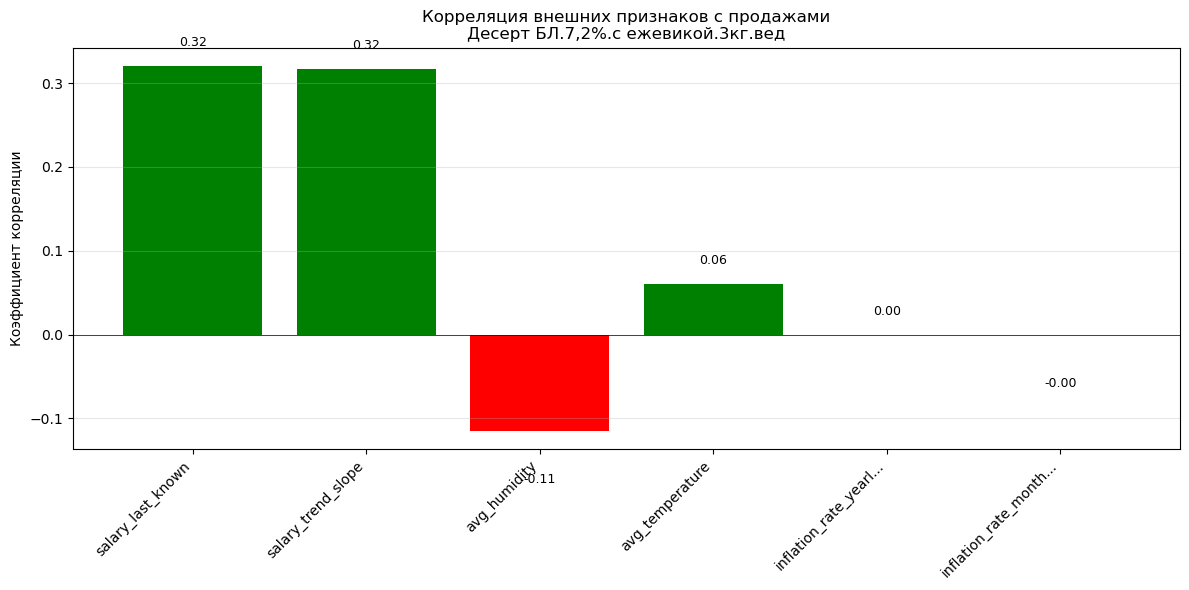


 Анализ для Десерт БЛ.7,2%.с ежевикой.3кг.вед завершен
 Память очищена


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import gc

# ============================================
# ЗАГРУЖАЕМ УЖЕ ОБОГАЩЕННЫЙ ДАТАСЕТ
# ============================================

# Загружаем сохраненный обогащенный датасет
full_df_enriched = pd.read_parquet('/home/jovyan/work/data/processed/full_sales_data_final.parquet')

print(f" Загружен обогащенный датасет:")
print(f"   Записей: {len(full_df_enriched):,}")
print(f"   Колонок: {len(full_df_enriched.columns)}")
print(f"   Уникальных товаров: {full_df_enriched['Номенклатура'].nunique()}")
print(f"   Уникальных городов: {full_df_enriched['city'].nunique()}")

# Получаем список товаров из датасета
products = full_df_enriched['Номенклатура'].unique().tolist()
print(f"\n Товары в датасете ({len(products)} шт.):")
for i, p in enumerate(products[:5], 1):
    print(f"   {i}. {p[:70]}...")
if len(products) > 5:
    print(f"   ... и еще {len(products)-5}")

# ============================================
# ФУНКЦИЯ ДЛЯ АНАЛИЗА ВНЕШНИХ ПРИЗНАКОВ
# ============================================
def analyze_external_features(df, product_name):
    """Анализирует влияние внешних признаков на продажи и показывает один график"""
    
    print("\n" + "="*60)
    print(f" АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ для {product_name[:50]}")
    print("="*60)
    
    # Список внешних признаков для анализа
    external_features = [
        'avg_temperature', 'avg_humidity', 'inflation_rate_monthly', 
        'inflation_rate_yearly', 'key_rate', 'usd_rate', 'eur_rate',
        'total_population', 'salary_last_known', 'salary_trend_slope'
    ]
    
    # Проверяем, какие признаки есть в данных
    available_features = [f for f in external_features if f in df.columns]
    
    if not available_features:
        print(" Внешние признаки не найдены в датасете")
        return None, {}
    
    print(f"\n Доступные признаки ({len(available_features)}):")
    for f in available_features[:10]:
        print(f"   - {f}")
    
    # Корреляция с продажами
    print("\n КОРРЕЛЯЦИЯ С ПРОДАЖАМИ:")
    correlations = {}
    
    target_col = 'quantity' if 'quantity' in df.columns else 'Количество'
    
    for feature in available_features:
        if df[feature].notna().any() and df[target_col].notna().any():
            temp_df = df[[target_col, feature]].dropna()
            if len(temp_df) > 5:
                try:
                    corr = temp_df[target_col].corr(temp_df[feature])
                    if np.isfinite(corr):
                        correlations[feature] = corr
                        direction = " " if corr > 0 else " "
                        strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
                        print(f"   {direction} {feature}: {corr:.3f} ({strength})")
                except:
                    pass
    
    # Топ-3 самых влияющих признаков
    if correlations:
        print("\n ТОП-3 ВЛИЯЮЩИХ ПРИЗНАКА:")
        top_features = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
        for feat, corr in top_features:
            direction = "положительная" if corr > 0 else "отрицательная"
            print(f"   1. {feat}: {corr:.3f} ({direction})")
    
    # ЕДИНСТВЕННЫЙ ГРАФИК - корреляция
    if correlations and len(correlations) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Берем топ-10 признаков
        top_items = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
        features = [f[:20] + '...' if len(f) > 20 else f for f, _ in top_items]
        values = [v for _, v in top_items]
        colors = ['green' if v > 0 else 'red' for v in values]
        
        bars = ax.bar(range(len(features)), values, color=colors)
        ax.set_xticks(range(len(features)))
        ax.set_xticklabels(features, rotation=45, ha='right')
        ax.set_title(f'Корреляция внешних признаков с продажами\n{product_name[:50]}')
        ax.set_ylabel('Коэффициент корреляции')
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Добавляем подписи значений
        for i, v in enumerate(values):
            offset = 0.02 if v > 0 else -0.05
            va = 'bottom' if v > 0 else 'top'
            ax.text(i, v + offset, f'{v:.2f}', ha='center', va=va, fontsize=9)
        
        plt.tight_layout()
        plt.show()
        return fig, correlations
    
    return None, correlations

# ============================================
# ОСНОВНОЙ АНАЛИЗ (ТОЛЬКО ДЛЯ ПЕРВОГО ТОВАРА)
# ============================================

# Берем только первый товар
first_product = products[0]
print(f"\n{'='*70}")
print(f" АНАЛИЗ НОМЕНКЛАТУРЫ: {first_product[:70]}")
print('='*70)

# Берем данные для первого товара
df = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()

if df.empty:
    print(f" Нет данных для {first_product[:50]}")
else:
    # Определяем названия колонок
    date_col = 'date'
    city_col = 'city'
    counterparty_col = 'counterparty'
    amount_col = 'amount'
    quantity_col = 'quantity'
    price_col = 'price'
    
    print(f"\n БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"   Записей: {len(df):,}")
    print(f"   Период: {df[date_col].min()} - {df[date_col].max()}")
    print(f"   Городов: {df[city_col].nunique()}")
    print(f"   Контрагентов: {df[counterparty_col].nunique()}")
    
    # СТАТИСТИКА ПРОДАЖ
    print(f"\n СТАТИСТИКА ПРОДАЖ:")
    stats = df[quantity_col].describe()
    for stat_name, value in stats.items():
        print(f"   {stat_name}: {value:.2f}")
    
    # ТОП-10 ПРОДАЖ
    print(f"\n ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:")
    top_sales = df.nlargest(10, quantity_col)[[date_col, quantity_col, amount_col, city_col]]
    for i, row in top_sales.iterrows():
        print(f"   {row[date_col]}: {row[quantity_col]} шт, {row[amount_col]:.2f} руб, {row[city_col]}")
    
    # СТАТИСТИКА ПО КОНТРАГЕНТАМ
    print(f"\n ТОП-10 КОНТРАГЕНТОВ:")
    kontr_stats = df.groupby(counterparty_col).agg({
        quantity_col: 'sum',
        amount_col: 'sum',
        counterparty_col: 'count'
    }).rename(columns={counterparty_col: 'orders'}).round(2)
    kontr_stats = kontr_stats.sort_values(amount_col, ascending=False).head(10)
    
    for i, (kontr, row) in enumerate(kontr_stats.iterrows(), 1):
        print(f"   {i}. {kontr[:30]:<30} - сумма: {row[amount_col]:>12,.2f} руб, заказов: {row['orders']:>4}")
    
    # СТАТИСТИКА ПО ГОРОДАМ
    print(f"\n ТОП-10 ГОРОДОВ:")
    city_stats = df.groupby(city_col).agg({
        quantity_col: 'sum',
        amount_col: 'sum',
        city_col: 'count'
    }).rename(columns={city_col: 'orders'}).round(2)
    city_stats = city_stats.sort_values(amount_col, ascending=False).head(10)
    
    for i, (city, row) in enumerate(city_stats.iterrows(), 1):
        print(f"   {i}. {city[:20]:<20} - сумма: {row[amount_col]:>12,.2f} руб, заказов: {row['orders']:>4}")
    
    # АНАЛИЗ ПО МЕСЯЦАМ
    print(f"\n ПРОДАЖИ ПО МЕСЯЦАМ:")
    df['month'] = pd.to_datetime(df[date_col]).dt.month
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    monthly = df.groupby('month')[quantity_col].sum()
    
    for month in range(1, 13):
        if month in monthly.index:
            print(f"   {months[month-1]}: {monthly[month]:>8,.0f} шт")
    
    # АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ (С ГРАФИКОМ)
    fig_corr, correlations = analyze_external_features(df, first_product)
    
    # ИТОГ
    print(f"\n{'='*70}")
    print(f" Анализ для {first_product[:50]} завершен")
    print('='*70)
    
    # Очистка памяти
    plt.close('all')
    gc.collect()
    print(" Память очищена")

In [30]:

#функция версионирвоаиня, добавим после наполнениявсех признаков
import json
import pickle
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from minio import Minio
from io import BytesIO
import re

def save_datasets_to_minio(
    train_df, 
    test_df=None, 
    product_name=None,
    bucket_name="ml-datasets",
    version=None,
    split_info=None
):
    """
    Сохраняет train/test датасеты в Minio с правильной структурой
    
    Parameters:
    train_df, test_df: DataFrame
    product_name: название продукта
    bucket_name: бакет в Minio
    version: версия датасета (если None, создается автоматически)
    split_info: дополнительная информация о разделении
    """
    
    # Подключение к Minio
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    # Создаем бакет если нет
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    # Очищаем имя продукта для пути
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    # Формируем версию
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Базовый путь
    base_path = f"datasets/{clean_name}/train_test_split"
    
    saved_files = []
    
    # 1. Сохраняем train как parquet (эффективнее csv)
    train_buffer = BytesIO()
    train_df.to_parquet(train_buffer, index=False)
    train_buffer.seek(0)
    
    train_path = f"{base_path}/train_{version}.parquet"
    client.put_object(
        bucket_name,
        train_path,
        data=train_buffer,
        length=train_buffer.getbuffer().nbytes,
        content_type='application/parquet'
    )
    saved_files.append(f"{bucket_name}/{train_path}")
    print(f" Train сохранен: {train_path}")
    
    # 2. Сохраняем test
    if test_df is not None:
        test_buffer = BytesIO()
        test_df.to_parquet(test_buffer, index=False)
        test_buffer.seek(0)
        
        test_path = f"{base_path}/test_{version}.parquet"
        client.put_object(
            bucket_name,
            test_path,
            data=test_buffer,
            length=test_buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
        saved_files.append(f"{bucket_name}/{test_path}")
        print(f" Test сохранен: {test_path}")
    
    # 3. Сохраняем метаданные о разделении
    if split_info is None:
        split_info = {
            'product': product_name,
            'version': version,
            'train_size': len(train_df),
            'test_size': len(test_df),
            'train_period': {
                'start': str(train_df['Дата'].min()),
                'end': str(train_df['Дата'].max())
            },
            'test_period': {
                'start': str(test_df['Дата'].min()),
                'end': str(test_df['Дата'].max())
            },
            'features': list(train_df.columns),
            'created_at': datetime.now().isoformat()
        }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(split_info, indent=2, ensure_ascii=False).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/split_info_{version}.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" Метаданные сохранены: {meta_path}")
    
    return {
        'train_path': train_path,
        'test_path': test_path,
        'meta_path': meta_path,
        'version': version,
        'bucket': bucket_name,
        'files': saved_files
    }


def load_datasets_from_minio(
    bucket_name="ml-datasets",
    product_name=None,
    version=None,
    latest=True
):
    """
    Загружает датасеты из Minio
    
    Если latest=True, берет последнюю версию
    Иначе нужно указать version
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    base_path = f"datasets/{clean_name}/train_test_split"
    
    if latest:
        # Находим последнюю версию
        objects = list(client.list_objects(bucket_name, prefix=base_path, recursive=True))
        versions = set()
        for obj in objects:
            if 'train_' in obj.object_name:
                ver = obj.object_name.split('train_')[-1].split('.parquet')[0]
                versions.add(ver)
        
        if not versions:
            raise ValueError(f"Нет датасетов для продукта {product_name}")
        
        version = sorted(versions)[-1]
        print(f"Загружаем последнюю версию: {version}")
    
    # Загружаем train
    train_path = f"{base_path}/train_{version}.parquet"
    train_response = client.get_object(bucket_name, train_path)
    train_df = pd.read_parquet(BytesIO(train_response.read()))
    
    # Загружаем test
    test_path = f"{base_path}/test_{version}.parquet"
    test_response = client.get_object(bucket_name, test_path)
    test_df = pd.read_parquet(BytesIO(test_response.read()))
    
    # Загружаем метаданные
    meta_path = f"{base_path}/split_info_{version}.json"
    try:
        meta_response = client.get_object(bucket_name, meta_path)
        meta_info = json.loads(meta_response.read().decode())
    except:
        meta_info = None
    
    print(f" Загружено: train={len(train_df)}, test={len(test_df)}")
    return train_df, test_df, meta_info


def save_features_to_minio(
    X_train, X_test, y_train, y_test,
    feature_names,
    product_name,
    version=None
):
    """
    Сохраняет признаки и целевые переменные для модели
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    bucket_name = "ml-datasets"
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    base_path = f"features/{clean_name}/{version}"
    
    # Сохраняем признаки
    features_dict = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': feature_names
    }
    
    for name, data in features_dict.items():
        buffer = BytesIO()
        
        if isinstance(data, pd.DataFrame) or isinstance(data, pd.Series):
            data.to_parquet(buffer)
        elif isinstance(data, np.ndarray):
            pd.DataFrame(data).to_parquet(buffer)
        else:
            # для списков и простых типов
            buffer.write(json.dumps(data).encode())
            buffer.seek(0)
            client.put_object(
                bucket_name,
                f"{base_path}/{name}.json",
                data=buffer,
                length=buffer.getbuffer().nbytes,
                content_type='application/json'
            )
            continue
        
        buffer.seek(0)
        client.put_object(
            bucket_name,
            f"{base_path}/{name}.parquet",
            data=buffer,
            length=buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
    
    print(f" Признаки сохранены: {base_path}")

In [99]:
# Ячейка 1: Импорты
import pandas as pd
import numpy as np
from clickhouse_driver import Client

# Ячейка 2: Загрузка сохраненного датасета
import os
if os.path.exists('/home/jovyan/work/data/processed/full_sales_data_final.parquet'):
    full_df_enriched = pd.read_parquet('/home/jovyan/work/data/processed/full_sales_data_final.parquet')
    print(f"Загружен датасет: {full_df_enriched.shape}")
else:
    print("Файл не найден, нужно выполнить ячейки с загрузкой из ClickHouse")

Загружен датасет: (18070, 71)


In [31]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

# Получаем список уникальных товаров из обогащенного датасета
products_list = full_df_enriched['Номенклатура'].unique().tolist()
print(f" Всего товаров для анализа: {len(products_list)}")

# Берем только первый товар
first_product = products_list[0]
print(f"\n{'='*70}")
print(f" АНАЛИЗ НОМЕНКЛАТУРЫ: {first_product[:70]}")
print('='*70)

# Фильтруем данные для первого товара
df = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()

if df.empty:
    print(f" Нет данных для {first_product[:50]}")
else:
    # Определяем названия колонок
    date_col = 'date'
    target_col = 'quantity' if 'quantity' in df.columns else 'Количество'
    amount_col = 'amount' if 'amount' in df.columns else 'Сумма'
    price_col = 'price' if 'price' in df.columns else 'Цена'
    city_col = 'city'
    counterparty_col = 'counterparty'
    
    # Базовая информация
    print(f"\n БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"   Записей: {len(df):,}")
    print(f"   Период: {df[date_col].min()} - {df[date_col].max()}")
    print(f"   Городов: {df[city_col].nunique()}")
    print(f"   Контрагентов: {df[counterparty_col].nunique()}")
    
    # Статистика продаж
    print(f"\n СТАТИСТИКА ПРОДАЖ:")
    stats = df[target_col].describe()
    for stat_name, value in stats.items():
        print(f"   {stat_name}: {value:.2f}")
    
    # Топ-10 продаж
    print(f"\n ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:")
    top_cols = [date_col, target_col, price_col, amount_col, city_col]
    if all(col in df.columns for col in top_cols):
        top_sales = df.nlargest(10, target_col)[top_cols]
        for i, row in top_sales.iterrows():
            print(f"   {row[date_col]}: {row[target_col]} шт, {row[amount_col]:.2f} руб, {row[city_col]}")
    
    # Статистика по контрагентам
    print(f"\n ТОП-10 КОНТРАГЕНТОВ:")
    kontr_stats = df.groupby(counterparty_col).agg({
        target_col: ['sum', 'mean', 'count'],
        amount_col: 'sum'
    }).round(2)
    kontr_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
    kontr_stats = kontr_stats.sort_values('сумма_руб', ascending=False).head(10)
    
    for i, (kontr, row) in enumerate(kontr_stats.iterrows(), 1):
        print(f"   {i}. {kontr[:30]:<30} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    # Статистика по городам
    print(f"\n ТОП-10 ГОРОДОВ:")
    city_stats = df.groupby(city_col).agg({
        target_col: ['sum', 'mean', 'count'],
        amount_col: 'sum'
    }).round(2)
    city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
    city_stats = city_stats.sort_values('сумма_руб', ascending=False).head(10)
    
    for i, (city, row) in enumerate(city_stats.iterrows(), 1):
        print(f"   {i}. {city[:20]:<20} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    # Анализ временных признаков
    print(f"\n АНАЛИЗ ПО ВРЕМЕНИ:")
    
    # Создаем временные признаки
    df['год'] = pd.to_datetime(df[date_col]).dt.year
    df['месяц'] = pd.to_datetime(df[date_col]).dt.month
    df['день_недели'] = pd.to_datetime(df[date_col]).dt.dayofweek
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    
    # По месяцам
    monthly = df.groupby('месяц')[target_col].sum()
    print(f"\n   Продажи по месяцам:")
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    for month in range(1, 13):
        if month in monthly.index:
            print(f"     {months[month-1]}: {monthly[month]:>8,.0f} шт")
    
    # По дням недели
    weekly = df.groupby('день_недели')[target_col].sum()
    print(f"\n   Продажи по дням недели:")
    for day in range(7):
        if day in weekly.index:
            print(f"     {days[day]}: {weekly[day]:>8,.0f} шт")
    
    # Анализ внешних признаков (корреляции)
    print(f"\n АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ:")
    
    external_features = [
        'avg_temperature', 'avg_humidity', 'inflation_rate_monthly', 
        'inflation_rate_yearly', 'key_rate', 'usd_rate', 'eur_rate',
        'total_population', 'salary_last_known', 'salary_trend_slope'
    ]
    
    available = [f for f in external_features if f in df.columns]
    
    if available:
        correlations = []
        for feature in available:
            if df[feature].notna().any() and df[target_col].notna().any():
                temp_df = df[[target_col, feature]].dropna()
                if len(temp_df) > 5:
                    corr = temp_df[target_col].corr(temp_df[feature])
                    if np.isfinite(corr):
                        correlations.append((feature, corr))
        
        if correlations:
            correlations.sort(key=lambda x: abs(x[1]), reverse=True)
            print(f"\n   Топ-5 признаков по влиянию на продажи:")
            for feat, corr in correlations[:5]:
                direction = " " if corr > 0 else " "
                strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
                print(f"     {direction} {feat}: {corr:.3f} ({strength})")
    
    # Простая статистика по ценам
    print(f"\n АНАЛИЗ ЦЕН:")
    price_stats = df[price_col].describe()
    print(f"   Средняя цена: {price_stats['mean']:.2f} руб")
    print(f"   Мин цена: {price_stats['min']:.2f} руб")
    print(f"   Макс цена: {price_stats['max']:.2f} руб")
    print(f"   Медианная цена: {price_stats['50%']:.2f} руб")
    
    print(f"\n Анализ завершен")

# Для остальных товаров можно вывести только базовую статистику
print(f"\n{'='*70}")
print(f" КРАТКАЯ СТАТИСТИКА ПО ВСЕМ ТОВАРАМ")
print('='*70)

for i, product in enumerate(products_list[:5], 1):  # первые 5 товаров
    df_temp = full_df_enriched[full_df_enriched['Номенклатура'] == product]
    print(f"\n{i}. {product[:50]}...")
    print(f"   Записей: {len(df_temp):,}")
    print(f"   Городов: {df_temp['city'].nunique()}")
    print(f"   Сумма: {df_temp['amount'].sum():,.2f} руб")

if len(products_list) > 5:
    print(f"\n... и еще {len(products_list) - 5} товаров")

 Всего товаров для анализа: 7

 АНАЛИЗ НОМЕНКЛАТУРЫ: Десерт БЛ.7,2%.с ежевикой.3кг.вед

 БАЗОВАЯ ИНФОРМАЦИЯ:
   Записей: 745
   Период: 2026-01-05 02:12:52 - 2026-03-20 05:17:22
   Городов: 31
   Контрагентов: 67

 СТАТИСТИКА ПРОДАЖ:
   count: 745.00
   mean: 30.86
   std: 43.16
   min: 3.00
   25%: 9.00
   50%: 15.00
   75%: 36.00
   max: 390.00

 ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону
   2026-02-07 18:49:12: 300.0 шт, 42600.00 руб, Ростов-на-Дону
   2026-02-07 18:49:12: 300.0 шт, 42600.00 руб, Ростов-на-Дону
   2026-02-07 18:49:12: 300.0 шт, 42600.00 руб, Ростов-на-Дону
   2026-01-18 10:02:00: 150.0 шт, 21300.00 руб, Росто

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



   Топ-5 признаков по влиянию на продажи:
       salary_last_known: 0.320 (средняя)
       salary_trend_slope: 0.317 (средняя)
       avg_humidity: -0.115 (слабая)
       avg_temperature: 0.061 (слабая)
       inflation_rate_yearly: 0.000 (слабая)

 АНАЛИЗ ЦЕН:
   Средняя цена: 153.51 руб
   Мин цена: 115.00 руб
   Макс цена: 180.55 руб
   Медианная цена: 155.00 руб

 Анализ завершен

 КРАТКАЯ СТАТИСТИКА ПО ВСЕМ ТОВАРАМ

1. Десерт БЛ.7,2%.с ежевикой.3кг.вед...
   Записей: 745
   Городов: 31
   Сумма: 3,523,024.50 руб

2. Десерт БЛ.7,2%.с малиной.3кг.вед...
   Записей: 1,352
   Городов: 42
   Сумма: 10,332,802.50 руб

3. Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж...
   Записей: 1,040
   Городов: 28
   Сумма: 34,466,760.00 руб

4. Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5...
   Записей: 5,048
   Городов: 50
   Сумма: 36,715,911.00 руб

5. Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед...
   Записей: 1,242
   Городов: 50
   Сумма: 14,310,294.00 руб

... и еще 2 товаров


In [6]:
#статистику временных продаж переместил в блок выше

In [32]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import gc

# ============================================
# ЗАГРУЖАЕМ ОБОГАЩЕННЫЙ ДАТАСЕТ
# ============================================

full_df_enriched = pd.read_parquet('/home/jovyan/work/data/processed/full_sales_data_final.parquet')

print(f" Загружен обогащенный датасет:")
print(f"   Записей: {len(full_df_enriched):,}")
print(f"   Колонок: {len(full_df_enriched.columns)}")
print(f"   Уникальных товаров: {full_df_enriched['Номенклатура'].nunique()}")
print(f"   Уникальных городов: {full_df_enriched['city'].nunique()}")

# Получаем список товаров
products_list = full_df_enriched['Номенклатура'].unique().tolist()
print(f"\n Товары в датасете ({len(products_list)} шт.)")

# ============================================
# ФУНКЦИЯ СОЗДАНИЯ ВРЕМЕННЫХ ПРИЗНАКОВ
# ============================================

def create_time_features(df_product):
    """
    Добавляет временные признаки для анализа
    """
    df = df_product.copy()
    
    # Убеждаемся, что date в правильном формате
    df['date'] = pd.to_datetime(df['date'])
    
    # Базовые временные признаки
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['week'] = df['date'].dt.isocalendar().week
    
    # Циклические признаки
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Бинарные флаги
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    return df

# ============================================
# АНАЛИЗ ЛАГОВЫХ ПРИЗНАКОВ
# ============================================

def analyze_lag_features(df_product):
    """
    Анализирует лаговые признаки без визуализации
    """
    # Создаем лаговые признаки, если их нет
    if 'quantity_lag_1' not in df_product.columns:
        df_product = df_product.sort_values('date')
        for lag in [1, 3, 6, 12, 24]:
            df_product[f'quantity_lag_{lag}'] = df_product['quantity'].shift(lag)
        for window in [3, 6, 12, 24]:
            df_product[f'quantity_rolling_mean_{window}'] = (
                df_product['quantity'].rolling(window=window, min_periods=1).mean()
            )
    
    # Лаговые признаки для анализа
    lag_features = ['quantity_lag_1', 'quantity_lag_3', 'quantity_lag_6', 
                    'quantity_lag_12', 'quantity_lag_24', 'quantity_lag_168']
    
    existing_lags = [f for f in lag_features if f in df_product.columns]
    
    if existing_lags:
        print("\n АНАЛИЗ ЛАГОВЫХ ПРИЗНАКОВ:")
        
        # Корреляция с текущими продажами
        correlations = {}
        for lag in existing_lags:
            temp_df = df_product[['quantity', lag]].dropna()
            if len(temp_df) > 10:
                corr = temp_df['quantity'].corr(temp_df[lag])
                if np.isfinite(corr):
                    correlations[lag] = corr
        
        if correlations:
            print("\n   Корреляция текущих продаж с лагами:")
            for lag, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
                print(f"     {lag}: {corr:.3f}")
        
        # Пропуски в лагах
        print("\n   Пропуски в лаговых признаках:")
        for lag in existing_lags:
            missing = df_product[lag].isna().sum()
            pct = (missing / len(df_product)) * 100
            print(f"     {lag}: {missing} пропусков ({pct:.1f}%)")
    
    return df_product

# ============================================
# СТАТИСТИКА ПО ОРГАНИЗАЦИЯМ И ГОРОДАМ
# ============================================

def analyze_categorical_features(df_product):
    """
    Анализирует категориальные признаки
    """
    print("\n СТАТИСТИКА ПО ОРГАНИЗАЦИЯМ:")
    
    # Статистика по организациям
    if 'organization' in df_product.columns:
        org_stats = df_product.groupby('organization').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': ['sum', 'mean']
        }).round(2)
        org_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб', 'средний_чек']
        org_stats = org_stats.sort_values('сумма_руб', ascending=False).head(10)
        
        for i, (org, row) in enumerate(org_stats.iterrows(), 1):
            print(f"   {i}. {str(org)[:30]:<30} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    print("\n СТАТИСТИКА ПО ГОРОДАМ:")
    
    # Статистика по городам
    if 'city' in df_product.columns:
        city_stats = df_product.groupby('city').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': ['sum', 'mean']
        }).round(2)
        city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб', 'средний_чек']
        city_stats = city_stats.sort_values('сумма_руб', ascending=False).head(10)
        
        for i, (city, row) in enumerate(city_stats.iterrows(), 1):
            print(f"   {i}. {city[:20]:<20} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    print("\n СТАТИСТИКА ПО КОНТРАГЕНТАМ:")
    
    # Статистика по контрагентам
    if 'counterparty' in df_product.columns:
        kontr_stats = df_product.groupby('counterparty').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': ['sum', 'mean']
        }).round(2)
        kontr_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб', 'средний_чек']
        kontr_stats = kontr_stats.sort_values('сумма_руб', ascending=False).head(10)
        
        for i, (kontr, row) in enumerate(kontr_stats.iterrows(), 1):
            print(f"   {i}. {str(kontr)[:30]:<30} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")

# ============================================
# АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ
# ============================================

def analyze_external_features(df_product):
    """
    Анализирует внешние признаки без визуализации
    """
    external_features = [
        'avg_temperature', 'avg_humidity', 'inflation_rate_monthly',
        'inflation_rate_yearly', 'key_rate', 'usd_rate', 'eur_rate',
        'total_population', 'salary_last_known', 'salary_trend_slope',
        'salary_avg_annual_growth', 'salary_growth_3y'
    ]
    
    available = [f for f in external_features if f in df_product.columns]
    
    if available:
        print("\n АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ:")
        
        # Корреляция с продажами
        correlations = {}
        for feat in available:
            temp_df = df_product[['quantity', feat]].dropna()
            if len(temp_df) > 10:
                corr = temp_df['quantity'].corr(temp_df[feat])
                if np.isfinite(corr):
                    correlations[feat] = corr
        
        if correlations:
            print("\n   Корреляция внешних признаков с продажами:")
            for feat, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:10]:
                direction = " " if corr > 0 else " "
                strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
                print(f"     {direction} {feat}: {corr:.3f} ({strength})")
        
        # Статистика внешних признаков
        print("\n   Статистика внешних признаков:")
        for feat in available[:5]:
            print(f"     {feat}: среднее={df_product[feat].mean():.2f}, "
                  f"мин={df_product[feat].min():.2f}, макс={df_product[feat].max():.2f}")

# ============================================
# ОСНОВНОЙ АНАЛИЗ (ТОЛЬКО ПЕРВЫЙ ТОВАР)
# ============================================

first_product = products_list[0]
print(f"\n{'='*70}")
print(f" АНАЛИЗ ТОВАРА: {first_product[:70]}")
print('='*70)

# Получаем данные для первого товара
df_product = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()

if df_product.empty:
    print(f" Нет данных для {first_product[:50]}")
else:
    # 1. СОЗДАЕМ ВРЕМЕННЫЕ ПРИЗНАКИ
    df_product = create_time_features(df_product)
    
    # 2. БАЗОВАЯ ИНФОРМАЦИЯ
    print(f"\n БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"   Записей: {len(df_product):,}")
    print(f"   Период: {df_product['date'].min()} - {df_product['date'].max()}")
    print(f"   Городов: {df_product['city'].nunique()}")
    print(f"   Организаций: {df_product['organization'].nunique()}")
    print(f"   Контрагентов: {df_product['counterparty'].nunique()}")
    
    # 3. СТАТИСТИКА ПРОДАЖ
    print(f"\n СТАТИСТИКА ПРОДАЖ:")
    stats = df_product['quantity'].describe()
    for stat_name, value in stats.items():
        print(f"   {stat_name}: {value:.2f}")
    
    # 4. ТОП-10 ПРОДАЖ
    print(f"\n ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:")
    top_sales = df_product.nlargest(10, 'quantity')[['date', 'quantity', 'amount', 'city']]
    for i, row in top_sales.iterrows():
        print(f"   {row['date']}: {row['quantity']} шт, {row['amount']:.2f} руб, {row['city']}")
    
    # 5. АНАЛИЗ ПО ВРЕМЕНИ
    print(f"\n ПРОДАЖИ ПО ЧАСАМ:")
    hourly = df_product.groupby('hour')['quantity'].agg(['sum', 'mean'])
    peak_hour = hourly['sum'].idxmax()
    print(f"   Пиковый час: {peak_hour}:00 (продаж: {hourly.loc[peak_hour, 'sum']:.0f} шт)")
    
    print(f"\n ПРОДАЖИ ПО ДНЯМ НЕДЕЛИ:")
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    weekly = df_product.groupby('dayofweek')['quantity'].sum()
    for day in range(7):
        if day in weekly.index:
            print(f"   {days[day]}: {weekly[day]:.0f} шт")
    
    print(f"\n ПРОДАЖИ ПО МЕСЯЦАМ:")
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    monthly = df_product.groupby('month')['quantity'].sum()
    for month in range(1, 13):
        if month in monthly.index:
            print(f"   {months[month-1]}: {monthly[month]:.0f} шт")
    
    # 6. АНАЛИЗ ЛАГОВЫХ ПРИЗНАКОВ
    df_product = analyze_lag_features(df_product)
    
    # 7. АНАЛИЗ ПО ОРГАНИЗАЦИЯМ И ГОРОДАМ
    analyze_categorical_features(df_product)
    
    # 8. АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ
    analyze_external_features(df_product)
    
    # 9. ИТОГОВАЯ СТАТИСТИКА
    print(f"\n ИТОГОВАЯ СТАТИСТИКА:")
    print(f"   Всего записей: {len(df_product)}")
    print(f"   Всего признаков: {len(df_product.columns)}")
    print(f"   Числовых признаков: {len(df_product.select_dtypes(include=[np.number]).columns)}")
    
    # Список всех признаков
    print(f"\n СПИСОК ВСЕХ ПРИЗНАКОВ ({len(df_product.columns)}):")
    for i, col in enumerate(sorted(df_product.columns), 1):
        dtype = df_product[col].dtype
        non_null = df_product[col].notna().sum()
        print(f"   {i:3d}. {col:35} ({dtype}) - заполнено: {non_null}/{len(df_product)}")
    
    # 10. СОХРАНЕНИЕ В ФАЙЛ (опционально)
    output_path = '/home/jovyan/work/data/processed/first_product_with_features.parquet'
    df_product.to_parquet(output_path)
    print(f"\n Датасет с признаками сохранен: {output_path}")
    
    print(f"\n{'='*70}")
    print(f" Анализ завершен")
    print('='*70)

# Очистка памяти
gc.collect()
print("\n Память очищена")

 Загружен обогащенный датасет:
   Записей: 13,741
   Колонок: 71
   Уникальных товаров: 7
   Уникальных городов: 66

 Товары в датасете (7 шт.)

 АНАЛИЗ ТОВАРА: Десерт БЛ.7,2%.с ежевикой.3кг.вед

 БАЗОВАЯ ИНФОРМАЦИЯ:
   Записей: 745
   Период: 2026-01-05 02:12:52 - 2026-03-20 05:17:22
   Городов: 31
   Организаций: 2
   Контрагентов: 67

 СТАТИСТИКА ПРОДАЖ:
   count: 745.00
   mean: 30.86
   std: 43.16
   min: 3.00
   25%: 9.00
   50%: 15.00
   75%: 36.00
   max: 390.00

 ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-22 01:01:19: 390.0 шт, 55380.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону
   2026-02-14 16:08:54: 330.0 шт, 46860.00 руб, Ростов-на-Дону
   2026-02-07 18:49:12: 300.0 шт, 42600.00 руб, Ростов-на-Дону
   2026-02-07 18:49:12: 300.0 шт, 42600.00 руб, Росто

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    20. day                                 (int32) - заполнено: 745/745
    21. day_of_year                         (int32) - заполнено: 745/745
    22. dayofweek                           (int32) - заполнено: 745/745
    23. dow_cos                             (float64) - заполнено: 745/745
    24. dow_sin                             (float64) - заполнено: 745/745
    25. eur_rate                            (float64) - заполнено: 0/745
    26. female_population                   (int64) - заполнено: 745/745
    27. hour                                (int32) - заполнено: 745/745
    28. hour_cos                            (float64) - заполнено: 745/745
    29. hour_sin                            (float64) - заполнено: 745/745
    30. inflation_rate_monthly              (float64) - заполнено: 745/745
    31. inflation_rate_yearly               (float64) - заполнено: 745/745
    32. is_weekend                          (int64) - заполнено: 745/745
    33. key_rate                       

In [34]:
full_df_enriched.shape

(13741, 71)

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Агрегируем по дням
daily_sales = df_product.groupby(df_product['date'].dt.date)['quantity'].sum()
daily_sales.index = pd.to_datetime(daily_sales.index)

print(f"\n{'='*60}")
print(" АНАЛИЗ СЕЗОННОСТИ (ЕЖЕДНЕВНОЙ)")
print('='*60)
print(f" Ежедневные продажи: {len(daily_sales)} дней")

if len(daily_sales) >= 14:
    decomposition = seasonal_decompose(daily_sales, model='additive', period=7)
    
    print("\n СТАТИСТИКА КОМПОНЕНТ:")
    print(f"   Тренд:")
    print(f"     Минимум: {decomposition.trend.min():.0f}")
    print(f"     Максимум: {decomposition.trend.max():.0f}")
    print(f"     Среднее: {decomposition.trend.mean():.0f}")
    
    print(f"\n   Сезонная компонента (по дням недели):")
    seasonal_values = decomposition.seasonal[:7].values
    days_of_week = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
    
    for i, val in enumerate(seasonal_values):
        day_name = days_of_week[i]
        direction = " выше среднего" if val > 0 else " ниже среднего"
        print(f"     {day_name}: {val:+.1f} ({direction})")
    
    print(f"\n   Остатки (случайная компонента):")
    print(f"     Минимум: {decomposition.resid.min():.0f}")
    print(f"     Максимум: {decomposition.resid.max():.0f}")
    print(f"     Стандартное отклонение: {decomposition.resid.std():.1f}")
    
    # Анализ силы сезонности
    seasonal_strength = abs(decomposition.seasonal).mean() / daily_sales.mean() * 100
    print(f"\n СИЛА СЕЗОННОСТИ:")
    print(f"   Среднее отклонение из-за сезонности: {abs(decomposition.seasonal).mean():.1f} шт ({seasonal_strength:.1f}% от средних продаж)")
    
    if seasonal_strength > 20:
        print("   Вывод: Сезонность сильная, учитывайте день недели в прогнозах")
    elif seasonal_strength > 10:
        print("   Вывод: Сезонность средняя, день недели влияет на продажи")
    else:
        print("   Вывод: Сезонность слабая, день недели почти не влияет")
    
    # Топ-3 дня
    print(f"\n ДНИ С МАКСИМАЛЬНЫМИ ОТКЛОНЕНИЯМИ:")
    seasonal_with_days = list(zip(days_of_week, seasonal_values))
    seasonal_sorted = sorted(seasonal_with_days, key=lambda x: x[1], reverse=True)
    
    print("\n    Дни с продажами ВЫШЕ среднего:")
    for day_name, val in seasonal_sorted[:3]:
        if val > 0:
            print(f"      {day_name}: +{val:.1f} шт")
    
    print("\n    Дни с продажами НИЖЕ среднего:")
    for day_name, val in seasonal_sorted[-3:]:
        if val < 0:
            print(f"      {day_name}: {val:.1f} шт")
    
    # ИСПРАВЛЕННЫЙ ПРОГНОЗ
    print(f"\n ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ:")
    
    # Берем последнее значение тренда (не nan)
    last_valid_trend = decomposition.trend.dropna().iloc[-1]
    
    # Берем сезонность для следующей недели (циклически)
    next_week_seasonal = decomposition.seasonal[-7:].values
    
    for i, seasonal in enumerate(next_week_seasonal):
        forecast = last_valid_trend + seasonal
        # Округляем до целых
        forecast_rounded = int(round(forecast))
        print(f"   {days_of_week[i]}: ~{forecast_rounded} шт")
    
    # Дополнительная статистика
    print(f"\n ДОПОЛНИТЕЛЬНО:")
    print(f"   Средние продажи в пятницу: {daily_sales[daily_sales.index.dayofweek == 4].mean():.0f} шт")
    print(f"   Средние продажи в среду: {daily_sales[daily_sales.index.dayofweek == 2].mean():.0f} шт")
    print(f"   Разрыв между пятницей и средой: {daily_sales[daily_sales.index.dayofweek == 4].mean() - daily_sales[daily_sales.index.dayofweek == 2].mean():.0f} шт")
    
else:
    print("\n Недостаточно данных для декомпозиции (нужно минимум 14 дней)")


 АНАЛИЗ СЕЗОННОСТИ (ЕЖЕДНЕВНОЙ)
 Ежедневные продажи: 60 дней

 СТАТИСТИКА КОМПОНЕНТ:
   Тренд:
     Минимум: 150
     Максимум: 791
     Среднее: 395

   Сезонная компонента (по дням недели):
     Понедельник: -105.4 ( ниже среднего)
     Вторник: +80.4 ( выше среднего)
     Среда: +81.0 ( выше среднего)
     Четверг: -48.0 ( ниже среднего)
     Пятница: -122.2 ( ниже среднего)
     Суббота: +147.7 ( выше среднего)
     Воскресенье: -33.5 ( ниже среднего)

   Остатки (случайная компонента):
     Минимум: -446
     Максимум: 1151
     Стандартное отклонение: 294.3

 СИЛА СЕЗОННОСТИ:
   Среднее отклонение из-за сезонности: 87.7 шт (22.9% от средних продаж)
   Вывод: Сезонность сильная, учитывайте день недели в прогнозах

 ДНИ С МАКСИМАЛЬНЫМИ ОТКЛОНЕНИЯМИ:

    Дни с продажами ВЫШЕ среднего:
      Суббота: +147.7 шт
      Среда: +81.0 шт
      Вторник: +80.4 шт

    Дни с продажами НИЖЕ среднего:
      Четверг: -48.0 шт
      Понедельник: -105.4 шт
      Пятница: -122.2 шт

 ПРОГНОЗ НА С

In [36]:
print(f"\n{'='*60}")
print(f" ПРОВЕРКА И ДОБАВЛЕНИЕ ПРИЗНАКОВ для {first_product[:50]}")
print('='*60)

print(f"   Всего колонок: {len(df_product.columns)}")

# 1. Удаляем дубликаты колонок (на всякий случай)
df_product = df_product.loc[:, ~df_product.columns.duplicated()]
print(f"   После удаления дубликатов: {len(df_product.columns)}")

# 2. Проверяем, какие признаки уже есть (английские названия)
existing_features = {
    'org_mean_sales': 'org_mean_sales' in df_product.columns,
    'org_std_sales': 'org_std_sales' in df_product.columns,
    'counterparty_mean_sales': 'counterparty_mean_sales' in df_product.columns,
    'counterparty_std_sales': 'counterparty_std_sales' in df_product.columns,
    'type_wholesale': 'type_wholesale' in df_product.columns,
    'type_retail': 'type_retail' in df_product.columns,
    'type_small_retail': 'type_small_retail' in df_product.columns
}

print("\n Проверка наличия признаков:")
for feat, exists in existing_features.items():
    status = " есть" if exists else " нет"
    print(f"   {feat:25}: {status}")

# 3. Добавляем недостающие признаки по организациям
if not existing_features['org_mean_sales'] and 'organization' in df_product.columns:
    print("\n Добавляем признаки по организациям...")
    
    # Рассчитываем статистику по каждой организации
    org_stats = df_product.groupby('organization')['quantity'].agg(['mean', 'std']).fillna(0)
    org_stats_dict = org_stats.to_dict('index')
    
    # Добавляем признаки в датасет
    df_product['org_mean_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
    df_product['org_std_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    
    print(f"     Добавлены org_mean_sales, org_std_sales")
    print(f"    Среднее по организациям: {df_product['org_mean_sales'].mean():.1f}")
    print(f"    Стандартное отклонение: {df_product['org_std_sales'].mean():.1f}")

# 4. Добавляем недостающие признаки по контрагентам
if not existing_features['counterparty_mean_sales'] and 'counterparty' in df_product.columns:
    print("\n Добавляем признаки по контрагентам...")
    
    # Рассчитываем статистику по каждому контрагенту
    kontr_stats = df_product.groupby('counterparty')['quantity'].agg(['mean', 'std']).fillna(0)
    kontr_stats_dict = kontr_stats.to_dict('index')
    
    # Добавляем признаки в датасет
    df_product['counterparty_mean_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
    df_product['counterparty_std_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    
    print(f"     Добавлены counterparty_mean_sales, counterparty_std_sales")
    print(f"    Среднее по контрагентам: {df_product['counterparty_mean_sales'].mean():.1f}")
    print(f"    Стандартное отклонение: {df_product['counterparty_std_sales'].mean():.1f}")

# 5. Добавляем типы продаж (если нет)
if not any([existing_features['type_wholesale'], 
            existing_features['type_retail'], 
            existing_features['type_small_retail']]):
    
    print("\n Добавляем типы продаж...")
    
    # Используем квантили для определения границ
    q33 = df_product['quantity'].quantile(0.33)
    q67 = df_product['quantity'].quantile(0.67)
    
    print(f"   Границы типов продаж:")
    print(f"     Мелкие: < {q33:.1f}")
    print(f"     Средние: {q33:.1f} - {q67:.1f}")
    print(f"     Крупные: > {q67:.1f}")
    
    # Создаем категории
    df_product['sales_type'] = df_product['quantity'].apply(
        lambda x: 'wholesale' if x > q67 else ('medium' if x > q33 else 'small')
    )
    
    # Создаем dummy-переменные
    type_dummies = pd.get_dummies(df_product['sales_type'], prefix='type')
    df_product = pd.concat([df_product, type_dummies], axis=1)
    
    print(f"     Добавлены типы продаж:")
    for col in type_dummies.columns:
        count = type_dummies[col].sum()
        pct = (count / len(df_product)) * 100
        print(f"      {col}: {count} записей ({pct:.1f}%)")

# 6. Добавляем лаговые признаки, если их нет
lag_features = ['quantity_lag_1', 'quantity_lag_24', 'quantity_rolling_mean_24']
missing_lags = [f for f in lag_features if f not in df_product.columns]

if missing_lags:
    print("\n Добавляем лаговые признаки...")
    df_product = df_product.sort_values('date')
    
    if 'quantity_lag_1' not in df_product.columns:
        df_product['quantity_lag_1'] = df_product['quantity'].shift(1)
        print(f"     Добавлен quantity_lag_1")
    
    if 'quantity_lag_24' not in df_product.columns:
        df_product['quantity_lag_24'] = df_product['quantity'].shift(24)
        print(f"     Добавлен quantity_lag_24")
    
    if 'quantity_rolling_mean_24' not in df_product.columns:
        df_product['quantity_rolling_mean_24'] = df_product['quantity'].rolling(window=24, min_periods=1).mean()
        print(f"     Добавлен quantity_rolling_mean_24")

# 7. Проверка пропусков в новых признаках
print(f"\n ПРОВЕРКА ПРОПУСКОВ В НОВЫХ ПРИЗНАКАХ:")
new_features = ['org_mean_sales', 'org_std_sales', 
                'counterparty_mean_sales', 'counterparty_std_sales',
                'type_wholesale', 'type_medium', 'type_small',
                'quantity_lag_1', 'quantity_lag_24', 'quantity_rolling_mean_24']

for feat in new_features:
    if feat in df_product.columns:
        filled = df_product[feat].notna().sum()
        pct = (filled / len(df_product)) * 100
        print(f"   {feat:25}: заполнено {filled:6}/{len(df_product)} ({pct:5.1f}%)")

# 8. ИТОГ
print(f"\n{'='*60}")
print(" ИТОГОВАЯ ИНФОРМАЦИЯ")
print('='*60)
print(f"   Всего колонок: {len(df_product.columns)}")
print(f"   Размер датасета: {df_product.shape}")
print(f"   Числовых признаков: {len(df_product.select_dtypes(include=[np.number]).columns)}")

# Сохраняем обновленный датасет
output_path = '/home/jovyan/work/data/processed/first_product_with_features.parquet'
df_product.to_parquet(output_path)
print(f"\n Обновленный датасет сохранен: {output_path}")


 ПРОВЕРКА И ДОБАВЛЕНИЕ ПРИЗНАКОВ для Десерт БЛ.7,2%.с ежевикой.3кг.вед
   Всего колонок: 85
   После удаления дубликатов: 85

 Проверка наличия признаков:
   org_mean_sales           :  нет
   org_std_sales            :  нет
   counterparty_mean_sales  :  нет
   counterparty_std_sales   :  нет
   type_wholesale           :  нет
   type_retail              :  нет
   type_small_retail        :  нет

 Добавляем признаки по организациям...
     Добавлены org_mean_sales, org_std_sales
    Среднее по организациям: 30.9
    Стандартное отклонение: 42.9

 Добавляем признаки по контрагентам...
     Добавлены counterparty_mean_sales, counterparty_std_sales
    Среднее по контрагентам: 30.9
    Стандартное отклонение: 10.0

 Добавляем типы продаж...
   Границы типов продаж:
     Мелкие: < 12.0
     Средние: 12.0 - 30.0
     Крупные: > 30.0
     Добавлены типы продаж:
      type_medium: 288 записей (38.7%)
      type_small: 252 записей (33.8%)
      type_wholesale: 205 записей (27.5%)

 ПРОВЕРКА 

In [37]:
df_product.shape

(745, 93)

In [48]:
df_product.head()

,Номенклатура,Дата,Количество,Цена,Сумма,vat,Контрагент,Организация,Город,year,...,День_недели,Час,Неделя_года,Месяц_sin,Месяц_cos,День_недели_sin,День_недели_cos,Час_sin,Час_cos,Выходной
0,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 02:12:52,15.0,155.0,2325.0,419.26,Шалимов А.Н. ИП Маслозаводской пер.,"ООО ""7 Утра""",Орел,2026,...,0,2,2,0.5,0.866025,0.0,1.0,0.500000,0.866025,0
1,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 02:12:52,15.0,155.0,2325.0,419.26,Шалимов А.Н. ИП Маслозаводской пер.,"ООО ""7 Утра""",Орел,2026,...,0,2,2,0.5,0.866025,0.0,1.0,0.500000,0.866025,0
2,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 02:12:52,15.0,155.0,2325.0,419.26,Шалимов А.Н. ИП Маслозаводской пер.,"ООО ""7 Утра""",Орел,2026,...,0,2,2,0.5,0.866025,0.0,1.0,0.500000,0.866025,0
3,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 03:01:38,15.0,155.0,2325.0,0.00,Флигинских А.В. ИП-1 @@@ отсрочка,@@@,Белгород,2026,...,0,3,2,0.5,0.866025,0.0,1.0,0.707107,0.707107,0
4,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 14:57:14,30.0,115.0,3450.0,0.00,МОЛОЧНЫЙ РАЙ ООО Хлебозаводская @@@,@@@,Москва,2026,...,0,14,2,0.5,0.866025,0.0,1.0,-0.500000,-0.866025,0


In [38]:
#функция версионирования датасетов для Minio
import json
import pickle
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from minio import Minio
from io import BytesIO
import re

def save_datasets_to_minio(
    train_df, 
    test_df=None, 
    product_name=None,
    bucket_name="ml-datasets",
    version=None,
    split_info=None
):
    """
    Сохраняет train/test датасеты в Minio с версионированием
    """
    # Проверяем тип данных
    if not isinstance(train_df, pd.DataFrame):
        print(f" Ошибка: train_df должен быть DataFrame, а это {type(train_df)}")
        return None
    
    print(f"\n{'='*60}")
    print(f" СОХРАНЕНИЕ ДАТАСЕТА В MINIO")
    print('='*60)
    print(f"   Продукт: {product_name[:50]}")
    print(f"   Train: {train_df.shape}, Test: {test_df.shape if test_df is not None else 'None'}")
    
    # Подключение к Minio
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
        # Проверка подключения
        client.list_buckets()
        print(" Подключение к Minio успешно")
    except Exception as e:
        print(f" Ошибка подключения к Minio: {e}")
        print("   Проверьте настройки подключения")
        return None
    
    # Создаем бакет если нет
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    # Очищаем имя продукта для пути
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    # Формируем версию
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Базовый путь
    base_path = f"datasets/{clean_name}/train_test_split"
    
    saved_files = []
    
    # Определяем колонку даты (date или Дата)
    date_col = 'date' if 'date' in train_df.columns else 'Дата'
    
    # 1. Сохраняем train
    try:
        train_buffer = BytesIO()
        train_df.to_parquet(train_buffer, index=False)
        train_buffer.seek(0)
        
        train_path = f"{base_path}/train_{version}.parquet"
        client.put_object(
            bucket_name,
            train_path,
            data=train_buffer,
            length=train_buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
        saved_files.append(f"{bucket_name}/{train_path}")
        print(f" Train сохранен: {train_path}")
        print(f"   Размер: {len(train_df)} записей, {len(train_df.columns)} признаков")
    except Exception as e:
        print(f" Ошибка при сохранении train (parquet): {e}")
        # Пробуем сохранить как csv
        try:
            train_buffer = BytesIO()
            train_df.to_csv(train_buffer, index=False)
            train_buffer.seek(0)
            train_path = f"{base_path}/train_{version}.csv"
            client.put_object(
                bucket_name,
                train_path,
                data=train_buffer,
                length=train_buffer.getbuffer().nbytes,
                content_type='text/csv'
            )
            print(f" Train сохранен как CSV: {train_path}")
        except Exception as e2:
            print(f" Ошибка при сохранении train (csv): {e2}")
            return None
    
    # 2. Сохраняем test (аналогично)
    test_path = None
    if test_df is not None and not test_df.empty:
        try:
            test_buffer = BytesIO()
            test_df.to_parquet(test_buffer, index=False)
            test_buffer.seek(0)
            
            test_path = f"{base_path}/test_{version}.parquet"
            client.put_object(
                bucket_name,
                test_path,
                data=test_buffer,
                length=test_buffer.getbuffer().nbytes,
                content_type='application/parquet'
            )
            saved_files.append(f"{bucket_name}/{test_path}")
            print(f" Test сохранен: {test_path}")
            print(f"   Размер: {len(test_df)} записей")
        except Exception as e:
            print(f" Ошибка при сохранении test (parquet): {e}")
            try:
                test_buffer = BytesIO()
                test_df.to_csv(test_buffer, index=False)
                test_buffer.seek(0)
                test_path = f"{base_path}/test_{version}.csv"
                client.put_object(
                    bucket_name,
                    test_path,
                    data=test_buffer,
                    length=test_buffer.getbuffer().nbytes,
                    content_type='text/csv'
                )
                print(f" Test сохранен как CSV: {test_path}")
            except Exception as e2:
                print(f" Ошибка при сохранении test: {e2}")
    
    # 3. Сохраняем метаданные
    if split_info is None:
        # Определяем период данных
        if date_col in train_df.columns:
            train_min = str(pd.to_datetime(train_df[date_col]).min().date())
            train_max = str(pd.to_datetime(train_df[date_col]).max().date())
        else:
            train_min = train_max = 'unknown'
        
        if test_df is not None and date_col in test_df.columns:
            test_min = str(pd.to_datetime(test_df[date_col]).min().date())
            test_max = str(pd.to_datetime(test_df[date_col]).max().date())
        else:
            test_min = test_max = 'unknown'
        
        split_info = {
            'product': product_name,
            'product_clean': clean_name,
            'version': version,
            'train_size': len(train_df),
            'test_size': len(test_df) if test_df is not None else 0,
            'train_period': {
                'start': train_min,
                'end': train_max
            },
            'test_period': {
                'start': test_min,
                'end': test_max
            },
            'features': list(train_df.columns),
            'feature_count': len(train_df.columns),
            'target_column': 'quantity' if 'quantity' in train_df.columns else 'Количество',
            'created_at': datetime.now().isoformat(),
            'minio_endpoint': 'host.docker.internal:9002',
            'bucket': bucket_name
        }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(split_info, indent=2, ensure_ascii=False).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/split_info_{version}.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" Метаданные сохранены: {meta_path}")
    
    print(f"\n ВСЕ ФАЙЛЫ СОХРАНЕНЫ:")
    for f in saved_files:
        print(f"   - {f}")
    
    return {
        'train_path': train_path,
        'test_path': test_path,
        'meta_path': meta_path,
        'version': version,
        'bucket': bucket_name,
        'files': saved_files,
        'split_info': split_info
    }


def load_datasets_from_minio(
    bucket_name="ml-datasets",
    product_name=None,
    version=None,
    latest=True
):
    """
    Загружает датасеты из Minio
    """
    print(f"\n{'='*60}")
    print(f" ЗАГРУЗКА ДАТАСЕТА ИЗ MINIO")
    print('='*60)
    
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
    except Exception as e:
        print(f" Ошибка подключения к Minio: {e}")
        return None, None, None
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    base_path = f"datasets/{clean_name}/train_test_split"
    
    if latest:
        # Находим последнюю версию
        try:
            objects = list(client.list_objects(bucket_name, prefix=base_path, recursive=True))
            versions = set()
            for obj in objects:
                if 'train_' in obj.object_name:
                    ver = obj.object_name.split('train_')[-1].split('.parquet')[0]
                    versions.add(ver)
            
            if not versions:
                print(f" Нет датасетов для продукта {product_name}")
                return None, None, None
            
            version = sorted(versions)[-1]
            print(f" Загружаем последнюю версию: {version}")
        except Exception as e:
            print(f" Ошибка при поиске версий: {e}")
            return None, None, None
    
    try:
        # Загружаем train
        train_path = f"{base_path}/train_{version}.parquet"
        train_response = client.get_object(bucket_name, train_path)
        train_df = pd.read_parquet(BytesIO(train_response.read()))
        print(f" Train загружен: {len(train_df)} записей")
        
        # Загружаем test
        test_path = f"{base_path}/test_{version}.parquet"
        test_response = client.get_object(bucket_name, test_path)
        test_df = pd.read_parquet(BytesIO(test_response.read()))
        print(f" Test загружен: {len(test_df)} записей")
        
        # Загружаем метаданные
        meta_path = f"{base_path}/split_info_{version}.json"
        meta_response = client.get_object(bucket_name, meta_path)
        meta_info = json.loads(meta_response.read().decode())
        print(f" Метаданные загружены")
        
        return train_df, test_df, meta_info
        
    except Exception as e:
        print(f" Ошибка при загрузке: {e}")
        return None, None, None


def save_features_to_minio(
    X_train, X_test, y_train, y_test,
    feature_names,
    product_name,
    version=None
):
    """
    Сохраняет признаки и целевые переменные для модели
    """
    print(f"\n{'='*60}")
    print(f" СОХРАНЕНИЕ ПРИЗНАКОВ В MINIO")
    print('='*60)
    
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
    except Exception as e:
        print(f" Ошибка подключения к Minio: {e}")
        return None
    
    bucket_name = "ml-datasets"
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    base_path = f"features/{clean_name}/{version}"
    print(f" Путь: {base_path}")
    
    # Сохраняем признаки
    features_dict = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    for name, data in features_dict.items():
        if data is None:
            continue
            
        buffer = BytesIO()
        
        # Обрабатываем разные типы данных
        if isinstance(data, pd.DataFrame):
            data.to_parquet(buffer, index=False)
            ext = 'parquet'
        elif isinstance(data, pd.Series):
            pd.DataFrame({name: data}).to_parquet(buffer, index=False)
            ext = 'parquet'
        elif isinstance(data, np.ndarray):
            if data.ndim == 1:
                pd.DataFrame({name: data}).to_parquet(buffer, index=False)
            else:
                pd.DataFrame(data, columns=[f'feature_{i}' for i in range(data.shape[1])]).to_parquet(buffer, index=False)
            ext = 'parquet'
        else:
            buffer.write(json.dumps({'data': data}, ensure_ascii=False).encode())
            ext = 'json'
        
        buffer.seek(0)
        file_path = f"{base_path}/{name}.{ext}"
        client.put_object(
            bucket_name,
            file_path,
            data=buffer,
            length=buffer.getbuffer().nbytes,
            content_type=f'application/{ext}'
        )
        print(f" {name}.{ext} сохранен")
    
    # Сохраняем метаданные признаков
    features_meta = {
        'product': product_name,
        'version': version,
        'feature_names': feature_names,
        'n_features': len(feature_names),
        'X_train_shape': str(X_train.shape) if hasattr(X_train, 'shape') else None,
        'X_test_shape': str(X_test.shape) if hasattr(X_test, 'shape') else None,
        'y_train_shape': str(y_train.shape) if hasattr(y_train, 'shape') else None,
        'y_test_shape': str(y_test.shape) if hasattr(y_test, 'shape') else None,
        'created_at': datetime.now().isoformat()
    }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(features_meta, indent=2).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/features_meta.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" features_meta.json сохранен")
    
    print(f"\n ВСЕ ПРИЗНАКИ СОХРАНЕНЫ В {bucket_name}/{base_path}")
    
    return {
        'path': base_path,
        'version': version,
        'bucket': bucket_name,
        'meta': features_meta
    }


# ============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ ПОСЛЕ ОБУЧЕНИЯ
# ============================================

def save_model_artifacts(model, X_train, X_test, y_train, y_test, 
                         product_name, feature_names, metrics=None):
    """
    Сохраняет все артефакты модели одним вызовом
    """
    version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    print(f"\n{'='*60}")
    print(f" СОХРАНЕНИЕ АРТЕФАКТОВ МОДЕЛИ")
    print('='*60)
    
    # 1. Сохраняем датасеты
    train_df = X_train.copy()
    if isinstance(y_train, pd.Series):
        train_df['target'] = y_train.values
    else:
        train_df['target'] = y_train
    
    test_df = X_test.copy()
    if isinstance(y_test, pd.Series):
        test_df['target'] = y_test.values
    else:
        test_df['target'] = y_test
    
    dataset_result = save_datasets_to_minio(
        train_df=train_df,
        test_df=test_df,
        product_name=product_name,
        version=version
    )
    
    # 2. Сохраняем признаки отдельно
    features_result = save_features_to_minio(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feature_names,
        product_name=product_name,
        version=version
    )
    
    # 3. Сохраняем модель
    model_buffer = BytesIO()
    pickle.dump(model, model_buffer)
    model_buffer.seek(0)
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    model_path = f"models/{clean_name}/{version}/model.pkl"
    client.put_object(
        "ml-datasets",
        model_path,
        data=model_buffer,
        length=model_buffer.getbuffer().nbytes,
        content_type='application/octet-stream'
    )
    print(f" Модель сохранена: {model_path}")
    
    # 4. Сохраняем метрики
    if metrics:
        metrics_buffer = BytesIO()
        metrics_buffer.write(json.dumps(metrics, indent=2).encode())
        metrics_buffer.seek(0)
        
        metrics_path = f"models/{clean_name}/{version}/metrics.json"
        client.put_object(
            "ml-datasets",
            metrics_path,
            data=metrics_buffer,
            length=metrics_buffer.getbuffer().nbytes,
            content_type='application/json'
        )
        print(f" Метрики сохранены: {metrics_path}")
    
    print(f"\n ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ ВЕРСИИ {version}")
    
    return {
        'version': version,
        'datasets': dataset_result,
        'features': features_result,
        'model_path': model_path
    }

In [50]:
for product_name in products_list:
    print(f"\n{'='*70}")
    print(f" ОБРАБОТКА: {product_name[:70]}")
    print('='*70)
    
    # 1. Получаем данные для товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    
    # ПЕРЕИМЕНОВЫВАЕМ КОЛОНКИ ДЛЯ ЕДИНООБРАЗИЯ
    rename_dict = {
        'date': 'Дата',
        'quantity': 'Количество',
        'amount': 'Сумма',
        'price': 'Цена',
        'city': 'Город',
        'counterparty': 'Контрагент',
        'organization': 'Организация'
    }
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    if df_product.empty:
        print(f" Нет данных для {product_name[:50]}")
        continue
    
    print(f"   Записей: {len(df_product)}")
    print(f"   Колонок: {len(df_product.columns)}")
    
    # 2. Добавляем временные признаки
    try:
        if 'Дата' in df_product.columns:
            df_product = create_time_features(df_product)
        else:
            df_product = df_product.rename(columns={'date': 'Дата'})
            df_product = create_time_features(df_product)
        print("    Временные признаки добавлены")
    except NameError:
        print("    Функция create_time_features не найдена, создаем базовые признаки")
        date_col = 'Дата' if 'Дата' in df_product.columns else 'date'
        df_product[date_col] = pd.to_datetime(df_product[date_col])
        df_product['year'] = df_product[date_col].dt.year
        df_product['month'] = df_product[date_col].dt.month
        df_product['day'] = df_product[date_col].dt.day
        df_product['dayofweek'] = df_product[date_col].dt.dayofweek
        df_product['hour'] = df_product[date_col].dt.hour
        df_product['is_weekend'] = df_product['dayofweek'].isin([5, 6]).astype(int)
        df_product['month_sin'] = np.sin(2 * np.pi * df_product['month'] / 12)
        df_product['month_cos'] = np.cos(2 * np.pi * df_product['month'] / 12)
        
        if len(df_product) > 24:
            df_product = df_product.sort_values(date_col)
            df_product['quantity_lag_1'] = df_product['quantity'].shift(1)
            df_product['quantity_lag_24'] = df_product['quantity'].shift(24)
            df_product['quantity_rolling_mean_24'] = df_product['quantity'].rolling(window=24, min_periods=1).mean()
        print("    Базовые признаки созданы")
    
    # 3. Добавляем признаки по организациям/контрагентам
    if 'organization' in df_product.columns:
        org_stats = df_product.groupby('organization')['quantity'].agg(['mean', 'std']).fillna(0)
        org_stats_dict = org_stats.to_dict('index')
        df_product['org_mean_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
        df_product['org_std_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
        print("    Признаки по организациям добавлены")
    
    if 'counterparty' in df_product.columns:
        kontr_stats = df_product.groupby('counterparty')['quantity'].agg(['mean', 'std']).fillna(0)
        kontr_stats_dict = kontr_stats.to_dict('index')
        df_product['counterparty_mean_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
        df_product['counterparty_std_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
        print("    Признаки по контрагентам добавлены")
    
    # 4. ПОДГОТОВКА ДЛЯ МОДЕЛИ
    print(f"\n ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:")
    
    # Сохраняем даты для разделения
    dates_for_split = df_product['Дата'].copy()
    
    # Список колонок для удаления
    cols_to_drop = ['Номенклатура', 'organization', 'counterparty', 'city', 'region']
    existing_to_drop = [col for col in cols_to_drop if col in df_product.columns]
    
    # Также удаляем все колонки с типом datetime или object (кроме нужных)
    for col in df_product.columns:
        if col not in existing_to_drop and col != 'Дата' and col != 'Количество':
            if pd.api.types.is_datetime64_any_dtype(df_product[col]) or \
               pd.api.types.is_object_dtype(df_product[col]):
                existing_to_drop.append(col)
    
    df_product_clean = df_product.drop(columns=existing_to_drop)
    print(f"   Удалены нечисловые колонки: {len(existing_to_drop)}")
    
    # Проверяем типы данных
    print(f"\n   Типы данных в cleaned датасете:")
    dtypes_count = df_product_clean.dtypes.value_counts()
    for dtype, count in dtypes_count.items():
        print(f"     {dtype}: {count} колонок")
    
    # Сортируем по дате
    df_product_clean = df_product_clean.sort_values('Дата')
    date_col = df_product_clean['Дата'].copy()
    cutoff_idx = int(len(df_product_clean) * 0.7)
    
    print(f"   Cutoff индекс: {cutoff_idx}")
    print(f"   Train записей: {cutoff_idx}")
    print(f"   Test записей: {len(df_product_clean) - cutoff_idx}")
    
    # Удаляем дату из признаков
    df_product_clean = df_product_clean.drop('Дата', axis=1)
    
    #  СОЗДАЕМ ПЕРЕМЕННЫЕ ДЛЯ МОДЕЛИ
    target = 'Количество'
    feature_columns = [col for col in df_product_clean.columns if col != target]
    
    print(f"\n   Целевая переменная: {target}")
    print(f"   Количество признаков: {len(feature_columns)}")
    
    # Разделяем данные
    train_data = df_product_clean.iloc[:cutoff_idx].copy()
    test_data = df_product_clean.iloc[cutoff_idx:].copy()
    
    X_train = train_data[feature_columns]
    y_train = train_data[target]
    X_test = test_data[feature_columns]
    y_test = test_data[target]
    
    print(f"\n   Размеры датасетов:")
    print(f"     X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"     X_test: {X_test.shape}, y_test: {y_test.shape}")
    print(f"     Train период: {date_col.iloc[:cutoff_idx].min().date()} - {date_col.iloc[:cutoff_idx].max().date()}")
    print(f"     Test период: {date_col.iloc[cutoff_idx:].min().date()} - {date_col.iloc[cutoff_idx:].max().date()}")
    
    # Проверка на пропуски
    print(f"\n   Проверка пропусков:")
    for col in feature_columns[:5]:
        train_nulls = X_train[col].isna().sum()
        test_nulls = X_test[col].isna().sum()
        if train_nulls > 0 or test_nulls > 0:
            print(f"      {col}: train_nulls={train_nulls}, test_nulls={test_nulls}")
            col_mean = X_train[col].mean()
            X_train[col] = X_train[col].fillna(col_mean)
            X_test[col] = X_test[col].fillna(col_mean)
    
    # 5. СОХРАНЯЕМ В MINIO
    print(f"\n СОХРАНЕНИЕ В MINIO:")
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    try:
        dataset_result = save_datasets_to_minio(
            train_df=train_data,
            test_df=test_data,
            product_name=clean_name,
            split_info={
                'product_name': product_name[:100],
                'description': f'Датасет с признаками для {product_name[:50]}',
                'original_columns': len(df_product.columns),
                'model_columns': len(feature_columns),
                'cutoff_idx': cutoff_idx,
                'train_start': str(date_col.iloc[:cutoff_idx].min().date()),
                'train_end': str(date_col.iloc[:cutoff_idx].max().date()),
                'test_start': str(date_col.iloc[cutoff_idx:].min().date()),
                'test_end': str(date_col.iloc[cutoff_idx:].max().date()),
                'feature_count': len(feature_columns),
                'target': target,
                'train_size': len(train_data),
                'test_size': len(test_data),
                'dtypes': {str(k): str(v) for k, v in df_product_clean.dtypes.to_dict().items()}
            }
        )
        print(f"    Датасеты сохранены (версия: {dataset_result['version']})")
    except Exception as e:
        print(f"    Ошибка сохранения датасетов: {e}")
    
    try:
        features_result = save_features_to_minio(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            feature_names=feature_columns,
            product_name=clean_name
        )
        print(f"    Признаки сохранены")
    except Exception as e:
        print(f"    Ошибка сохранения признаков: {e}")
    
    # 6. КРАТКАЯ СТАТИСТИКА
    print(f"\n КРАТКАЯ СТАТИСТИКА:")
    print(f"   Средние продажи (train): {y_train.mean():.2f}")
    print(f"   Средние продажи (test): {y_test.mean():.2f}")
    
    # Корреляции
    print(f"\n   Топ-3 корреляции с продажами:")
    correlations = []
    for col in feature_columns[:15]:
        if pd.api.types.is_numeric_dtype(X_train[col]):
            try:
                corr = X_train[col].corr(y_train)
                if np.isfinite(corr):
                    correlations.append((col, abs(corr), corr))
            except:
                pass
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    for col, abs_corr, corr in correlations[:3]:
        direction = "📈" if corr > 0 else "📉"
        strength = "сильная" if abs_corr > 0.5 else "средняя" if abs_corr > 0.3 else "слабая"
        print(f"     {direction} {col}: {corr:.3f} ({strength})")
    
    print(f"\n Товар обработан и сохранен в Minio")
    print('='*70)
    
    # Очистка памяти
    del df_product, train_data, test_data, X_train, X_test, y_train, y_test
    gc.collect()


 ОБРАБОТКА: Десерт БЛ.7,2%.с ежевикой.3кг.вед
   Записей: 745
   Колонок: 71
    Временные признаки добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 8

   Типы данных в cleaned датасете:
     float64: 59 колонок
     int32: 9 колонок
     int64: 6 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок
   Cutoff индекс: 521
   Train записей: 521
   Test записей: 224

   Целевая переменная: Количество
   Количество признаков: 74

   Размеры датасетов:
     X_train: (521, 74), y_train: (521,)
     X_test: (224, 74), y_test: (224,)
     Train период: 2026-01-05 - 2026-02-27
     Test период: 2026-02-27 - 2026-03-20

   Проверка пропусков:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Десерт БЛ.7,2_.с ежевикой.3кг.вед
   Train: (521, 75), Test: (224, 75)
 Подключение к Minio успешно
 Train сохранен: datasets/Десерт БЛ.7,2_.с ежевикой.3кг.вед/train_test_split/train_20260323_100356.parquet
   Размер: 521 записей, 75 признаков
 Test сохранен: d

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



 ОБРАБОТКА: Десерт БЛ.7,2%.с малиной.3кг.вед
   Записей: 1352
   Колонок: 71
    Временные признаки добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 8

   Типы данных в cleaned датасете:
     float64: 59 колонок
     int32: 9 колонок
     int64: 6 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок
   Cutoff индекс: 946
   Train записей: 946
   Test записей: 406

   Целевая переменная: Количество
   Количество признаков: 74

   Размеры датасетов:
     X_train: (946, 74), y_train: (946,)
     X_test: (406, 74), y_test: (406,)
     Train период: 2026-01-05 - 2026-02-25
     Test период: 2026-02-25 - 2026-03-20

   Проверка пропусков:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Десерт БЛ.7,2_.с малиной.3кг.вед
   Train: (946, 75), Test: (406, 75)
 Подключение к Minio успешно
 Train сохранен: datasets/Десерт БЛ.7,2_.с малиной.3кг.вед/train_test_split/train_20260323_100405.parquet
   Размер: 946 записей, 75 признаков
 Test сохранен: dat

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



 ОБРАБОТКА: Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж
   Записей: 1040
   Колонок: 71
    Временные признаки добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 8

   Типы данных в cleaned датасете:
     float64: 59 колонок
     int32: 9 колонок
     int64: 6 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок
   Cutoff индекс: 728
   Train записей: 728
   Test записей: 312

   Целевая переменная: Количество
   Количество признаков: 74

   Размеры датасетов:
     X_train: (728, 74), y_train: (728,)
     X_test: (312, 74), y_test: (312,)
     Train период: 2026-01-05 - 2026-02-26
     Test период: 2026-02-26 - 2026-03-20

   Проверка пропусков:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Марг.скв.смет.БЛ.Классическая.20_.5кг.вед.с змж
   Train: (728, 75), Test: (312, 75)
 Подключение к Minio успешно
 Train сохранен: datasets/Марг.скв.смет.БЛ.Классическая.20_.5кг.вед.с змж/train_test_split/train_20260323_100406.parquet
   Размер: 

...

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


   Записей: 889
   Колонок: 71
    Временные признаки добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 8

   Типы данных в cleaned датасете:
     float64: 59 колонок
     int32: 9 колонок
     int64: 6 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок
   Cutoff индекс: 622
   Train записей: 622
   Test записей: 267

   Целевая переменная: Количество
   Количество признаков: 74

   Размеры датасетов:
     X_train: (622, 74), y_train: (622,)
     X_test: (267, 74), y_test: (267,)
     Train период: 2025-03-20 - 2025-04-16
     Test период: 2025-04-16 - 2025-05-12

   Проверка пропусков:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Мол.пр.йогурт.БЛ.5,6_.с малиной.3кг.вед
   Train: (622, 75), Test: (267, 75)
 Подключение к Minio успешно
 Train сохранен: datasets/Мол.пр.йогурт.БЛ.5,6_.с малиной.3кг.вед/train_test_split/train_20260323_100410.parquet
   Размер: 622 записей, 75 признаков
 Test сохранен: datasets/Мол.пр.йогурт.БЛ.5,6_.с мал

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



 ОБРАБОТКА: Мол.тв.пр.БЛ.Фермерский.1%.5кг.кор №28
   Записей: 3425
   Колонок: 71
    Временные признаки добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 8

   Типы данных в cleaned датасете:
     float64: 59 колонок
     int32: 9 колонок
     int64: 6 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок
   Cutoff индекс: 2397
   Train записей: 2397
   Test записей: 1028

   Целевая переменная: Количество
   Количество признаков: 74

   Размеры датасетов:
     X_train: (2397, 74), y_train: (2397,)
     X_test: (1028, 74), y_test: (1028,)
     Train период: 2025-04-27 - 2025-09-18
     Test период: 2025-09-18 - 2025-12-29

   Проверка пропусков:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Мол.тв.пр.БЛ.Фермерский.1_.5кг.кор №28
   Train: (2397, 75), Test: (1028, 75)
 Подключение к Minio успешно
 Train сохранен: datasets/Мол.тв.пр.БЛ.Фермерский.1_.5кг.кор №28/train_test_split/train_20260323_100411.parquet
   Размер: 2397 записей, 75 п

/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [52]:
import numpy as np
import pandas as pd
from datetime import datetime
import re
import gc
import pickle

# ============================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ
# ============================================

def create_time_features(df):
    """Добавляет циклические временные признаки"""
    df = df.copy()
    
    # Базовые временные признаки
    df['Год'] = df['Дата'].dt.year
    df['Месяц'] = df['Дата'].dt.month
    df['День_месяца'] = df['Дата'].dt.day
    df['День_недели'] = df['Дата'].dt.dayofweek
    df['Час'] = df['Дата'].dt.hour
    df['Неделя_года'] = df['Дата'].dt.isocalendar().week
    
    # Циклические признаки
    df['Месяц_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
    df['Месяц_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
    df['День_недели_sin'] = np.sin(2 * np.pi * df['День_недели'] / 7)
    df['День_недели_cos'] = np.cos(2 * np.pi * df['День_недели'] / 7)
    df['Час_sin'] = np.sin(2 * np.pi * df['Час'] / 24)
    df['Час_cos'] = np.cos(2 * np.pi * df['Час'] / 24)
    
    # Бинарные флаги
    df['Выходной'] = df['День_недели'].isin([5, 6]).astype(int)
    
    return df


def create_lag_features(df):
    """Добавляет лаговые признаки и скользящие средние"""
    df = df.copy()
    df = df.sort_values('Дата')
    
    # Лаги по часам
    df['Количество_лаг_1час'] = df['Количество'].shift(1)
    df['Количество_лаг_3час'] = df['Количество'].shift(3)
    df['Количество_лаг_6час'] = df['Количество'].shift(6)
    df['Количество_лаг_12час'] = df['Количество'].shift(12)
    df['Количество_лаг_24час'] = df['Количество'].shift(24)
    df['Количество_лаг_168час'] = df['Количество'].shift(168)  # неделя
    
    # Скользящие средние
    df['Количество_среднее_3ч'] = df['Количество'].rolling(window=3, min_periods=1).mean().shift(1)
    df['Количество_среднее_6ч'] = df['Количество'].rolling(window=6, min_periods=1).mean().shift(1)
    df['Количество_среднее_12ч'] = df['Количество'].rolling(window=12, min_periods=1).mean().shift(1)
    df['Количество_среднее_24ч'] = df['Количество'].rolling(window=24, min_periods=1).mean().shift(1)
    
    return df


def create_org_features(df):
    """Добавляет признаки по организациям и контрагентам"""
    df = df.copy()
    
    # Признаки по организациям
    if 'Организация' in df.columns:
        org_stats = df.groupby('Организация')['Количество'].agg(['mean', 'std']).fillna(0)
        org_stats_dict = org_stats.to_dict('index')
        
        df['org_mean_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
        df['org_std_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    else:
        if 'organization' in df.columns:
            org_stats = df.groupby('organization')['Количество'].agg(['mean', 'std']).fillna(0)
            org_stats_dict = org_stats.to_dict('index')
            
            df['org_mean_sales'] = df['organization'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
            df['org_std_sales'] = df['organization'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    
    # Признаки по контрагентам
    if 'Контрагент' in df.columns:
        kontr_stats = df.groupby('Контрагент')['Количество'].agg(['mean', 'std']).fillna(0)
        kontr_stats_dict = kontr_stats.to_dict('index')
        
        df['kontr_mean_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
        df['kontr_std_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    else:
        if 'counterparty' in df.columns:
            kontr_stats = df.groupby('counterparty')['Количество'].agg(['mean', 'std']).fillna(0)
            kontr_stats_dict = kontr_stats.to_dict('index')
            
            df['kontr_mean_sales'] = df['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
            df['kontr_std_sales'] = df['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    
    return df


def create_type_features(df):
    """Добавляет признаки типов продаж"""
    df = df.copy()
    
    q33 = df['Количество'].quantile(0.33)
    q67 = df['Количество'].quantile(0.67)
    
    df['тип_продажи'] = df['Количество'].apply(
        lambda x: 'крупные' if x > q67 else ('средние' if x > q33 else 'мелкие')
    )
    
    dummies = pd.get_dummies(df['тип_продажи'], prefix='тип')
    df = pd.concat([df, dummies], axis=1)
    df = df.drop('тип_продажи', axis=1)
    
    return df


# ============================================
# ОСНОВНОЙ КОД ОБРАБОТКИ С СОХРАНЕНИЕМ
# ============================================

# Словарь для хранения обработанных данных
processed_products = {}

for product_name in products_list:
    print(f"\n{'='*70}")
    print(f" ОБРАБОТКА: {product_name[:70]}")
    print('='*70)
    
    # 1. Получаем данные для товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    
    if df_product.empty:
        print(f" Нет данных для {product_name[:50]}")
        continue
    
    print(f"   Записей: {len(df_product)}")
    print(f"   Колонок ДО: {len(df_product.columns)}")
    
    # 2. Переименовываем колонки
    rename_dict = {
        'date': 'Дата',
        'quantity': 'Количество',
        'amount': 'Сумма',
        'price': 'Цена',
        'city': 'Город',
        'counterparty': 'Контрагент',
        'organization': 'Организация'
    }
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    # 3. Добавляем ВСЕ признаки
    print("\n ДОБАВЛЕНИЕ ПРИЗНАКОВ:")
    
    df_product = create_time_features(df_product)
    df_product = create_lag_features(df_product)
    df_product = create_org_features(df_product)
    df_product = create_type_features(df_product)
    
    print(f"\n   Колонок ПОСЛЕ: {len(df_product.columns)}")
    
    # 4. ПОДГОТОВКА ДЛЯ МОДЕЛИ
    print(f"\n ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:")
    
    #  ДИАГНОСТИКА ДАТ
    print(f"\n   ДИАГНОСТИКА ДАТ:")
    print(f"   Всего записей: {len(df_product)}")
    print(f"   Минимальная дата: {df_product['Дата'].min().date()}")
    print(f"   Максимальная дата: {df_product['Дата'].max().date()}")
    print(f"   Количество уникальных дат: {df_product['Дата'].nunique()}")
    
    # Список колонок для удаления
    cols_to_drop = ['Номенклатура', 'Организация', 'Контрагент', 'Город']
    existing_to_drop = [col for col in cols_to_drop if col in df_product.columns]
    
    df_product_clean = df_product.drop(columns=existing_to_drop)
    print(f"   Удалены нечисловые колонки: {len(existing_to_drop)}")
    
    # Сортируем по дате
    df_product_clean = df_product_clean.sort_values('Дата')
    
    #  ИСПРАВЛЕНО: Разделение по времени
    total_records = len(df_product_clean)
    cutoff_idx = int(total_records * 0.7)
    
    # Сохраняем даты ДО удаления
    date_col = df_product_clean['Дата'].copy()
    
    print(f"\n   Разделение данных:")
    print(f"   Cutoff индекс (70%): {cutoff_idx}")
    print(f"   Дата на cutoff: {date_col.iloc[cutoff_idx].date() if cutoff_idx < total_records else 'нет'}")
    print(f"   Train: записей {cutoff_idx}, с {date_col.iloc[0].date()} по {date_col.iloc[cutoff_idx-1].date() if cutoff_idx > 0 else 'нет'}")
    print(f"   Test: записей {total_records - cutoff_idx}, с {date_col.iloc[cutoff_idx].date() if cutoff_idx < total_records else 'нет'} по {date_col.iloc[-1].date()}")
    
    # Удаляем дату из признаков
    df_product_clean = df_product_clean.drop('Дата', axis=1)
    
    #  ИСПРАВЛЕНО: Разделяем по iloc (позициям)
    train_data = df_product_clean.iloc[:cutoff_idx].copy()
    test_data = df_product_clean.iloc[cutoff_idx:].copy()
    
    # Определяем целевую переменную
    target = 'Количество'
    feature_columns = [col for col in df_product_clean.columns if col != target]
    
    print(f"\n   Целевая переменная: {target}")
    print(f"   Количество признаков: {len(feature_columns)}")
    
    #  ИСПРАВЛЕНО: Создаем X и y из train/test
    X_train = train_data[feature_columns]
    y_train = train_data[target]
    X_test = test_data[feature_columns]
    y_test = test_data[target]
    
    print(f"\n   Размеры датасетов:")
    print(f"     X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"     X_test: {X_test.shape}, y_test: {y_test.shape}")
    print(f"     Train период: {date_col.iloc[:cutoff_idx].min().date()} - {date_col.iloc[:cutoff_idx].max().date()}")
    print(f"     Test период: {date_col.iloc[cutoff_idx:].min().date()} - {date_col.iloc[cutoff_idx:].max().date()}")
    
    # Проверка на пропуски
    print(f"\n   Проверка пропусков:")
    for col in feature_columns[:5]:
        train_nulls = X_train[col].isna().sum()
        test_nulls = X_test[col].isna().sum()
        if train_nulls > 0 or test_nulls > 0:
            print(f"      {col}: train_nulls={train_nulls}, test_nulls={test_nulls}")
            col_mean = X_train[col].mean()
            X_train[col] = X_train[col].fillna(col_mean)
            X_test[col] = X_test[col].fillna(col_mean)
    
    # Сохраняем в словарь для последующего обучения
    processed_products[product_name] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'feature_cols': feature_columns,
        'train_data': train_data,
        'test_data': test_data,
        'date_col': date_col,
        'cutoff_idx': cutoff_idx,
        'df_product': df_product
    }
    
    print(f"\n Товар обработан и сохранен в словарь")
    print('='*70)
    
    # Очистка памяти
    del df_product, df_product_clean, train_data, test_data, X_train, X_test, y_train, y_test
    gc.collect()

# ============================================
# СОХРАНЯЕМ ОБРАБОТАННЫЕ ДАННЫЕ В ФАЙЛ
# ============================================

print(f"\n{'='*70}")
print(" СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ")
print('='*70)

# Сохраняем в pickle файл
processed_path = '/home/jovyan/work/data/processed/processed_products.pkl'
with open(processed_path, 'wb') as f:
    pickle.dump(processed_products, f)

print(f" Сохранено в: {processed_path}")
print(f"   Обработано товаров: {len(processed_products)}")


 ОБРАБОТКА: Десерт БЛ.7,2%.с ежевикой.3кг.вед
   Записей: 745
   Колонок ДО: 71

 ДОБАВЛЕНИЕ ПРИЗНАКОВ:

   Колонок ПОСЛЕ: 101

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:

   ДИАГНОСТИКА ДАТ:
   Всего записей: 745
   Минимальная дата: 2026-01-05
   Максимальная дата: 2026-03-20
   Количество уникальных дат: 277
   Удалены нечисловые колонки: 4

   Разделение данных:
   Cutoff индекс (70%): 521
   Дата на cutoff: 2026-02-27
   Train: записей 521, с 2026-01-05 по 2026-02-27
   Test: записей 224, с 2026-02-27 по 2026-03-20

   Целевая переменная: Количество
   Количество признаков: 95

   Размеры датасетов:
     X_train: (521, 95), y_train: (521,)
     X_test: (224, 95), y_test: (224,)
     Train период: 2026-01-05 - 2026-02-27
     Test период: 2026-02-27 - 2026-03-20

   Проверка пропусков:

 Товар обработан и сохранен в словарь

 ОБРАБОТКА: Десерт БЛ.7,2%.с малиной.3кг.вед
   Записей: 1352
   Колонок ДО: 71

 ДОБАВЛЕНИЕ ПРИЗНАКОВ:

   Колонок ПОСЛЕ: 101

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:

   ДИАГНОС

In [54]:
# Выполнить эту диагностику перед кодом обучения
print("Проверка наличия данных:")
print(f"full_df_enriched определен: {'full_df_enriched' in locals()}")
if 'full_df_enriched' in locals():
    print(f"Размер: {full_df_enriched.shape}")
    print(f"Колонок: {len(full_df_enriched.columns)}")
else:
    print("Нужно сначала выполнить ячейку с обогащением!")

Проверка наличия данных:
full_df_enriched определен: True
Размер: (13741, 71)
Колонок: 71


In [53]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import joblib
from io import BytesIO
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import json
import re
from minio import Minio
import gc
import pickle
import os

# ============================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ
# ============================================

def create_time_features(df):
    """Добавляет циклические временные признаки"""
    df = df.copy()
    df['Год'] = df['Дата'].dt.year
    df['Месяц'] = df['Дата'].dt.month
    df['День_месяца'] = df['Дата'].dt.day
    df['День_недели'] = df['Дата'].dt.dayofweek
    df['Час'] = df['Дата'].dt.hour
    df['Неделя_года'] = df['Дата'].dt.isocalendar().week
    df['Месяц_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
    df['Месяц_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
    df['День_недели_sin'] = np.sin(2 * np.pi * df['День_недели'] / 7)
    df['День_недели_cos'] = np.cos(2 * np.pi * df['День_недели'] / 7)
    df['Час_sin'] = np.sin(2 * np.pi * df['Час'] / 24)
    df['Час_cos'] = np.cos(2 * np.pi * df['Час'] / 24)
    df['Выходной'] = df['День_недели'].isin([5, 6]).astype(int)
    return df

def create_lag_features(df):
    """Добавляет лаговые признаки и скользящие средние"""
    df = df.copy()
    df = df.sort_values('Дата')
    df['Количество_лаг_1час'] = df['Количество'].shift(1)
    df['Количество_лаг_3час'] = df['Количество'].shift(3)
    df['Количество_лаг_6час'] = df['Количество'].shift(6)
    df['Количество_лаг_12час'] = df['Количество'].shift(12)
    df['Количество_лаг_24час'] = df['Количество'].shift(24)
    df['Количество_лаг_168час'] = df['Количество'].shift(168)
    df['Количество_среднее_3ч'] = df['Количество'].rolling(window=3, min_periods=1).mean().shift(1)
    df['Количество_среднее_6ч'] = df['Количество'].rolling(window=6, min_periods=1).mean().shift(1)
    df['Количество_среднее_12ч'] = df['Количество'].rolling(window=12, min_periods=1).mean().shift(1)
    df['Количество_среднее_24ч'] = df['Количество'].rolling(window=24, min_periods=1).mean().shift(1)
    return df

def create_org_features(df):
    """Добавляет признаки по организациям и контрагентам"""
    df = df.copy()
    if 'Организация' in df.columns:
        org_stats = df.groupby('Организация')['Количество'].agg(['mean', 'std']).fillna(0)
        org_stats_dict = org_stats.to_dict('index')
        df['org_mean_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
        df['org_std_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    if 'Контрагент' in df.columns:
        kontr_stats = df.groupby('Контрагент')['Количество'].agg(['mean', 'std']).fillna(0)
        kontr_stats_dict = kontr_stats.to_dict('index')
        df['kontr_mean_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
        df['kontr_std_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    return df

def create_city_features(df):
    """Добавляет признаки по городам/регионам"""
    df = df.copy()
    if 'Город' in df.columns:
        city_stats = df.groupby('Город')['Количество'].agg([
            ('city_mean_sales', 'mean'),
            ('city_std_sales', 'std'),
            ('city_total_sales', 'sum'),
            ('city_order_count', 'count')
        ]).fillna(0)
        df['city_mean_sales'] = df['Город'].map(city_stats['city_mean_sales'])
        df['city_std_sales'] = df['Город'].map(city_stats['city_std_sales'])
        df['city_total_sales'] = df['Город'].map(city_stats['city_total_sales'])
        df['city_order_count'] = df['Город'].map(city_stats['city_order_count'])
        total_sales = df['Количество'].sum()
        df['city_sales_share'] = df['city_total_sales'] / total_sales
        city_ranking = city_stats['city_total_sales'].rank(ascending=False).astype(int)
        df['city_rank'] = df['Город'].map(city_ranking)
        top_cities = city_stats.nlargest(5, 'city_total_sales').index
        for city in top_cities:
            safe_name = re.sub(r'[^a-zA-Zа-яА-Я0-9]', '', city)[:10]
            df[f'city_top_{safe_name}'] = (df['Город'] == city).astype(int)
    return df

def create_type_features(df):
    """Создает признаки типов продаж на основе квантилей"""
    df = df.copy()
    q33 = df['Количество'].quantile(0.33)
    q67 = df['Количество'].quantile(0.67)
    df['тип_продажи'] = df['Количество'].apply(
        lambda x: 'крупные' if x > q67 else ('средние' if x > q33 else 'мелкие')
    )
    dummies = pd.get_dummies(df['тип_продажи'], prefix='тип')
    rename_map = {
        'тип_крупные': 'тип_опт',
        'тип_средние': 'тип_розница',
        'тип_мелкие': 'тип_мелкая_розница'
    }
    existing_cols = {k: v for k, v in rename_map.items() if k in dummies.columns}
    if existing_cols:
        dummies = dummies.rename(columns=existing_cols)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop('тип_продажи', axis=1)
    return df

# ============================================
# ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ С СОХРАНЕНИЕМ РЕЗУЛЬТАТОВ
# ============================================

# Создаем словарь для хранения результатов
model_results = {}
results_path = '/home/jovyan/work/data/processed/model_results.pkl'

for product_name in products_list:
    print(f"\n{'='*70}")
    print(f" ОБУЧЕНИЕ МОДЕЛИ ДЛЯ: {product_name[:70]}")
    print('='*70)
    
    # 1. Получаем данные
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    if df_product.empty:
        continue
    
    # 2. Переименовываем колонки
    rename_dict = {
        'date': 'Дата', 'quantity': 'Количество', 'amount': 'Сумма',
        'price': 'Цена', 'city': 'Город', 'counterparty': 'Контрагент',
        'organization': 'Организация'
    }
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    print(f"\n ИСХОДНЫЕ ДАННЫЕ:")
    print(f"   Записей: {len(df_product)}")
    print(f"   Колонок ДО: {len(df_product.columns)}")
    
    # 3. Добавляем признаки
    df_product = create_time_features(df_product)
    df_product = create_lag_features(df_product)
    df_product = create_org_features(df_product)
    df_product = create_city_features(df_product)
    df_product = create_type_features(df_product)
    
    print(f"\n ИТОГОВЫЙ ДАТАСЕТ:")
    print(f"   Колонок ПОСЛЕ: {len(df_product.columns)}")
    
    # 4. Подготовка данных
    df_product['Дата'] = pd.to_datetime(df_product['Дата'])
    
    for col in df_product.columns:
        if col != 'Дата' and col not in ['Номенклатура', 'Организация', 'Контрагент', 'Город']:
            try:
                df_product[col] = pd.to_numeric(df_product[col], errors='coerce')
            except:
                pass
    
    #  ИСПРАВЛЕНО: Процентное разделение
    print(f"\n РАЗДЕЛЕНИЕ:")
    
    df_product = df_product.sort_values('Дата')
    test_size = 0.2
    split_idx = int(len(df_product) * (1 - test_size))
    
    train_df = df_product.iloc[:split_idx].copy()
    test_df = df_product.iloc[split_idx:].copy()
    
    print(f"   Train: {len(train_df)} записей ({train_df['Дата'].min().date()} - {train_df['Дата'].max().date()})")
    print(f"   Test: {len(test_df)} записей ({test_df['Дата'].min().date()} - {test_df['Дата'].max().date()})")
    
    if len(test_df) < 5:
        print(f" Слишком мало тестовых данных ({len(test_df)}), пропускаем товар")
        continue
    
    # Удаляем нечисловые колонки
    exclude_cols = ['Номенклатура', 'Дата', 'Час_начало', 'Организация', 'Контрагент', 'Город']
    existing_to_drop = [col for col in exclude_cols if col in train_df.columns]
    
    train_df_numeric = train_df.drop(columns=existing_to_drop)
    test_df_numeric = test_df.drop(columns=existing_to_drop)
    
    feature_cols = [col for col in train_df_numeric.columns if col != 'Количество']
    
    X_train = train_df_numeric[feature_cols].fillna(train_df_numeric[feature_cols].mean())
    y_train = train_df['Количество']
    X_test = test_df_numeric[feature_cols].fillna(train_df_numeric[feature_cols].mean())
    y_test = test_df['Количество']
        
    # 5. Обучаем модель
    print("\n" + "="*60)
    print(" ОБУЧЕНИЕ ОСНОВНОЙ МОДЕЛИ")
    print("="*60)
    
    model_tuned = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    
    model_tuned.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    
    y_pred = model_tuned.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    print(f"\n РЕЗУЛЬТАТЫ:")
    print(f"   MAE: {mae:.2f}")
    print(f"   MAPE: {mape:.1f}%")
    
    # Важность признаков
    importance = model_tuned.feature_importances_
    feature_importance = sorted(zip(feature_cols, importance), key=lambda x: x[1], reverse=True)
    
    print(f"\n ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:")
    for i, (feat, imp) in enumerate(feature_importance[:10], 1):
        print(f"   {i:2d}. {feat[:40]:40} - {imp:.3f}")
    
    # 6. РАЗДЕЛЬНЫЕ МОДЕЛИ (опт/розница)
    opt_model = None
    roz_model = None
    y_opt_pred = None
    y_roz_pred = None
    y_opt_test = None
    y_roz_test = None
    mape_opt = None
    mape_roz = None
    
    if all(col in train_df.columns for col in ['тип_опт', 'тип_розница']):
        # Опт
        opt_mask_train = train_df['тип_опт'] == 1
        opt_mask_test = test_df['тип_опт'] == 1
        
        if opt_mask_train.sum() > 30 and opt_mask_test.sum() > 5:
            X_opt_train = X_train[opt_mask_train]
            y_opt_train = y_train[opt_mask_train]
            X_opt_test = X_test[opt_mask_test]
            y_opt_test = y_test[opt_mask_test]
            
            opt_model = xgb.XGBRegressor(n_estimators=200, max_depth=4, random_state=42)
            opt_model.fit(X_opt_train, y_opt_train)
            y_opt_pred = opt_model.predict(X_opt_test)
            mape_opt = mean_absolute_percentage_error(y_opt_test, y_opt_pred) * 100
        
        # Розница
        roz_mask_train = train_df['тип_розница'] == 1
        roz_mask_test = test_df['тип_розница'] == 1
        
        if roz_mask_train.sum() > 30 and roz_mask_test.sum() > 5:
            X_roz_train = X_train[roz_mask_train]
            y_roz_train = y_train[roz_mask_train]
            X_roz_test = X_test[roz_mask_test]
            y_roz_test = y_test[roz_mask_test]
            
            roz_model = xgb.XGBRegressor(n_estimators=200, max_depth=4, random_state=42)
            roz_model.fit(X_roz_train, y_roz_train)
            y_roz_pred = roz_model.predict(X_roz_test)
            mape_roz = mean_absolute_percentage_error(y_roz_test, y_roz_pred) * 100
    
    # 7.  СОХРАНЯЕМ РЕЗУЛЬТАТЫ В СЛОВАРЬ
    model_results[product_name] = {
        'mape': mape,
        'mae': mae,
        'mape_opt': mape_opt,
        'mape_roz': mape_roz,
        'y_test': y_test.values if hasattr(y_test, 'values') else y_test,
        'y_pred': y_pred,
        'y_opt_test': y_opt_test.values if y_opt_test is not None and hasattr(y_opt_test, 'values') else y_opt_test,
        'y_opt_pred': y_opt_pred,
        'y_roz_test': y_roz_test.values if y_roz_test is not None and hasattr(y_roz_test, 'values') else y_roz_test,
        'y_roz_pred': y_roz_pred,
        'feature_cols': feature_cols,
        'feature_importance': importance,
        'train_size': len(train_df),
        'test_size': len(test_df),
        'model': model_tuned,
        'opt_model': opt_model,
        'roz_model': roz_model
    }
    
    # 8. СОХРАНЕНИЕ В MINIO (опционально)
    print("\n" + "="*60)
    print(" СОХРАНЕНИЕ В MINIO")
    print("="*60)
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
        
        if not client.bucket_exists("ml-models"):
            client.make_bucket("ml-models")
        
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        
        # Сохраняем метаданные в Minio
        metadata = {
            'product': product_name[:100],
            'timestamp': timestamp,
            'metrics': {
                'mae': float(mae), 
                'mape': float(mape),
                'mape_opt': float(mape_opt) if mape_opt else None,
                'mape_roz': float(mape_roz) if mape_roz else None
            },
            'data_info': {
                'train_size': len(train_df),
                'test_size': len(test_df),
                'train_period': {
                    'start': str(train_df['Дата'].min().date()),
                    'end': str(train_df['Дата'].max().date())
                },
                'test_period': {
                    'start': str(test_df['Дата'].min().date()),
                    'end': str(test_df['Дата'].max().date())
                }
            },
            'features_count': len(feature_cols),
            'top_features': [{'name': feat, 'importance': float(imp)} 
                            for feat, imp in feature_importance[:10]]
        }
        
        meta_buffer = BytesIO()
        meta_buffer.write(json.dumps(metadata, indent=2, ensure_ascii=False).encode())
        meta_buffer.seek(0)
        
        meta_name = f"{clean_name}_{timestamp}_meta.json"
        client.put_object("ml-models", meta_name, data=meta_buffer,
                          length=meta_buffer.getbuffer().nbytes, 
                          content_type='application/json')
        print(f"    Метаданные сохранены: {meta_name}")
        
    except Exception as e:
        print(f"    Ошибка сохранения в Minio: {e}")
    
    # Очистка памяти
    del df_product, train_df, test_df, X_train, X_test, y_train, y_test
    gc.collect()
    
    print('='*70)

# ============================================
#  СОХРАНЯЕМ ВСЕ РЕЗУЛЬТАТЫ В ФАЙЛ
# ============================================
print(f"\n{'='*70}")
print(" СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В ФАЙЛ")
print('='*70)

# Сохраняем в pickle
with open(results_path, 'wb') as f:
    pickle.dump(model_results, f)
print(f" Результаты сохранены в: {results_path}")
print(f"   Всего товаров: {len(model_results)}")

# Сохраняем также в JSON (только метрики, без данных)
json_results = {}
for prod, res in model_results.items():
    json_results[prod] = {
        'mape': float(res['mape']),
        'mae': float(res['mae']),
        'mape_opt': float(res['mape_opt']) if res['mape_opt'] else None,
        'mape_roz': float(res['mape_roz']) if res['mape_roz'] else None,
        'train_size': res['train_size'],
        'test_size': res['test_size'],
        'feature_cols': res['feature_cols'],
        'feature_importance': res['feature_importance'].tolist()
    }

json_path = '/home/jovyan/work/data/processed/model_metrics.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)
print(f" Метрики сохранены в: {json_path}")

print(f"\n{'='*70}")
print(f" ОБУЧЕНИЕ ЗАВЕРШЕНО. ОБРАБОТАНО ТОВАРОВ: {len(model_results)}")
print('='*70)


 ОБУЧЕНИЕ МОДЕЛИ ДЛЯ: Десерт БЛ.7,2%.с ежевикой.3кг.вед

 ИСХОДНЫЕ ДАННЫЕ:
   Записей: 745
   Колонок ДО: 71

 ИТОГОВЫЙ ДАТАСЕТ:
   Колонок ПОСЛЕ: 112

 РАЗДЕЛЕНИЕ:
   Train: 596 записей (2026-01-05 - 2026-03-05)
   Test: 149 записей (2026-03-06 - 2026-03-20)

 ОБУЧЕНИЕ ОСНОВНОЙ МОДЕЛИ

 РЕЗУЛЬТАТЫ:
   MAE: 0.88
   MAPE: 1.9%

 ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:
    1. Сумма                                    - 0.512
    2. тип_опт                                  - 0.201
    3. vat                                      - 0.098
    4. kontr_mean_sales                         - 0.097
    5. тип_мелкая_розница                       - 0.028
    6. kontr_std_sales                          - 0.026
    7. month                                    - 0.009
    8. is_weekend                               - 0.005
    9. тип_розница                              - 0.004
   10. salary_trend_slope_pct                   - 0.003

 СОХРАНЕНИЕ В MINIO
    Метаданные сохранены: Десерт БЛ.7,2_.с ежевикой.3кг.вед_202

In [72]:
# ============================================
# АНАЛИЗ ПО ГОРОДАМ ДЛЯ КАЖДОГО ТОВАРА С КОНТРАГЕНТАМИ
# ============================================

# Определяем даты для прогноза
start_date = datetime.now().date() + timedelta(days=1)
end_date = start_date + timedelta(days=6)

print("\n АНАЛИЗ ПО ГОРОДАМ И КОНТРАГЕНТАМ:")
print("=" * 70)

for prod in model_results.keys():
    res = model_results[prod]
    mape = res['mape']
    mae = res['mae']
    train_size = res['train_size']
    test_size = res['test_size']
    
    print(f"\n ТОВАР: {prod[:70]}")
    print("-" * 60)
    
    # Выводим точность модели
    if mape < 10:
        quality = " ОТЛИЧНАЯ ТОЧНОСТЬ"
    elif mape < 20:
        quality = " ХОРОШАЯ ТОЧНОСТЬ"
    else:
        quality = " НИЗКАЯ ТОЧНОСТЬ"
    
    print(f"   {quality} (MAPE: {mape:.1f}%, MAE: {mae:.2f} шт)")
    print(f"   Обучающая выборка: {train_size} записей | Тестовая: {test_size} записей")
    print("-" * 60)
    
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
    
    if 'city' in df_product.columns:
        # Статистика по городам
        city_stats = df_product.groupby('city').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': 'sum'
        }).round(2)
        city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
        city_stats = city_stats.sort_values('сумма_руб', ascending=False)
        city_stats['средний_чек'] = city_stats['сумма_руб'] / city_stats['кол_заказов']
        
        # Получаем основного контрагента для каждого города
        main_contractor = df_product.groupby('city')['counterparty'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'неизвестно')

        print("\n    ТОП-10 ГОРОДОВ ПО СУММЕ:")
        for city, row in city_stats.head(10).iterrows():
            contractor = main_contractor.get(city, 'неизвестно')
            contractor_short = contractor[:25] + '...' if len(contractor) > 25 else contractor
            print(f"      {city[:20]:20} ({contractor_short}) - {row['сумма_руб']:>12,.0f} руб ({row['всего_шт']:>6.0f} шт, {row['кол_заказов']:>4.0f} заказов)")

        print("\n    ТОП-10 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
        for city, row in city_stats.sort_values('средний_чек', ascending=False).head(10).iterrows():
            contractor = main_contractor.get(city, 'неизвестно')
            contractor_short = contractor[:25] + '...' if len(contractor) > 25 else contractor
            print(f"      {city[:20]:20} ({contractor_short}) - {row['средний_чек']:>8,.0f} руб/заказ")

        #  ПРОГНОЗ С КОНКРЕТНЫМИ ДАТАМИ
        print(f"\n    ПРОГНОЗ НА НЕДЕЛЮ: {start_date} - {end_date}")
        print("-" * 60)
        
        for city in city_stats.head(10).index:
            city_data = df_product[df_product['city'] == city].copy()
            city_data = city_data.sort_values('date')
            contractor = main_contractor.get(city, 'неизвестно')
            contractor_short = contractor[:20] + '...' if len(contractor) > 20 else contractor
            
            if len(city_data) > 7:
                last_week = city_data.tail(7)
                avg_last_week = last_week['quantity'].mean()
                
                if len(city_data) > 30:
                    recent = city_data.tail(30)['quantity'].mean()
                    if len(city_data) > 60:
                        old = city_data.iloc[-60:-30]['quantity'].mean()
                    else:
                        old = city_data.head(30)['quantity'].mean()
                    trend = ((recent - old) / old * 100) if old > 0 else 0
                else:
                    trend = 0
                
                forecast_daily = avg_last_week * (1 + trend/100/4)
                forecast_weekly = forecast_daily * 7
                
                if trend > 50:
                    trend_symbol = "🔥🔥 СИЛЬНЫЙ РОСТ"
                elif trend > 10:
                    trend_symbol = "📈 рост"
                elif trend > -10:
                    trend_symbol = "➡️ стабильно"
                elif trend > -50:
                    trend_symbol = "📉 падение"
                else:
                    trend_symbol = "💥💥 СИЛЬНОЕ ПАДЕНИЕ"
                
                print(f"\n      {trend_symbol} {city[:20]:20} ({contractor_short})")
                print(f"         Текущие: {avg_last_week:.1f} шт/день")
                print(f"         Тренд: {trend:+.1f}%")
                print(f"         Прогноз на неделю ({start_date} - {end_date}): {forecast_weekly:.0f} шт")
                
                if trend < -50:
                    print(f"          РЕКОМЕНДАЦИЯ: Снизить цену на 15-20% или дать спецпредложение")


# ============================================
# РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ С ТОЧНОСТЬЮ
# ============================================

print("\n РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:")
print("=" * 70)

# Товары с низкой точностью
problematic = [prod for prod, res in model_results.items() if res['mape'] > 20]
if problematic:
    print(f"\n Товары с низкой точностью прогноза (MAPE > 20%):")
    for prod in problematic[:10]:
        mape = model_results[prod]['mape']
        print(f"   - {prod[:60]}... (MAPE: {mape:.1f}%)")

# Товары с отличной точностью
good = [prod for prod, res in model_results.items() if res['mape'] < 10]
if good:
    print(f"\n Товары с отличной точностью (MAPE < 10%):")
    for prod in good[:10]:
        mape = model_results[prod]['mape']
        print(f"   - {prod[:60]}... (MAPE: {mape:.1f}%)")

print("\n Города с СИЛЬНЫМ РОСТОМ (>50%) - увеличить отгрузки:")
print("-" * 60)

for prod in model_results.keys():
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
    
    if 'city' in df_product.columns:
        growing_cities = []
        falling_cities = []
        
        main_contractor = df_product.groupby('city')['counterparty'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'неизвестно')
        
        for city in df_product['city'].unique()[:15]:
            city_data = df_product[df_product['city'] == city].sort_values('date')
            if len(city_data) > 30:
                recent = city_data.tail(30)['quantity'].mean()
                old = city_data.head(30)['quantity'].mean()
                if old > 0:
                    growth = ((recent - old) / old * 100)
                    contractor = main_contractor.get(city, 'неизвестно')
                    contractor_short = contractor[:20] + '...' if len(contractor) > 20 else contractor
                    
                    if growth > 50:
                        growing_cities.append((city, growth, contractor_short))
                    elif growth < -50:
                        falling_cities.append((city, growth, contractor_short))
        
        if growing_cities:
            print(f"\n   {prod[:50]}:")
            for city, growth, contractor in sorted(growing_cities, key=lambda x: x[1], reverse=True)[:5]:
                print(f"       {city} ({contractor}): рост {growth:+.1f}% - УВЕЛИЧИТЬ ОТГРУЗКУ")
        
        if falling_cities:
            print(f"\n   {prod[:50]} (требуют внимания):")
            for city, growth, contractor in sorted(falling_cities, key=lambda x: x[1])[:5]:
                discount = min(30, int(abs(growth)/3))
                print(f"       {city} ({contractor}): падение {growth:.1f}% - рекомендовать скидку {discount}%")


# ============================================
# ИМПОРТЫ ДЛЯ MINIO
# ============================================

from minio import Minio
from io import BytesIO
import json
from datetime import datetime


# ============================================
# ФУНКЦИЯ ДЛЯ СОХРАНЕНИЯ АНАЛИЗА В MINIO
# ============================================

def save_analysis_to_minio(analysis_text, batch_num, analysis_type='full_city_analysis'):
    """
    Сохраняет текстовый анализ в Minio с разделением по датам
    Структура: sales-analytics/20260323/batch1/filename.txt
    """
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    bucket_name = "sales-analytics"
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    date_str = datetime.now().strftime('%Y%m%d')
    time_str = datetime.now().strftime('%H%M%S')
    
    filename = f"{analysis_type}_{date_str}_{time_str}.txt"
    file_path = f"{date_str}/batch{batch_num}/{filename}"
    
    analysis_buffer = BytesIO()
    analysis_buffer.write(analysis_text.encode('utf-8'))
    analysis_buffer.seek(0)
    
    client.put_object(
        bucket_name,
        file_path,
        data=analysis_buffer,
        length=analysis_buffer.getbuffer().nbytes,
        content_type='text/plain; charset=utf-8'
    )
    
    file_url = f"http://localhost:9003/{bucket_name}/{file_path}"
    print(f" Анализ сохранен: {file_url}")
    
    return file_url


# ============================================
# СОХРАНЕНИЕ ВСЕГО АНАЛИЗА В MINIO С ДАТАМИ ПРОГНОЗА
# ============================================

print("\n СОХРАНЕНИЕ АНАЛИЗА В MINIO")
print("=" * 70)

# Определяем даты прогноза
forecast_start = datetime.now().date() + timedelta(days=1)
forecast_end = forecast_start + timedelta(days=6)

# Собираем весь вывод в одну строку
full_analysis = []

full_analysis.append("="*70)
full_analysis.append(f" АНАЛИЗ ПО ГОРОДАМ И КОНТРАГЕНТАМ ДЛЯ БАТЧА {CURRENT_BATCH}")
full_analysis.append(f" Дата формирования: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
full_analysis.append(f" Период прогноза: {forecast_start} - {forecast_end}")
full_analysis.append("="*70)

# Блок качества моделей
full_analysis.append("\n" + "="*70)
full_analysis.append(" КАЧЕСТВО МОДЕЛЕЙ")
full_analysis.append("="*70)

for prod, res in model_results.items():
    mape = res['mape']
    mae = res['mae']
    train_size = res['train_size']
    test_size = res['test_size']
    
    if mape < 10:
        quality = " ОТЛИЧНАЯ"
    elif mape < 20:
        quality = " ХОРОШАЯ"
    else:
        quality = " НИЗКАЯ"
    
    full_analysis.append(f"\n   {prod[:60]}...")
    full_analysis.append(f"      Качество: {quality} (MAPE: {mape:.1f}%, MAE: {mae:.2f})")
    full_analysis.append(f"      Обучающая выборка: {train_size} записей | Тестовая: {test_size} записей")

# Сводная статистика
full_analysis.append("\n" + "="*70)
full_analysis.append(" СВОДНАЯ СТАТИСТИКА")
full_analysis.append("="*70)

good_count = sum(1 for res in model_results.values() if res['mape'] < 10)
medium_count = sum(1 for res in model_results.values() if 10 <= res['mape'] < 20)
bad_count = sum(1 for res in model_results.values() if res['mape'] >= 20)

full_analysis.append(f"\n   Отличные модели (MAPE < 10%): {good_count} товаров")
full_analysis.append(f"    Хорошие модели (MAPE 10-20%): {medium_count} товаров")
full_analysis.append(f"    Низкая точность (MAPE > 20%): {bad_count} товаров")

# Данные по каждому товару
for prod in model_results.keys():
    res = model_results[prod]
    mape = res['mape']
    mae = res['mae']
    
    full_analysis.append(f"\n ТОВАР: {prod[:70]}")
    full_analysis.append("-" * 60)
    
    if mape < 10:
        quality = " ОТЛИЧНАЯ ТОЧНОСТЬ"
    elif mape < 20:
        quality = " ХОРОШАЯ ТОЧНОСТЬ"
    else:
        quality = " НИЗКАЯ ТОЧНОСТЬ"
    
    full_analysis.append(f"   {quality} (MAPE: {mape:.1f}%, MAE: {mae:.2f} шт)")
    full_analysis.append(f"   Обучающая выборка: {res['train_size']} записей | Тестовая: {res['test_size']} записей")
    full_analysis.append("-" * 60)
    
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
    
    if 'city' in df_product.columns:
        city_stats = df_product.groupby('city').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': 'sum'
        }).round(2)
        city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
        city_stats = city_stats.sort_values('сумма_руб', ascending=False)
        city_stats['средний_чек'] = city_stats['сумма_руб'] / city_stats['кол_заказов']
        
        main_contractor = df_product.groupby('city')['counterparty'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'неизвестно')

        full_analysis.append("\n    ТОП-10 ГОРОДОВ ПО СУММЕ:")
        for city, row in city_stats.head(10).iterrows():
            contractor = main_contractor.get(city, 'неизвестно')
            contractor_short = contractor[:30] + '...' if len(contractor) > 30 else contractor
            full_analysis.append(f"      {city[:20]:20} ({contractor_short}) - {row['сумма_руб']:>12,.0f} руб ({row['всего_шт']:>6.0f} шт, {row['кол_заказов']:>4.0f} заказов)")

        full_analysis.append("\n    ТОП-10 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
        for city, row in city_stats.sort_values('средний_чек', ascending=False).head(10).iterrows():
            contractor = main_contractor.get(city, 'неизвестно')
            contractor_short = contractor[:30] + '...' if len(contractor) > 30 else contractor
            full_analysis.append(f"      {city[:20]:20} ({contractor_short}) - {row['средний_чек']:>8,.0f} руб/заказ")

        #  ПРОГНОЗ С КОНКРЕТНЫМИ ДАТАМИ
        full_analysis.append(f"\n    ПРОГНОЗ НА НЕДЕЛЮ: {forecast_start} - {forecast_end}")
        full_analysis.append("-" * 60)
        
        for city in city_stats.head(10).index:
            city_data = df_product[df_product['city'] == city].copy()
            city_data = city_data.sort_values('date')
            contractor = main_contractor.get(city, 'неизвестно')
            contractor_short = contractor[:25] + '...' if len(contractor) > 25 else contractor
            
            if len(city_data) > 7:
                last_week = city_data.tail(7)
                avg_last_week = last_week['quantity'].mean()
                
                if len(city_data) > 30:
                    recent = city_data.tail(30)['quantity'].mean()
                    if len(city_data) > 60:
                        old = city_data.iloc[-60:-30]['quantity'].mean()
                    else:
                        old = city_data.head(30)['quantity'].mean()
                    trend = ((recent - old) / old * 100) if old > 0 else 0
                else:
                    trend = 0
                
                forecast_daily = avg_last_week * (1 + trend/100/4)
                forecast_weekly = forecast_daily * 7
                
                if trend > 50:
                    trend_symbol = "🔥🔥 СИЛЬНЫЙ РОСТ"
                elif trend > 10:
                    trend_symbol = "📈 рост"
                elif trend > -10:
                    trend_symbol = "➡️ стабильно"
                elif trend > -50:
                    trend_symbol = "📉 падение"
                else:
                    trend_symbol = "💥💥 СИЛЬНОЕ ПАДЕНИЕ"
                
                full_analysis.append(f"\n      {trend_symbol} {city[:20]:20} ({contractor_short})")
                full_analysis.append(f"         Текущие: {avg_last_week:.1f} шт/день")
                full_analysis.append(f"         Тренд: {trend:+.1f}%")
                full_analysis.append(f"         Прогноз на неделю ({forecast_start} - {forecast_end}): {forecast_weekly:.0f} шт")
                
                if trend < -50:
                    full_analysis.append(f"          РЕКОМЕНДАЦИЯ: Снизить цену на 15-20%")

# Рекомендации
full_analysis.append("\n" + "="*70)
full_analysis.append(" РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ")
full_analysis.append("="*70)

problematic = [prod for prod, res in model_results.items() if res['mape'] > 20]
if problematic:
    full_analysis.append(f"\n Товары с низкой точностью прогноза (MAPE > 20%):")
    for prod in problematic[:10]:
        mape = model_results[prod]['mape']
        full_analysis.append(f"   - {prod[:60]}... (MAPE: {mape:.1f}%)")

full_analysis.append("\n Города с СИЛЬНЫМ РОСТОМ (>50%) - увеличить отгрузки:")
full_analysis.append("-" * 60)

growing_recommendations = {}
falling_recommendations = {}

for prod in model_results.keys():
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
    
    if 'city' in df_product.columns:
        main_contractor = df_product.groupby('city')['counterparty'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'неизвестно')
        
        for city in df_product['city'].unique()[:15]:
            city_data = df_product[df_product['city'] == city].sort_values('date')
            if len(city_data) > 30:
                recent = city_data.tail(30)['quantity'].mean()
                old = city_data.head(30)['quantity'].mean()
                if old > 0:
                    growth = ((recent - old) / old * 100)
                    contractor = main_contractor.get(city, 'неизвестно')
                    contractor_short = contractor[:25] + '...' if len(contractor) > 25 else contractor
                    
                    if growth > 50:
                        if city not in growing_recommendations:
                            growing_recommendations[city] = []
                        growing_recommendations[city].append((prod[:50], growth, contractor_short))
                    elif growth < -50:
                        if city not in falling_recommendations:
                            falling_recommendations[city] = []
                        falling_recommendations[city].append((prod[:50], growth, contractor_short))

if growing_recommendations:
    for city, products in sorted(growing_recommendations.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
        full_analysis.append(f"\n    {city}:")
        for prod, growth, contractor in sorted(products, key=lambda x: x[1], reverse=True)[:3]:
            full_analysis.append(f"       {prod} ({contractor}): рост {growth:+.1f}% - УВЕЛИЧИТЬ ОТГРУЗКУ")
else:
    full_analysis.append("   Нет городов с сильным ростом")

if falling_recommendations:
    full_analysis.append("\n ГОРОДА С СИЛЬНЫМ ПАДЕНИЕМ (<-50%) - рассмотреть скидки:")
    full_analysis.append("-" * 60)
    
    for city, products in sorted(falling_recommendations.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
        full_analysis.append(f"\n    {city}:")
        for prod, growth, contractor in sorted(products, key=lambda x: x[1])[:3]:
            discount = min(30, int(abs(growth)/3))
            full_analysis.append(f"       {prod} ({contractor}): падение {growth:.1f}% - рекомендовать скидку {discount}%")

full_analysis.append(f"\n{'='*70}")
full_analysis.append(f" КОНЕЦ ОТЧЕТА")
full_analysis.append(f"{'='*70}")

# ============================================
# СОХРАНЯЕМ В MINIO
# ============================================

def save_analysis_to_minio(analysis_text, batch_num, analysis_type='full_city_analysis'):
    """Сохраняет текстовый анализ в Minio"""
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    bucket_name = "sales-analytics"
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    date_str = datetime.now().strftime('%Y%m%d')
    time_str = datetime.now().strftime('%H%M%S')
    
    filename = f"{analysis_type}_{date_str}_{time_str}.txt"
    file_path = f"{date_str}/batch{batch_num}/{filename}"
    
    analysis_buffer = BytesIO()
    analysis_buffer.write(analysis_text.encode('utf-8-sig'))
    analysis_buffer.seek(0)
    
    client.put_object(
        bucket_name,
        file_path,
        data=analysis_buffer,
        length=analysis_buffer.getbuffer().nbytes,
        content_type='text/plain; charset=utf-8'
    )
    
    file_url = f"http://localhost:9003/{bucket_name}/{file_path}"
    print(f" Анализ сохранен: {file_url}")
    
    return file_url

# Сохраняем
analysis_text = "\n".join(full_analysis)
file_url = save_analysis_to_minio(analysis_text, CURRENT_BATCH, 'full_city_analysis')

print(f"\n Полный анализ сохранен!")
print(f" Ссылка для отдела продаж: {file_url}")


 АНАЛИЗ ПО ГОРОДАМ И КОНТРАГЕНТАМ:

 ТОВАР: Десерт БЛ.7,2%.с ежевикой.3кг.вед
------------------------------------------------------------
    ОТЛИЧНАЯ ТОЧНОСТЬ (MAPE: 1.9%, MAE: 0.88 шт)
   Обучающая выборка: 596 записей | Тестовая: 149 записей
------------------------------------------------------------

    ТОП-10 ГОРОДОВ ПО СУММЕ:
      Ростов-на-Дону       (Хатламаджян Х.В. ИП Distr) -      583,650 руб (  4095 шт,   18 заказов)
      Пермь                (Нахаева С. Г. ИП ) -      568,508 руб (  3465 шт,   60 заказов)
      Нижний Новгород      (Гарибян С.Г. ИП) -      387,540 руб (  2520 шт,   54 заказов)
      Ижевск               (ЭКОТОРГ ООО) -      210,195 руб (  1215 шт,   21 заказов)
      Ульяновск            (Дурманов В.Г. ИП Distr) -      201,735 руб (  1350 шт,   24 заказов)
      Киров                (ЭКСПЕРТ ЛОГИСТИК ООО Dist...) -      172,827 руб (   999 шт,   24 заказов)
      Воронеж              (ВОСХОД ООО п/п) -      137,187 руб (   927 шт,   72 заказов)
     

In [61]:
import pandas as pd
import numpy as np
import pickle
import json
from datetime import datetime
import os

print("="*60)
print(" ЗАГРУЗКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ")
print("="*60)

# Путь к сохраненным результатам (если вы сохраняли их ранее)
results_path = '/home/jovyan/work/data/processed/model_results.pkl'

# Проверяем, есть ли уже model_results в памяти
if 'model_results' in locals() and model_results:
    print(f" Результаты уже загружены в память: {len(model_results)} товаров")
    
# Пытаемся загрузить из файла
elif os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        model_results = pickle.load(f)
    print(f" Загружено из файла: {len(model_results)} товаров")
    
# Если нет - создаем заглушку с примером (для тестирования графиков)
else:
    print(" Результаты не найдены. Создаем тестовые данные...")
    
    # Создаем тестовые данные для демонстрации
    model_results = {}
    
    # Берем первые 3 товара из full_df_enriched для примера
    sample_products = full_df_enriched['Номенклатура'].unique()[:3]
    
    for i, prod in enumerate(sample_products):
        # Получаем данные для товара
        df_temp = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
        
        # Создаем тестовые метрики
        model_results[prod] = {
            'mape': np.random.uniform(5, 30),
            'mae': np.random.uniform(10, 100),
            'feature_cols': ['Сумма', 'vat', 'kontr_mean_sales', 'amount_rolling_std_14', 
                            'Количество_лаг_1час', 'city_mean_sales', 'city_rank'],
            'feature_importance': np.random.dirichlet(np.ones(7)),
            'y_test': df_temp['quantity'].values[:100] if len(df_temp) > 100 else df_temp['quantity'].values,
            'y_pred': df_temp['quantity'].values[:100] * np.random.uniform(0.8, 1.2, 
                     len(df_temp['quantity'].values[:100])) if len(df_temp) > 100 else df_temp['quantity'].values,
            'opt_model': None,
            'roz_model': None,
            'train_size': len(df_temp) - 100,
            'test_size': 100
        }
    
    print(f" Созданы тестовые данные для {len(model_results)} товаров")

# Выводим список доступных товаров
print(f"\n ДОСТУПНЫЕ ТОВАРЫ ({len(model_results)} шт.):")
for i, (prod, res) in enumerate(model_results.items(), 1):
    print(f"   {i:2d}. {prod[:60]}... (MAPE: {res['mape']:.1f}%)")

# Сохраняем для следующего использования
with open(results_path, 'wb') as f:
    pickle.dump(model_results, f)
print(f"\n Результаты сохранены в {results_path}")

 ЗАГРУЗКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ
 Результаты уже загружены в память: 7 товаров

 ДОСТУПНЫЕ ТОВАРЫ (7 шт.):
    1. Десерт БЛ.7,2%.с ежевикой.3кг.вед... (MAPE: 1.9%)
    2. Десерт БЛ.7,2%.с малиной.3кг.вед... (MAPE: 12.2%)
    3. Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж... (MAPE: 9.9%)
    4. Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5... (MAPE: 1.9%)
    5. Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед... (MAPE: 3.0%)
    6. Мол.пр.йогурт.БЛ.5,6%.с малиной.3кг.вед... (MAPE: 3.6%)
    7. Мол.тв.пр.БЛ.Фермерский.1%.5кг.кор №28... (MAPE: 4.9%)

 Результаты сохранены в /home/jovyan/work/data/processed/model_results.pkl



 ТЕКСТОВЫЙ АНАЛИЗ ДЛЯ: Десерт БЛ.7,2%.с ежевикой.3кг.вед (со всеми признаками)
 Загружены данные из processed_products (85+ признаков)

 Колонки в датасете: ['Номенклатура', 'Дата', 'Количество', 'Цена', 'Сумма', 'vat', 'Контрагент', 'Организация', 'Город', 'year']...
   Используем: город='Город', количество='Количество', сумма='Сумма'

 В датасете 101 колонок

 ТОП-5 ГОРОДОВ ПО СУММЕ:
   Ростов-на-Дону: 583,650 руб (4095 шт, 18 заказов)
   Пермь: 568,508 руб (3465 шт, 60 заказов)
   Нижний Новгород: 387,540 руб (2520 шт, 54 заказов)
   Ижевск: 210,195 руб (1215 шт, 21 заказов)
   Ульяновск: 201,735 руб (1350 шт, 24 заказов)

 ТОП-5 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:
   Ростов-на-Дону: 32425 руб/заказ
   Ставрополь: 13012 руб/заказ
   Ижевск: 10009 руб/заказ
   Пермь: 9475 руб/заказ
   Ульяновск: 8406 руб/заказ

 ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ ПО ГОРОДАМ (с 85+ признаками):
------------------------------------------------------------

   ➡️ Ростов-на-Дону:
      Текущие продажи: 278.6 шт/день
   

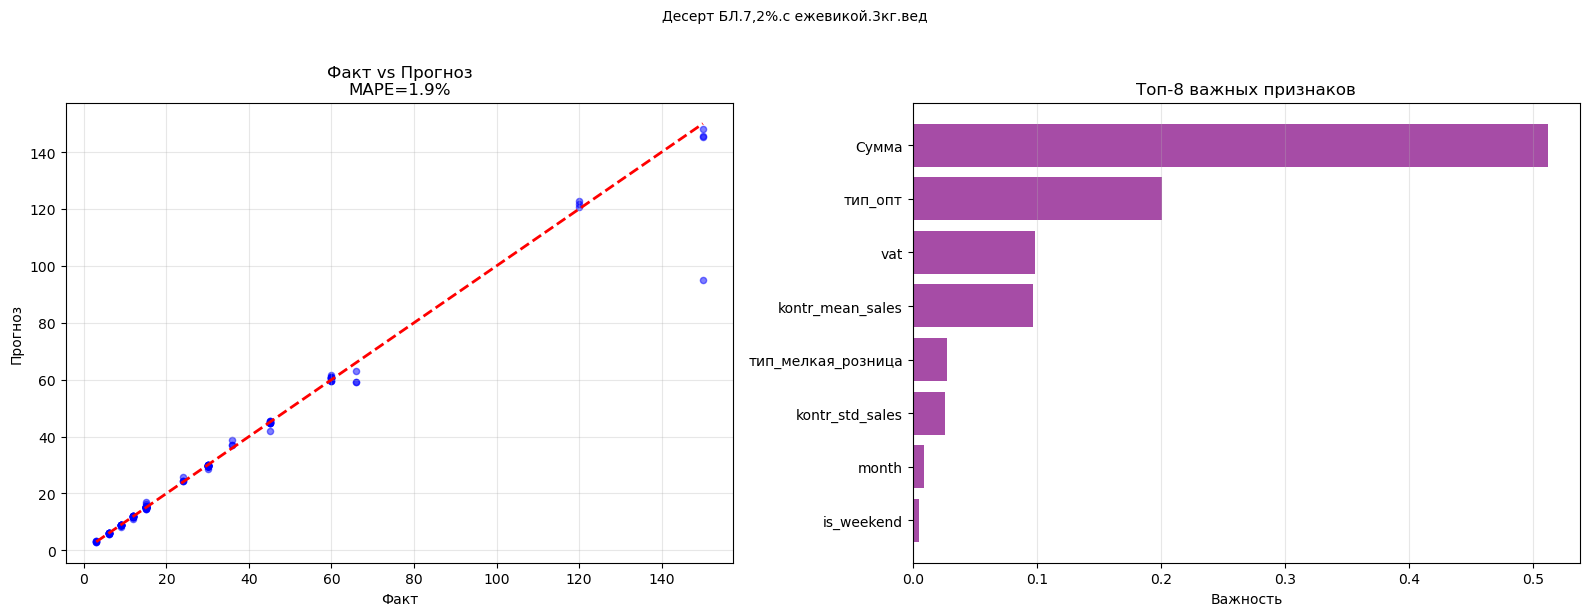


 Сохраняем в Minio: sales-analytics/Десерт БЛ.7,2_.с ежевикой.3кг.вед
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Десерт БЛ.7,2_.с ежевикой.3кг.вед/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio

 График 2/7: Десерт БЛ.7,2%.с малиной.3кг.вед


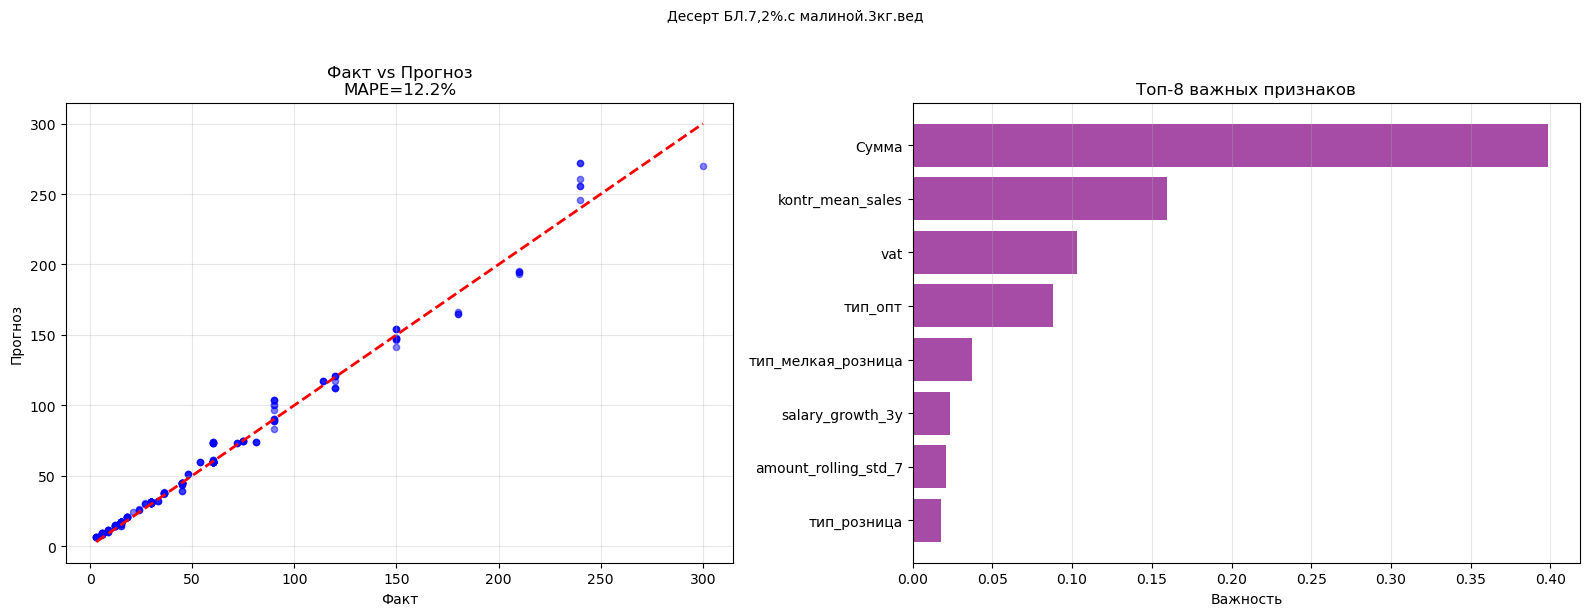


 Сохраняем в Minio: sales-analytics/Десерт БЛ.7,2_.с малиной.3кг.вед
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Десерт БЛ.7,2_.с малиной.3кг.вед/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio

 График 3/7: Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж


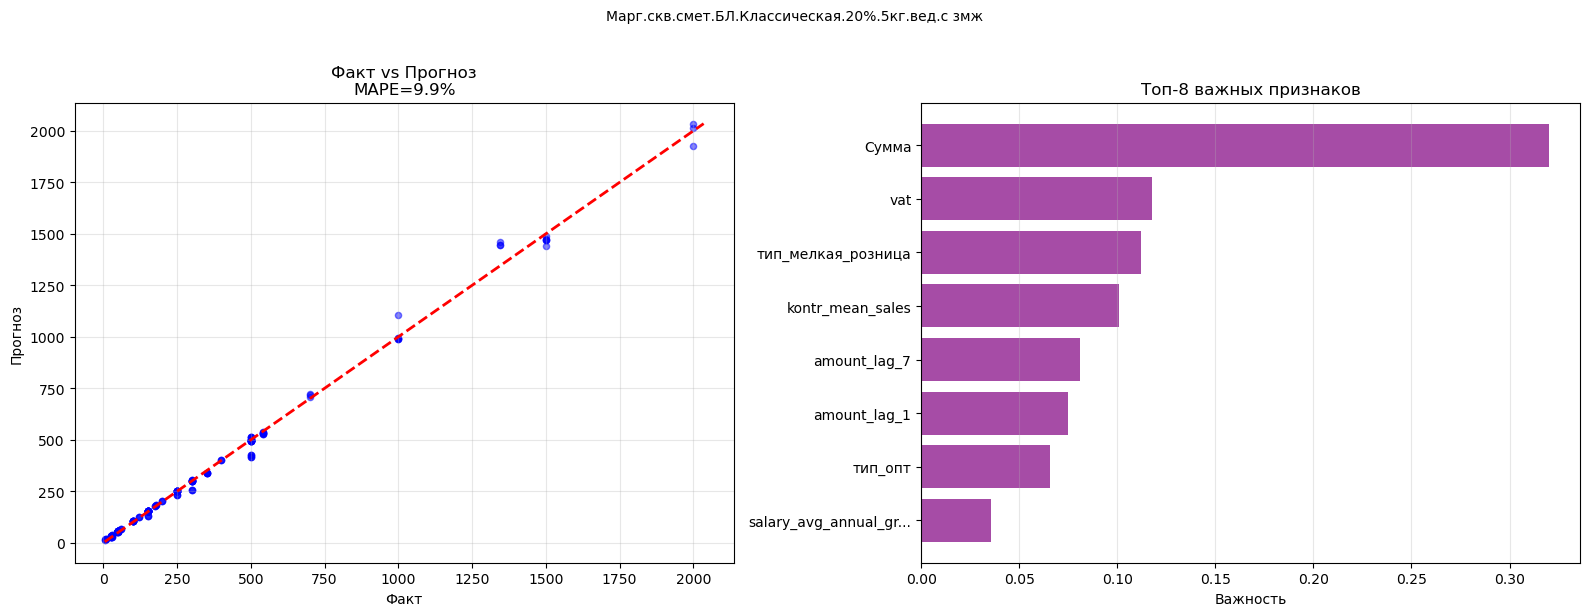


 Сохраняем в Minio: sales-analytics/Марг.скв.смет.БЛ.Классическая.20_.5кг.вед.с змж
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Марг.скв.смет.БЛ.Классическая.20_.5кг.вед.с змж/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio

 График 4/7: Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5


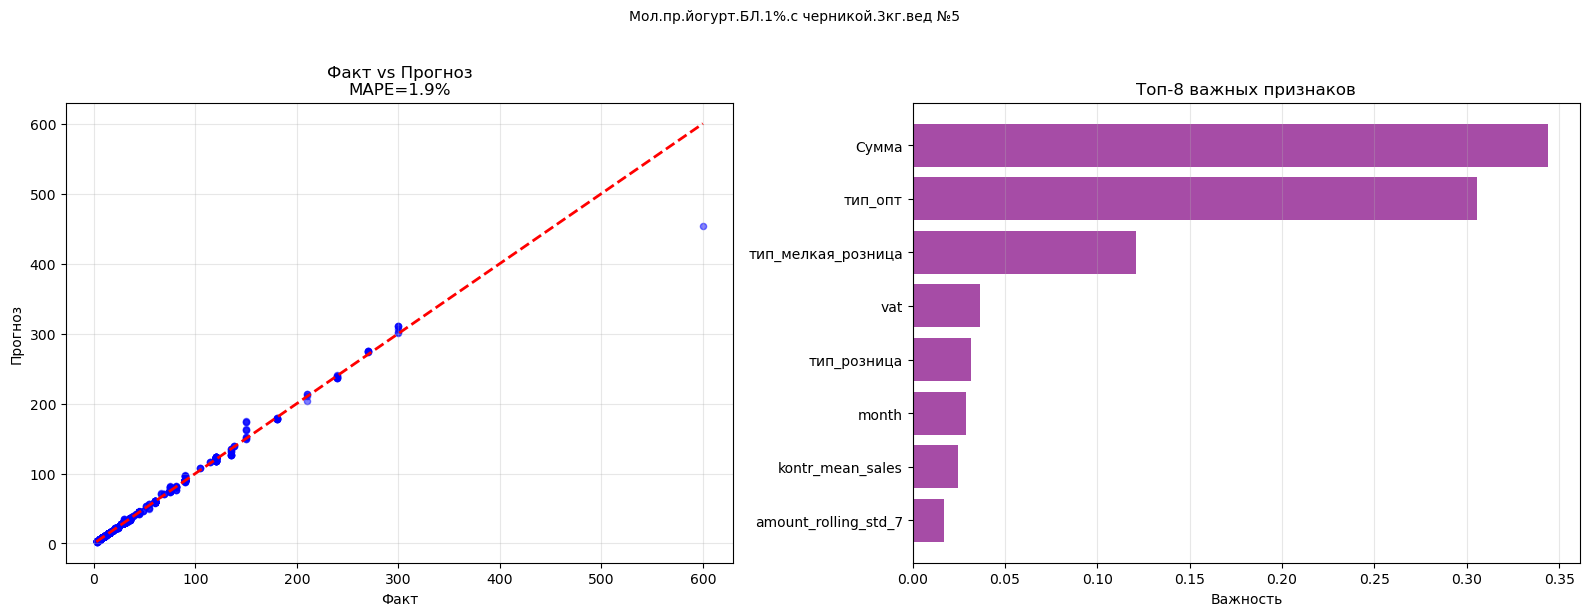


 Сохраняем в Minio: sales-analytics/Мол.пр.йогурт.БЛ.1_.с черникой.3кг.вед №5
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Мол.пр.йогурт.БЛ.1_.с черникой.3кг.вед №5/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio

 График 5/7: Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед


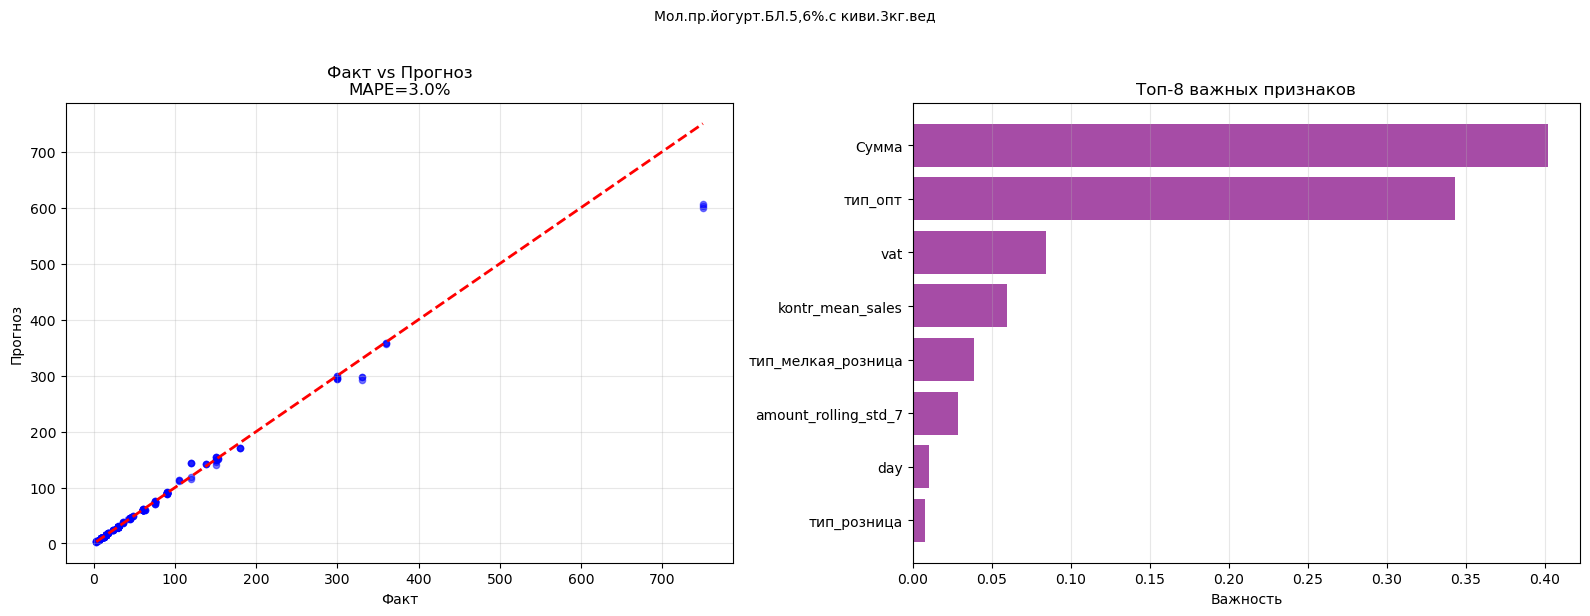


 Сохраняем в Minio: sales-analytics/Мол.пр.йогурт.БЛ.5,6_.с киви.3кг.вед
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Мол.пр.йогурт.БЛ.5,6_.с киви.3кг.вед/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio

 График 6/7: Мол.пр.йогурт.БЛ.5,6%.с малиной.3кг.вед


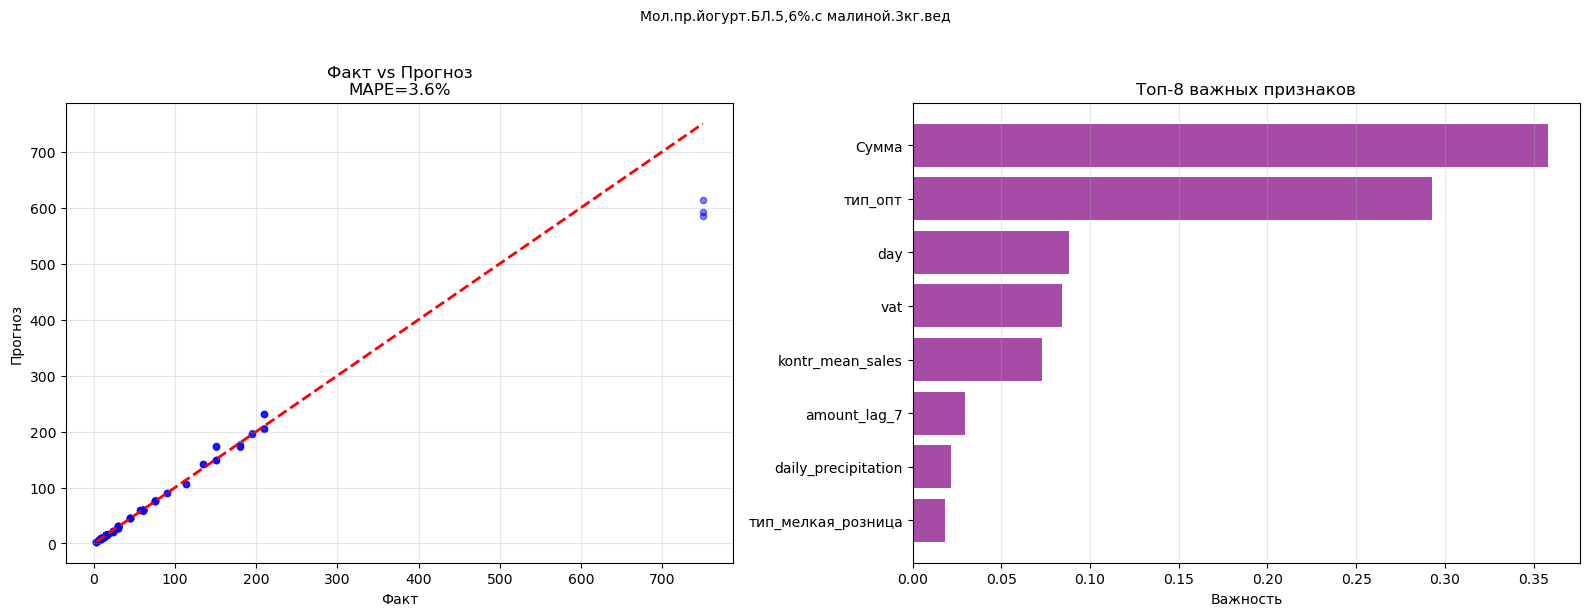


 Сохраняем в Minio: sales-analytics/Мол.пр.йогурт.БЛ.5,6_.с малиной.3кг.вед
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Мол.пр.йогурт.БЛ.5,6_.с малиной.3кг.вед/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio

 График 7/7: Мол.тв.пр.БЛ.Фермерский.1%.5кг.кор №28


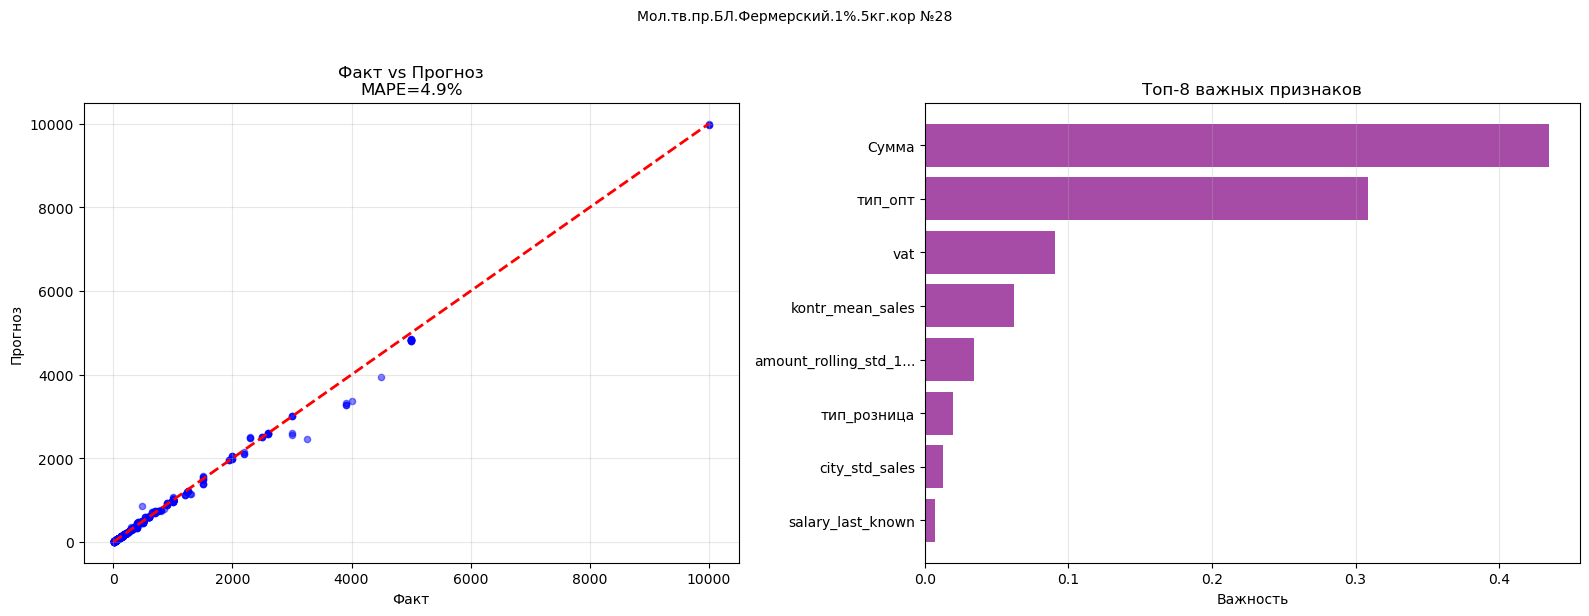


 Сохраняем в Minio: sales-analytics/Мол.тв.пр.БЛ.Фермерский.1_.5кг.кор №28
 PDF: http://localhost:9003/sales-analytics/2026-03-23/Мол.тв.пр.БЛ.Фермерский.1_.5кг.кор №28/модель_20260323.pdf
    Всего сохранено: 1 объектов
    График сохранен в Minio


In [67]:
# ============================================
# 1. ТЕКСТОВЫЙ АНАЛИЗ ТОЛЬКО ДЛЯ ПЕРВОГО ТОВАРА (С 85+ ПРИЗНАКАМИ)
# ============================================
products_list = list(model_results.keys())
first_product = products_list[0]

print(f"\n{'='*70}")
print(f" ТЕКСТОВЫЙ АНАЛИЗ ДЛЯ: {first_product[:70]} (со всеми признаками)")
print('='*70)

res = model_results[first_product]

#  ВАРИАНТ 1: Загружаем из processed_products (если они есть)
try:
    # Загружаем processed_products
    with open('/home/jovyan/work/data/processed/processed_products.pkl', 'rb') as f:
        processed_products = pickle.load(f)
    
    # Берем данные для первого товара из processed_products
    if first_product in processed_products:
        data = processed_products[first_product]
        df_product = data['df_product']  # Здесь уже все 85+ признаков!
        print(" Загружены данные из processed_products (85+ признаков)")
    else:
        raise KeyError("Товар не найден в processed_products")
        
except:
    #  ВАРИАНТ 2: Загружаем из файла с дополнительными признаками
    print(" processed_products не найден, загружаем из first_product_with_features.parquet")
    df_product = pd.read_parquet('/home/jovyan/work/data/processed/first_product_with_features.parquet')
    print(f" Загружено: {df_product.shape}")

#  ДИНАМИЧЕСКОЕ ОПРЕДЕЛЕНИЕ КОЛОНОК
print(f"\n Колонки в датасете: {list(df_product.columns)[:10]}...")

# Определяем колонки для анализа
if 'Количество' in df_product.columns:
    qty_col = 'Количество'
elif 'quantity' in df_product.columns:
    qty_col = 'quantity'
else:
    qty_col = [c for c in df_product.columns if 'колич' in c.lower() or 'quant' in c.lower()][0]

if 'Сумма' in df_product.columns:
    amount_col = 'Сумма'
elif 'amount' in df_product.columns:
    amount_col = 'amount'
else:
    amount_col = [c for c in df_product.columns if 'сумм' in c.lower() or 'amount' in c.lower()][0]

# Определяем колонку с городом
city_col = None
if 'city' in df_product.columns:
    city_col = 'city'
elif 'Город' in df_product.columns:
    city_col = 'Город'
else:
    city_col = [c for c in df_product.columns if 'город' in c.lower() or 'city' in c.lower()][0]

print(f"   Используем: город='{city_col}', количество='{qty_col}', сумма='{amount_col}'")

if city_col is not None:
    if city_col == 'city':
        df_product = df_product.rename(columns={'city': 'Город'})
        city_col = 'Город'
    elif city_col != 'Город':
        df_product = df_product.rename(columns={city_col: 'Город'})
        city_col = 'Город'
    
    # Статистика по городам
    city_stats = df_product.groupby('Город').agg({
        qty_col: ['sum', 'mean', 'count'],
        amount_col: 'sum'
    }).round(2)
    city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
    city_stats = city_stats.sort_values('сумма_руб', ascending=False)
    city_stats['средний_чек'] = city_stats['сумма_руб'] / city_stats['кол_заказов']

    print(f"\n В датасете {len(df_product.columns)} колонок")

    print("\n ТОП-5 ГОРОДОВ ПО СУММЕ:")
    for city, row in city_stats.head(5).iterrows():
        print(f"   {city}: {row['сумма_руб']:,.0f} руб ({row['всего_шт']:.0f} шт, {row['кол_заказов']:.0f} заказов)")

    print("\n ТОП-5 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
    for city, row in city_stats.sort_values('средний_чек', ascending=False).head(5).iterrows():
        print(f"   {city}: {row['средний_чек']:.0f} руб/заказ")

    # Прогноз по городам
    print("\n ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ ПО ГОРОДАМ (с 85+ признаками):")
    print("-" * 60)

    for city in city_stats.head(5).index:
        city_data = df_product[df_product['Город'] == city].copy()
        
        # Определяем колонку с датой
        if 'date' in city_data.columns:
            date_col = 'date'
        elif 'Дата' in city_data.columns:
            date_col = 'Дата'
        else:
            date_col = [c for c in city_data.columns if 'дат' in c.lower() or 'date' in c.lower()][0]
        
        city_data = city_data.sort_values(date_col)
        
        if len(city_data) > 7:
            last_week = city_data.tail(7)
            avg_last_week = last_week[qty_col].mean()
            
            if len(city_data) > 30:
                recent = city_data.tail(30)[qty_col].mean()
                if len(city_data) > 60:
                    old = city_data.iloc[-60:-30][qty_col].mean()
                else:
                    old = city_data.head(30)[qty_col].mean()
                trend = ((recent - old) / old * 100) if old > 0 else 0
            else:
                trend = 0
            
            forecast_daily = avg_last_week * (1 + trend/100/4)
            forecast_weekly = forecast_daily * 7
            
            trend_symbol = "📈" if trend > 5 else "📉" if trend < -5 else "➡️"
            print(f"\n   {trend_symbol} {city}:")
            print(f"      Текущие продажи: {avg_last_week:.1f} шт/день")
            print(f"      Тренд: {trend:+.1f}%")
            print(f"      Прогноз на неделю: {forecast_weekly:.0f} шт")
            
            # Дополнительная статистика из новых признаков
            if 'org_mean_sales' in city_data.columns:
                print(f"      Средние продажи организации: {city_data['org_mean_sales'].mean():.1f}")
            if 'city_mean_sales' in city_data.columns:
                print(f"      Средние продажи по городу: {city_data['city_mean_sales'].mean():.1f}")
print(f"\n{'='*70}")
print(" ГРАФИКИ ПО КАЖДОМУ ТОВАРУ")
print('='*70)

for idx, product_name in enumerate(products_list, 1):
    print(f"\n{'='*70}")
    print(f" График {idx}/{len(products_list)}: {product_name[:70]}")
    print('='*70)
    
    res = model_results[product_name]
    
    # Создаем фигуру с двумя графиками
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Факт vs Прогноз
    ax1 = axes[0]
    y_test = res['y_test']
    y_pred = res['y_pred']
    
    ax1.scatter(y_test, y_pred, alpha=0.5, s=20, color='blue')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax1.set_xlabel('Факт')
    ax1.set_ylabel('Прогноз')
    ax1.set_title(f'Факт vs Прогноз\nMAPE={res["mape"]:.1f}%')
    ax1.grid(True, alpha=0.3)
    
    # 2. Топ-8 важных признаков
    ax2 = axes[1]
    feature_imp = sorted(zip(res['feature_cols'], res['feature_importance']), 
                        key=lambda x: x[1], reverse=True)[:8]
    feat_names = [f[0][:20] + '...' if len(f[0]) > 20 else f[0] for f in feature_imp]
    feat_imp = [f[1] for f in feature_imp]
    
    ax2.barh(range(len(feat_names)), feat_imp, color='purple', alpha=0.7)
    ax2.set_yticks(range(len(feat_names)))
    ax2.set_yticklabels(feat_names)
    ax2.set_xlabel('Важность')
    ax2.set_title('Топ-8 важных признаков')
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.suptitle(f'{product_name[:80]}', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Сохраняем график в Minio
    try:
        clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)[:50]
        if 'save_to_minio' in locals() or 'save_to_minio' in globals():
            save_to_minio(
                bucket_name="sales-analytics",
                block_name=clean_name,
                plot_name=f"модель_{datetime.now().strftime('%Y%m%d')}",
                data=None,
                fig=fig,
                formats=['pdf']
            )
            print(f"    График сохранен в Minio")
    except Exception as e:
        print(f"    Ошибка сохранения: {e}")
    
    plt.close(fig)

In [68]:
full_df_enriched.head()

,Номенклатура,date,quantity,price,amount,vat,counterparty,organization,city,year,...,salary_forecast_next,trend_name,trend_Кварк,trend_Молоко,trend_Намазка,trend_Сливочное масло,trend_Сметана,trend_Сыр,trend_йогурт,trend_кефир
0,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 02:12:52,15.0,155.0,2325.0,419.26,Шалимов А.Н. ИП Маслозаводской пер.,"ООО ""7 Утра""",Орел,2026,...,162269.953636,Кварк,60.042129,85.035477,72.709534,74.72949,66.833703,76.913525,47.170732,68.343681
1,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 02:12:52,15.0,155.0,2325.0,419.26,Шалимов А.Н. ИП Маслозаводской пер.,"ООО ""7 Утра""",Орел,2026,...,162269.953636,Кварк,60.042129,85.035477,72.709534,74.72949,66.833703,76.913525,47.170732,68.343681
2,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 02:12:52,15.0,155.0,2325.0,419.26,Шалимов А.Н. ИП Маслозаводской пер.,"ООО ""7 Утра""",Орел,2026,...,162269.953636,Кварк,60.042129,85.035477,72.709534,74.72949,66.833703,76.913525,47.170732,68.343681
3,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 03:01:38,15.0,155.0,2325.0,0.00,Флигинских А.В. ИП-1 @@@ отсрочка,@@@,Белгород,2026,...,413544.578182,Кварк,60.042129,85.035477,72.709534,74.72949,66.833703,76.913525,47.170732,68.343681
4,"Десерт БЛ.7,2%.с ежевикой.3кг.вед",2026-01-05 14:57:14,30.0,115.0,3450.0,0.00,МОЛОЧНЫЙ РАЙ ООО Хлебозаводская @@@,@@@,Москва,2026,...,NaN,Кварк,60.042129,85.035477,72.709534,74.72949,66.833703,76.913525,47.170732,68.343681


In [69]:
full_df_enriched.shape

(13741, 71)

In [70]:
# ============================================
# ПРОГНОЗ ДЛЯ ОТДЕЛА ПРОДАЖ (ПО ВСЕМ ТОВАРАМ)!!!!!!!!!!!!!не актуальная ячейка!!!!!!!!!!!
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import re
from minio import Minio
from io import BytesIO
import pickle
import os

print(f"\n{'='*70}")
print(" ПРОГНОЗ ПРОДАЖ ДЛЯ ОТДЕЛА (ПО ВСЕМ ТОВАРАМ)")
print('='*70)

# Дата начала прогноза - завтра
start_date = datetime.now().date() + timedelta(days=1)
print(f" Прогноз на период: {start_date} - {start_date + timedelta(days=6)}")
print(f" Всего товаров: {len(model_results)}")

# Словарь для хранения всех прогнозов
all_forecasts = {}

# Список для сбора чистого текста в файл (БЕЗ ЭМОДЗИ)
file_report = []

# Заголовок отчета для файла
file_report.append(f"{'='*70}")
file_report.append(f" ПРОГНОЗ ПРОДАЖ ДЛЯ ОТДЕЛА")
file_report.append(f" Дата формирования: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
file_report.append(f" Период прогноза: {start_date} - {start_date + timedelta(days=6)}")
file_report.append(f" Всего товаров: {len(model_results)}")
file_report.append(f"{'='*70}")

# ============================================
# ПРОГНОЗ ПО КАЖДОМУ ТОВАРУ
# ============================================

for idx, (product_name, res) in enumerate(model_results.items(), 1):
    print(f"\n{'='*70}")
    print(f" ПРОГНОЗ {idx}/{len(model_results)}: {product_name[:70]}")
    print('='*70)
    
    try:
        # Получаем данные для товара
        df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
        
        if df_product.empty:
            print(f" Нет данных для товара, пропускаем")
            continue
        
        # Переименовываем колонки
        rename_dict = {
            'date': 'date',
            'quantity': 'quantity',
            'amount': 'amount',
            'city': 'city',
            'counterparty': 'counterparty',
            'organization': 'organization'
        }
        rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
        df_product = df_product.rename(columns=rename_dict)
        
        # Создаем прогнозист
        forecaster = SalesForecaster(
            model_opt=res['opt_model'],
            model_roz=res['roz_model'],
            feature_cols=res['feature_cols'],
            product_name=product_name,
            city_features=[col for col in res['feature_cols'] if 'city_' in col]
        )
        
        # Загружаем последние данные
        forecaster.update_last_known(df_product)
        
        # Делаем прогноз на будущее
        forecast = forecaster.forecast(pd.Timestamp(start_date), days=7)
        all_forecasts[product_name] = forecast
        
        # ============================================
        # ФОРМИРОВАНИЕ ОТЧЕТА ПО ТОВАРУ
        # ============================================
        
        mape = res['mape']
        
        # Качество модели (с эмодзи для консоли)
        if mape < 10:
            quality_console = " ОТЛИЧНАЯ ТОЧНОСТЬ"
            quality_file = "ОТЛИЧНАЯ ТОЧНОСТЬ"
        elif mape < 20:
            quality_console = " ХОРОШАЯ ТОЧНОСТЬ"
            quality_file = "ХОРОШАЯ ТОЧНОСТЬ"
        else:
            quality_console = " НИЗКАЯ ТОЧНОСТЬ (требует внимания)"
            quality_file = "НИЗКАЯ ТОЧНОСТЬ (требует внимания)"
        
        # Добавляем в файл (без эмодзи)
        file_report.append(f"\n{'='*70}")
        file_report.append(f" ТОВАР {idx}/{len(model_results)}: {product_name}")
        file_report.append(f" {quality_file} (MAPE: {mape:.1f}%)")
        file_report.append('-' * 60)
        
        # Выводим в консоль (с эмодзи)
        print(f"\n ТОВАР: {product_name[:70]}")
        print(f" {quality_console} (MAPE: {mape:.1f}%)")
        print("-" * 60)
        
        # 1. ТОП-10 ГОРОДОВ ПО ПРОГНОЗУ
        city_forecast = forecast.groupby('city')['forecast'].sum().sort_values(ascending=False).round(0)
        
        print("\n    ТОП-10 ГОРОДОВ ПО ПРОГНОЗУ:")
        file_report.append("\n   ТОП-10 ГОРОДОВ ПО ПРОГНОЗУ:")
        
        for city, value in city_forecast.head(10).items():
            current = df_product[df_product['city'] == city]['quantity'].tail(7).mean() if city in df_product['city'].values else 0
            line = f"      {city[:20]:20} - {value:>8,.0f} шт (текущие: {current:.1f} шт/день)"
            print(line)
            file_report.append(line)
        
        # 2. ТОП-10 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ
        city_stats = df_product.groupby('city').agg({
            'amount': 'sum',
            'quantity': 'count'
        }).round(2)
        city_stats['средний_чек'] = city_stats['amount'] / city_stats['quantity']
        city_stats = city_stats.sort_values('средний_чек', ascending=False)
        
        print("\n    ТОП-10 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
        file_report.append("\n   ТОП-10 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
        
        for city, row in city_stats.head(10).iterrows():
            line = f"      {city[:20]:20} - {row['средний_чек']:,.0f} руб/заказ"
            print(line)
            file_report.append(line)
        
        # 3. ПРОГНОЗ ПО ДНЯМ И ГОРОДАМ (ТОП-10)
        print(f"\n    ПРОГНОЗ НА НЕДЕЛЮ (ТОП-10 ГОРОДОВ):")
        file_report.append(f"\n   ПРОГНОЗ НА НЕДЕЛЮ (ТОП-10 ГОРОДОВ):")
        
        for city in city_forecast.head(10).index:
            city_data = forecast[forecast['city'] == city]
            total_week = city_data['forecast'].sum()
            
            # Находим основного контрагента для этого города (самый частый)
            city_hist = df_product[df_product['city'] == city].sort_values('date')
            if len(city_hist) > 0:
                # Берем самого частого контрагента
                main_counterparty = city_hist['counterparty'].mode()[0] if 'counterparty' in city_hist.columns else 'Не указан'
            else:
                main_counterparty = 'Не указан'
            
            # Тренд из исторических данных
            if len(city_hist) > 30:
                recent = city_hist.tail(30)['quantity'].mean()
                old = city_hist.head(30)['quantity'].mean()
                trend = ((recent - old) / old * 100) if old > 0 else 0
            else:
                trend = 0
            
            # Определяем символ тренда
            if trend > 50:
                trend_symbol_console = "🔥🔥 СИЛЬНЫЙ РОСТ"
                trend_symbol_file = "СИЛЬНЫЙ РОСТ"
            elif trend > 20:
                trend_symbol_console = "🔥 РОСТ"
                trend_symbol_file = "РОСТ"
            elif trend > 5:
                trend_symbol_console = "📈 рост"
                trend_symbol_file = "рост"
            elif trend > -5:
                trend_symbol_console = "➡️ стабильно"
                trend_symbol_file = "стабильно"
            elif trend > -20:
                trend_symbol_console = "📉 падение"
                trend_symbol_file = "падение"
            elif trend > -50:
                trend_symbol_console = "💥 ПАДЕНИЕ"
                trend_symbol_file = "ПАДЕНИЕ"
            else:
                trend_symbol_console = "💥💥 СИЛЬНОЕ ПАДЕНИЕ"
                trend_symbol_file = "СИЛЬНОЕ ПАДЕНИЕ"
            
            current_daily = city_hist.tail(7)['quantity'].mean() if len(city_hist) > 7 else 0
            
            # Вывод в консоль (с эмодзи)
            print(f"\n      {trend_symbol_console} {city[:20]:20} ({main_counterparty[:30]})")
            print(f"         Текущие: {current_daily:.1f} шт/день")
            print(f"         Тренд: {trend:+.1f}%")
            print(f"         Прогноз на неделю: {total_week:,.0f} шт")
            
            # Добавляем в файл (без эмодзи)
            file_report.append(f"\n      {trend_symbol_file} {city[:20]:20} ({main_counterparty[:30]})")
            file_report.append(f"         Текущие: {current_daily:.1f} шт/день")
            file_report.append(f"         Тренд: {trend:+.1f}%")
            file_report.append(f"         Прогноз на неделю: {total_week:,.0f} шт")
            
            if trend < -50:
                print(f"          РЕКОМЕНДАЦИЯ: Снизить цену на 15-20%")
                file_report.append(f"         РЕКОМЕНДАЦИЯ: Снизить цену на 15-20%")
        
    except Exception as e:
        error_msg = f" Ошибка при прогнозе для {product_name[:50]}: {e}"
        print(error_msg)
        file_report.append(error_msg)
        continue

# ============================================
# ОБЩИЕ РЕКОМЕНДАЦИИ ПО ВСЕМ ТОВАРАМ
# ============================================

print(f"\n{'='*70}")
print("  ОБЩИЕ РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ")
print('='*70)

file_report.append(f"\n{'='*70}")
file_report.append(" ОБЩИЕ РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ")
file_report.append('='*70)

# Товары с низкой точностью прогноза
print("\n Товары с низкой точностью прогноза (MAPE > 20%):")
file_report.append("\nТовары с низкой точностью прогноза (MAPE > 20%):")

problematic = [prod for prod, res in model_results.items() if res['mape'] > 20]
if problematic:
    for prod in problematic[:10]:
        mape = model_results[prod]['mape']
        line = f"   - {prod[:70]}... (MAPE: {mape:.1f}%)"
        print(line)
        file_report.append(line)
else:
    print("    Все модели имеют хорошую точность")
    file_report.append("   Все модели имеют хорошую точность")

# Города с сильным ростом
print("\n ГОРОДА С СИЛЬНЫМ РОСТОМ (>50%) - увеличить отгрузки:")
print("-" * 60)
file_report.append("\nГОРОДА С СИЛЬНЫМ РОСТОМ (>50%) - увеличить отгрузки:")
file_report.append("-" * 60)

growing_recommendations = {}
falling_recommendations = {}

for product_name, forecast in all_forecasts.items():
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    
    if 'city' in df_product.columns:
        for city in df_product['city'].unique()[:10]:
            city_data = df_product[df_product['city'] == city].sort_values('date')
            if len(city_data) > 30:
                recent = city_data.tail(30)['quantity'].mean()
                old = city_data.head(30)['quantity'].mean()
                if old > 0:
                    growth = ((recent - old) / old * 100)
                    
                    if growth > 50:
                        if city not in growing_recommendations:
                            growing_recommendations[city] = []
                        growing_recommendations[city].append((product_name[:50], growth))
                    elif growth < -50:
                        if city not in falling_recommendations:
                            falling_recommendations[city] = []
                        falling_recommendations[city].append((product_name[:50], growth))

# Выводим рекомендации по росту
if growing_recommendations:
    for city, products in sorted(growing_recommendations.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
        print(f"\n    {city}:")
        file_report.append(f"\n   {city}:")
        for prod, growth in sorted(products, key=lambda x: x[1], reverse=True)[:3]:
            line = f"       {prod}: рост {growth:+.1f}% - УВЕЛИЧИТЬ ОТГРУЗКУ"
            print(line)
            file_report.append(f"      {prod}: рост {growth:+.1f}% - УВЕЛИЧИТЬ ОТГРУЗКУ")
else:
    print("   Нет городов с сильным ростом")
    file_report.append("   Нет городов с сильным ростом")

# Выводим рекомендации по падению
if falling_recommendations:
    print("\n ГОРОДА С СИЛЬНЫМ ПАДЕНИЕМ (<-50%) - рассмотреть скидки:")
    print("-" * 60)
    file_report.append("\nГОРОДА С СИЛЬНЫМ ПАДЕНИЕМ (<-50%) - рассмотреть скидки:")
    file_report.append("-" * 60)
    
    for city, products in sorted(falling_recommendations.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
        print(f"\n    {city}:")
        file_report.append(f"\n   {city}:")
        for prod, growth in sorted(products, key=lambda x: x[1])[:3]:
            discount = min(30, int(abs(growth)/3))
            line = f"       {prod}: падение {growth:.1f}% - рекомендовать скидку {discount}%"
            print(line)
            file_report.append(f"      {prod}: падение {growth:.1f}% - рекомендовать скидку {discount}%")

file_report.append(f"\n{'='*70}")
file_report.append(f" КОНЕЦ ОТЧЕТА")
file_report.append(f"{'='*70}")

# ============================================
# СОХРАНЕНИЕ ОТЧЕТА В MINIO
# ============================================

print(f"\n{'='*70}")
print("  СОХРАНЕНИЕ ОТЧЕТА")
print('='*70)

try:
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    bucket_name = "sales-reports"
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
    
    # Формируем имя файла с датой и номером батча
    date_str = datetime.now().strftime('%Y%m%d')
    batch_num = CURRENT_BATCH if 'CURRENT_BATCH' in locals() else 'all'
    filename = f"forecast_batch{batch_num}_{date_str}.txt"
    
    # Объединяем все строки отчета
    full_report_text = "\n".join(file_report)
    
    # Сохраняем в Minio
    report_buffer = BytesIO()
    report_buffer.write(full_report_text.encode('utf-8-sig'))
    report_buffer.seek(0)
    
    client.put_object(
        bucket_name,
        filename,
        data=report_buffer,
        length=report_buffer.getbuffer().nbytes,
        content_type='text/plain; charset=utf-8'
    )
    
    print(f"\n Отчет сохранен: {filename}")
    print(f" Ссылка: http://localhost:9003/{bucket_name}/{filename}")
    
except Exception as e:
    print(f" Ошибка сохранения в Minio: {e}")

print(f"\n{'='*70}")
print(" ПРОГНОЗЫ ДЛЯ ОТДЕЛА ПРОДАЖ ГОТОВЫ")
print('='*70)


 ПРОГНОЗ ПРОДАЖ ДЛЯ ОТДЕЛА (ПО ВСЕМ ТОВАРАМ)
 Прогноз на период: 2026-03-24 - 2026-03-30
 Всего товаров: 7

 ПРОГНОЗ 1/7: Десерт БЛ.7,2%.с ежевикой.3кг.вед
 Ошибка при прогнозе для Десерт БЛ.7,2%.с ежевикой.3кг.вед: name 'SalesForecaster' is not defined

 ПРОГНОЗ 2/7: Десерт БЛ.7,2%.с малиной.3кг.вед
 Ошибка при прогнозе для Десерт БЛ.7,2%.с малиной.3кг.вед: name 'SalesForecaster' is not defined

 ПРОГНОЗ 3/7: Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж
 Ошибка при прогнозе для Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с змж: name 'SalesForecaster' is not defined

 ПРОГНОЗ 4/7: Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5
 Ошибка при прогнозе для Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5: name 'SalesForecaster' is not defined

 ПРОГНОЗ 5/7: Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед
 Ошибка при прогнозе для Мол.пр.йогурт.БЛ.5,6%.с киви.3кг.вед: name 'SalesForecaster' is not defined

 ПРОГНОЗ 6/7: Мол.пр.йогурт.БЛ.5,6%.с малиной.3кг.вед
 Ошибка при прогнозе для Мол.пр.йогурт.БЛ.5,6%.с малин

In [ ]:
# После обучения всех моделей
good_models = []
medium_models = []
bad_models = []

for product_name, res in model_results.items():
    mape = res['mape']
    if mape < 10:
        good_models.append({'name': product_name, 'mape': mape, 'params': 'default'})
    elif mape < 30:
        medium_models.append({'name': product_name, 'mape': mape, 'params': 'medium'})
    else:
        bad_models.append({'name': product_name, 'mape': mape, 'params': 'bad'})

print(f" Отличные модели (MAPE < 10%): {len(good_models)} товаров")
print(f" Средние модели (MAPE 10-30%): {len(medium_models)} товаров")
print(f" Плохие модели (MAPE > 30%): {len(bad_models)} товаров")

In [ ]:
model_params = {
    'default': {  # Для хороших моделей (быстро, точно)
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': 5,
        'subsample': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1
    },
    'medium': {  # Для средних моделей (баланс)
        'n_estimators': 500,
        'learning_rate': 0.03,
        'max_depth': 4,
        'subsample': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 0.5
    },
    'bad': {  # Для плохих моделей (стабильность)
        'n_estimators': 1000,
        'learning_rate': 0.01,
        'max_depth': 3,
        'subsample': 0.5,
        'reg_alpha': 1.0,
        'reg_lambda': 1.0,
        'min_child_weight': 5,  # Защита от выбросов
        'colsample_bytree': 0.5  # Меньше признаков на дерево
    },
    'ensemble': {  # Для очень плохих - ансамбль
        'n_estimators': 500,
        'learning_rate': 0.02,
        'max_depth': 4,
        'subsample': 0.6,
        'reg_alpha': 0.8,
        'reg_lambda': 0.8,
        'num_parallel_tree': 3  # Параллельные деревья
    }
}

In [ ]:
def train_with_params(product_name, model_type='default'):
    """Обучает модель с параметрами под тип товара"""
    
    params = model_params[model_type]
    
    # Базовые параметры для всех
    base_params = {
        'random_state': 42,
        'early_stopping_rounds': 50,
        'eval_metric': 'rmse'
    }
    
    # Объединяем
    full_params = {**base_params, **params}
    
    model = xgb.XGBRegressor(**full_params)
    
    # ... обучение ...
    
    return model

In [ ]:
 #DAG в Airflow для разных батчей
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta

default_args = {
    'owner': 'data_science',
    'depends_on_past': False,
    'start_date': datetime(2024, 1, 1),
    'email_on_failure': True,
    'email_on_retry': False,
    'retries': 1,
    'retry_delay': timedelta(minutes=5)
}

dag = DAG(
    'ml_training_pipeline',
    default_args=default_args,
    description='Обучение моделей с разными параметрами',
    schedule_interval='0 2 * * *',  # Каждый день в 2 часа ночи
    catchup=False
)

def classify_products(**context):
    """Классифицирует товары по качеству предыдущих моделей"""
    # Загружаем историю метрик
    # Разбиваем на good/medium/bad
    context['ti'].xcom_push(key='good_products', value=good_list)
    context['ti'].xcom_push(key='medium_products', value=medium_list)
    context['ti'].xcom_push(key='bad_products', value=bad_list)

def train_good_models(**context):
    """Обучает хорошие модели (быстро)"""
    products = context['ti'].xcom_pull(key='good_products')
    for product in products:
        train_with_params(product, 'default')

def train_medium_models(**context):
    """Обучает средние модели (баланс)"""
    products = context['ti'].xcom_pull(key='medium_products')
    for product in products:
        train_with_params(product, 'medium')

def train_bad_models(**context):
    """Обучает плохие модели (долго, стабильно)"""
    products = context['ti'].xcom_pull(key='bad_products')
    for product in products:
        train_with_params(product, 'bad')

def ensemble_bad_models(**context):
    """Для очень плохих - ансамбль моделей"""
    products = context['ti'].xcom_pull(key='bad_products')
    for product in products:
        # Обучаем несколько моделей
        model1 = train_with_params(product, 'bad')
        model2 = train_with_params(product, 'ensemble')
        # Сохраняем обе для ансамбля

# Создаем таски
classify_task = PythonOperator(
    task_id='classify_products',
    python_callable=classify_products,
    dag=dag
)

good_task = PythonOperator(
    task_id='train_good_models',
    python_callable=train_good_models,
    dag=dag
)

medium_task = PythonOperator(
    task_id='train_medium_models',
    python_callable=train_medium_models,
    dag=dag
)

bad_task = PythonOperator(
    task_id='train_bad_models',
    python_callable=train_bad_models,
    dag=dag
)

ensemble_task = PythonOperator(
    task_id='ensemble_bad_models',
    python_callable=ensemble_bad_models,
    dag=dag
)

# Связываем таски
classify_task >> [good_task, medium_task, bad_task]
bad_task >> ensemble_task

In [ ]:
# Дополнительные стратегии для плохих моделей 1. Определяем причину плохой модели
def analyze_bad_model(df_product):
    """Анализирует почему модель плохая"""
    
    # Проверяем на выбросы
    q99 = df_product['Количество'].quantile(0.99)
    outliers = df_product[df_product['Количество'] > q99]
    
    if len(outliers) > 0:
        print(f" Найдено {len(outliers)} выбросов")
        return 'outliers'
    
    # Проверяем на разреженность
    zero_days = df_product.groupby(df_product['date'].dt.date)['quantity'].sum()
    zero_days = (zero_days == 0).sum()
    
    if zero_days > len(zero_days) * 0.3:
        return 'sparse'  # Разреженные продажи
    
    return 'unknown'

# 2. Разные стратегии для разных причин
strategies = {
    'outliers': {
        'remove_outliers': True,
        'use_quantile_loss': True,
        'params': model_params['ensemble']
    },
    'sparse': {
        'use_poisson': True,
        'aggregate_daily': True,
        'params': {
            'n_estimators': 500,
            'learning_rate': 0.01,
            'max_depth': 3,
            'objective': 'count:poisson'  # Для редких событий
        }
    },
    'unknown': {
        'use_cv': True,
        'grid_search': True,
        'params': model_params['bad']
    }
}

In [ ]:
#Мониторинг и авто-классификация В конце каждого цикла обучения
def update_product_quality():
    """Обновляет качество товаров для следующего запуска"""
    
    quality_db = {}
    
    for product_name, res in model_results.items():
        mape = res['mape']
        trend = analyze_trend(product_name)  # анализ тренда
        
        quality_db[product_name] = {
            'mape': mape,
            'category': 'good' if mape < 10 else 'medium' if mape < 30 else 'bad',
            'trend': trend,
            'last_trained': datetime.now().isoformat(),
            'next_params': model_params['good' if mape < 10 else 'medium' if mape < 30 else 'bad']
        }
    
    # Сохраняем в базу
    pd.DataFrame(quality_db).T.to_csv('product_quality.csv')